In [2]:
#环境
import numpy as np
test_arr = np.array([1, 2, 3, 4])
print(f"✅ 基础运算测试: [1,2,3,4] 求和结果 = {test_arr.sum()} (期望值: 10)")

import ccxt
print(ccxt.exchanges)

import pandas as pd
import pandas_ta as ta

import time
import urllib.request
proxies = urllib.request.getproxies()
print("系统当前代理为:", proxies)

import matplotlib.pyplot as plt
import scipy.stats as stats
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import het_arch

import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from sklearn.utils.class_weight import compute_sample_weight

from arch import arch_model
from tqdm import tqdm

✅ 基础运算测试: [1,2,3,4] 求和结果 = 10 (期望值: 10)
['aftermath', 'alpaca', 'apex', 'ascendex', 'aster', 'backpack', 'bequant', 'bigone', 'binance', 'binancecoinm', 'binanceus', 'binanceusdm', 'bingx', 'bit2c', 'bitbank', 'bitbns', 'bitfinex', 'bitflyer', 'bitget', 'bithumb', 'bitmart', 'bitmex', 'bitopro', 'bitrue', 'bitso', 'bitstamp', 'bitteam', 'bittrade', 'bitvavo', 'blockchaincom', 'blofin', 'btcbox', 'btcmarkets', 'btcturk', 'bullish', 'bybit', 'bybiteu', 'bydfi', 'cex', 'coinbase', 'coinbaseexchange', 'coinbaseinternational', 'coincheck', 'coinex', 'coinmate', 'coinmetro', 'coinone', 'coinsph', 'coinspot', 'cryptocom', 'cryptomus', 'deepcoin', 'delta', 'deribit', 'derive', 'digifinex', 'dydx', 'exmo', 'extended', 'fmfwio', 'foxbit', 'gate', 'gateeu', 'gemini', 'grvt', 'hashkey', 'hibachi', 'hitbtc', 'hollaex', 'htx', 'hyperliquid', 'independentreserve', 'indodax', 'kraken', 'krakenfutures', 'kucoin', 'kucoinfutures', 'latoken', 'lbank', 'lighter', 'luno', 'mercado', 'mexc', 'modetrade', 'm

In [ ]:
#实例化交易所（凭证从环境变量读取，不再硬编码）
# 原始探索阶段这里直接写了 apiKey/secret/password 明文，
# 打包时已经把它们移到 .env 文件，通过 src/config.py + python-dotenv 读取。
# 纯抓公开行情数据（本notebook实际用到的）根本不需要鉴权，用 exchange_open 就够了。

import sys, os
sys.path.append(os.path.abspath('..'))  # 让 notebook 能 import 到 src/
from src.data_fetch import build_public_exchange, build_authenticated_exchange

exchange_open = build_public_exchange()

# 只有需要查账户/持仓/下单这类鉴权接口时才需要下面这行，
# 且要求你已经在 .env 里配置好 OKX_API_KEY / OKX_API_SECRET / OKX_API_PASSWORD
# exchange = build_authenticated_exchange()


In [4]:
#ccxt的help指令
print(exchange.features)

{'spot': {'sandbox': True, 'createOrder': {'marginMode': True, 'triggerPrice': True, 'triggerPriceType': {'last': True, 'mark': True, 'index': True}, 'triggerDirection': False, 'stopLossPrice': True, 'takeProfitPrice': True, 'attachedStopLossTakeProfit': {'triggerPriceType': {'last': True, 'mark': True, 'index': True}, 'price': True}, 'timeInForce': {'IOC': True, 'FOK': True, 'PO': True, 'GTD': False, 'GTC': True}, 'hedged': False, 'trailing': True, 'iceberg': True, 'leverage': False, 'selfTradePrevention': True, 'marketBuyByCost': True, 'marketBuyRequiresPrice': False, 'stopLoss': {'triggerPriceType': {'last': True, 'mark': True, 'index': True}, 'price': True}, 'takeProfit': {'triggerPriceType': {'last': True, 'mark': True, 'index': True}, 'price': True}, 'symbolRequired': True}, 'createOrders': {'max': 20, 'symbolRequired': True}, 'fetchMyTrades': {'marginMode': False, 'daysBack': 90, 'limit': 100, 'untilDays': 10000, 'symbolRequired': False}, 'fetchOrder': {'marginMode': False, 'tri

In [6]:
#爬15min数据
def fetch_large_ohlcv_okx(exchange, symbol='BTC/USDT', timeframe='15m', target_limit=50000):
    all_ohlcv = []
    limit_per_request = 100  # OKX 的单次上限是 100
    tf_ms = 15 * 60 * 1000   # 15分钟的毫秒数
    
    # 这里直接使用传进来的 exchange 对象
    current_time = exchange.milliseconds()
    since = current_time - (target_limit * tf_ms)
    
    print(f"正在从 OKX 抓取 {symbol} 的 {timeframe} 数据，目标约 {target_limit} 条...")
    
    while len(all_ohlcv) < target_limit:
        try:
            ohlcv = exchange.fetch_ohlcv(symbol, timeframe, since=since, limit=limit_per_request)
            
            if not ohlcv:
                break
                
            all_ohlcv.extend(ohlcv)
            since = ohlcv[-1][0] + 1
            print(f"已成功获取累计条数: {len(all_ohlcv)}")
            
            time.sleep(exchange.rateLimit / 1000)
            
            if len(ohlcv) < limit_per_request:
                break
                
        except Exception as e:
            print(f"抓取数据时发生错误: {e}")
            time.sleep(1)
            
    df = pd.DataFrame(all_ohlcv, columns=['timestamp', 'open', 'high', 'low', 'close', 'volume'])
    df['timestamp'] = pd.to_datetime(df['timestamp'], unit='ms')
    df.set_index('timestamp', inplace=True)
    
    if len(df) > target_limit:
        df = df.tail(target_limit)
        
    print(f"\n数据抓取完毕！最终得到 {len(df)} 行有效数据。")
    return df

df_15m = fetch_large_ohlcv_okx(exchange=exchange_open, symbol='BTC/USDT', timeframe='15m', target_limit=50000)

# === 4. 打印预览 ===
print("\n数据预览：")
print(df_15m.head())
print(df_15m.tail())

正在从 OKX 抓取 BTC/USDT 的 15m 数据，目标约 50000 条...


KeyboardInterrupt: 

In [ ]:
#存储数据
df_15m.to_csv('okx_btc_usdt_15m.csv')

=== 1. ADF 平稳性检验 (Augmented Dickey-Fuller Test) ===
ADF 统计量 (T-statistic): -37.0473
P-Value: 0.0000e+00
结论: P-Value < 0.05，拒绝原假设，对数收益率序列是【平稳的】。
--------------------------------------------------
=== 2. ARCH 效应检验 (Engle's ARCH-LM Test) ===
LM 统计量 (LM Statistic): 4987.2305
P-Value: 0.0000e+00
结论: P-Value < 0.05，拒绝原假设，存在显著的【ARCH效应 (条件异方差/波动率聚集)】。
👉 非常适合使用 GARCH 模型进行下一步建模！
--------------------------------------------------


C:\Users\10914\AppData\Local\Temp\ipykernel_222904\3055379458.py:61: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\10914\AppData\Local\Temp\ipykernel_222904\3055379458.py:61: UserWarning: Glyph 38047 (\N{CJK UNIFIED IDEOGRAPH-949F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\10914\AppData\Local\Temp\ipykernel_222904\3055379458.py:61: UserWarning: Glyph 23545 (\N{CJK UNIFIED IDEOGRAPH-5BF9}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\10914\AppData\Local\Temp\ipykernel_222904\3055379458.py:61: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\10914\AppData\Local\Temp\ipykernel_222904\3055379458.py:61: UserWarning: Glyph 25910 (\N{CJK UNIFIED IDEOGRAPH-6536}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\10914\AppData\Local\Temp\ipykernel_222904\3055379458.py:61: UserWarning: Glyph 30

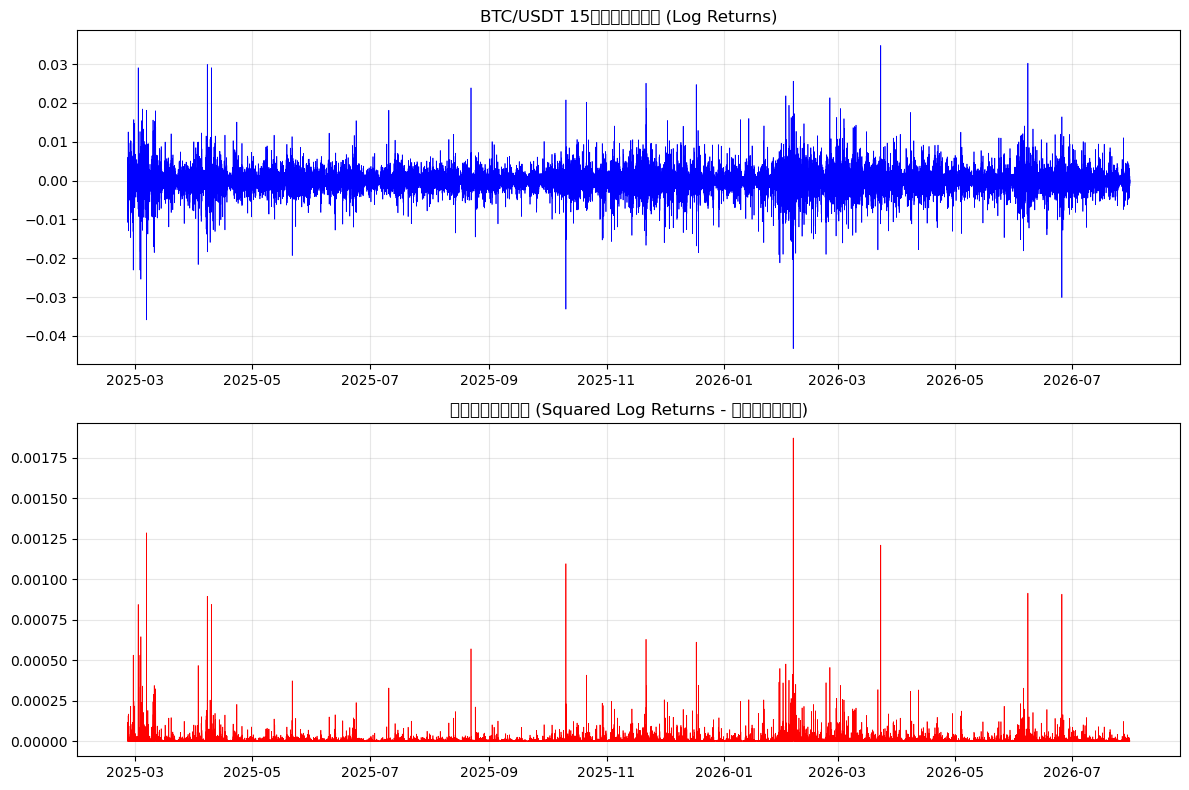

In [9]:
#ADF检验,ARCH效应检验

df_15m = pd.read_csv('okx_btc_usdt_15m.csv', index_col='timestamp', parse_dates=True) 

# ==========================================
# 1. 数据准备：计算对数收益率
# ==========================================
# 金融学中通常使用“对数收益率”来进行时间序列分析
df_15m['log_return'] = np.log(df_15m['close'] / df_15m['close'].shift(1))

# 剔除第一行的 NaN 值
returns = df_15m['log_return'].dropna()

# ==========================================
# 2. 平稳性检验：ADF 检验
# ==========================================
print("=== 1. ADF 平稳性检验 (Augmented Dickey-Fuller Test) ===")
adf_result = adfuller(returns)
print(f"ADF 统计量 (T-statistic): {adf_result[0]:.4f}")
print(f"P-Value: {adf_result[1]:.4e}")
print("结论: ", end="")
if adf_result[1] < 0.05:
    print("P-Value < 0.05，拒绝原假设，对数收益率序列是【平稳的】。")
else:
    print("P-Value >= 0.05，不能拒绝原假设，序列是【不平稳的】。")
print("-" * 50)

# ==========================================
# 3. ARCH 效应检验：Engle's ARCH-LM 检验
# ==========================================
print("=== 2. ARCH 效应检验 (Engle's ARCH-LM Test) ===")
# 通常我们对收益率去均值后（即残差）进行 ARCH 检验
resid = returns - returns.mean()
# 检验滞后项，这里我们看过去 15 个周期（约 3.75 小时）
arch_test = het_arch(resid, nlags=15) 
print(f"LM 统计量 (LM Statistic): {arch_test[0]:.4f}")
print(f"P-Value: {arch_test[1]:.4e}")
print("结论: ", end="")
if arch_test[1] < 0.05:
    print("P-Value < 0.05，拒绝原假设，存在显著的【ARCH效应 (条件异方差/波动率聚集)】。")
    print("👉 非常适合使用 GARCH 模型进行下一步建模！")
else:
    print("P-Value >= 0.05，不能拒绝原假设，不存在明显的 ARCH 效应。")
print("-" * 50)

# ==========================================
# 4. 可视化观察：波动率聚集现象
# ==========================================
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# 图1：对数收益率（看是否平稳围绕 0 波动）
axes[0].plot(returns, color='blue', linewidth=0.5)
axes[0].set_title('BTC/USDT 15分钟对数收益率 (Log Returns)')
axes[0].grid(True, alpha=0.3)

# 图2：对数收益率的平方（直观感受波动率聚集）
axes[1].plot(returns**2, color='red', linewidth=0.5)
axes[1].set_title('对数收益率的平方 (Squared Log Returns - 观察波动率聚集)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


启动 GARCH 移动窗口计算 (总数据量: 49999)...


  1%|          | 3/500 [00:00<00:18, 27.26it/s]d:\Anaconda3\envs\dataanalysis\Lib\site-packages\arch\univariate\base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.09036. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 10 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)
d:\Anaconda3\envs\dataanalysis\Lib\site-packages\arch\univariate\base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.08625. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 10 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)
d


✅ 移动窗口处理完毕！最终可用于特征工程的数据行数: 47999


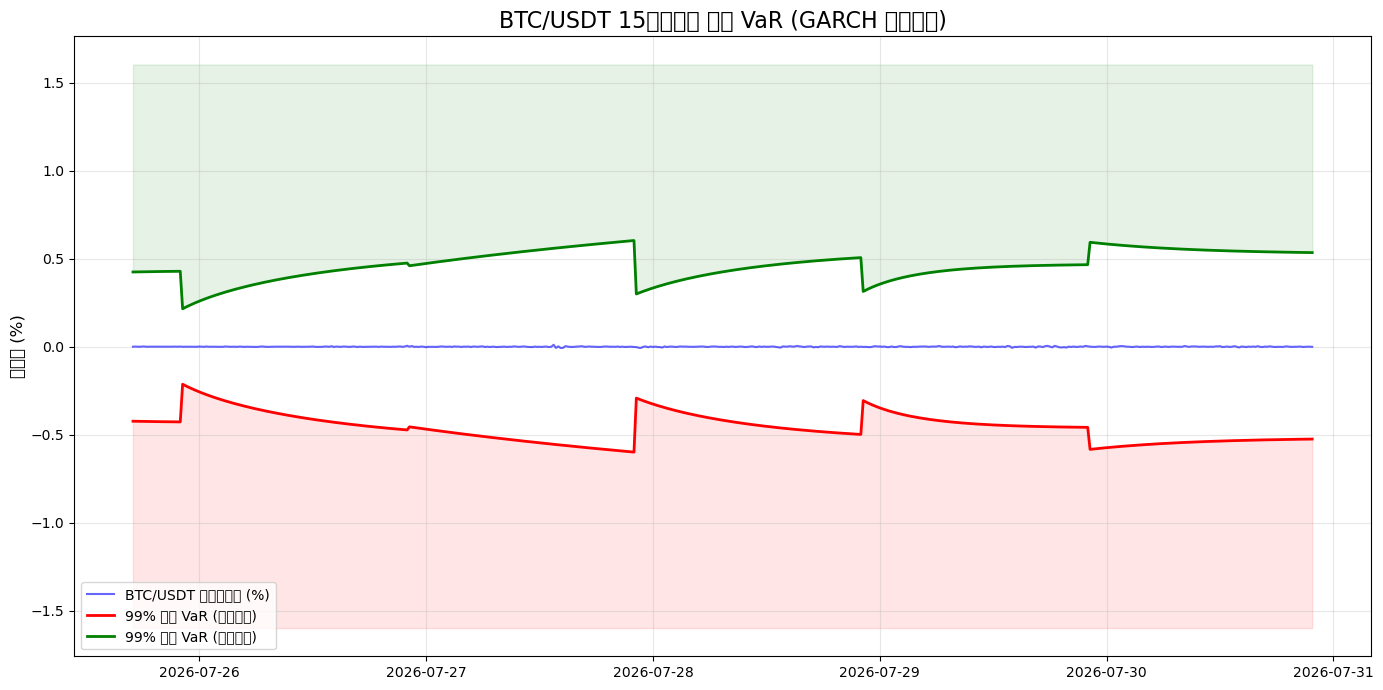


💡 【实时风控警报】根据最后一根 K 线预测:
当前 15 分钟的预期波动率 (Sigma) 为: 0.23%
99% 置信度下的 动态 VaR 为: -0.52%
解释: 在接下来的 15 分钟内，你有 99% 的概率，资产亏损不会超过 0.52%！


In [10]:
# 1. 准备数据：计算对数收益率，并放大 100 倍变成百分比 (%)
# 💡 注意：放大 100 倍是行业惯例，因为收益率数值太小（如 0.0001），GARCH 底层优化器很难收敛
df_15m['log_return'] = np.log(df_15m['close'] / df_15m['close'].shift(1))
returns = df_15m['log_return'].dropna() * 100  

def calculate_rolling_garch(returns, window_size=2000, refit_every=96):
    print(f"启动 GARCH 移动窗口计算 (总数据量: {len(returns)})...")
    out_of_sample_vol = pd.Series(index=returns.index, dtype=float)
    out_of_sample_mu = pd.Series(index=returns.index, dtype=float)
    
    n_samples = len(returns)
    
    for i in tqdm(range(window_size, n_samples, refit_every)):
        # 严格只用过去的数据
        train_window = returns.iloc[i - window_size : i]
        am = arch_model(train_window, mean='Constant', vol='Garch', p=1, q=1, dist='Normal')
        
        try:
            res = am.fit(disp='off', show_warning=False)
        except:
            continue
            
        steps_to_predict = min(refit_every, n_samples - i)
        forecasts = res.forecast(horizon=steps_to_predict, align='origin')
        
        # 提取真正的样本外预测值
        pred_vol = np.sqrt(forecasts.variance.iloc[-1].values)
        pred_mu = forecasts.mean.iloc[-1].values
        
        out_of_sample_vol.iloc[i : i + steps_to_predict] = pred_vol
        out_of_sample_mu.iloc[i : i + steps_to_predict] = pred_mu

    return out_of_sample_vol.dropna(), out_of_sample_mu.dropna()

# 1. 运行核心函数 (大概需要等待 1-2 分钟，看进度条)
oos_vol, oos_mu = calculate_rolling_garch(returns, window_size=2000, refit_every=96)

# ==========================================
# 2 & 4 合并: 计算严格样本外的 99% VaR (做多和做空)
# ==========================================
# 设定做多的 99% 风险底线 (防暴跌)
alpha_long = 0.01
z_score_long = stats.norm.ppf(alpha_long) 
oos_var_long = oos_mu + oos_vol * z_score_long  # 修复: 这里改用 oos_mu 和 oos_vol

# 设定做空的 99% 风险底线 (防暴涨)
alpha_short = 0.99
z_score_short = stats.norm.ppf(alpha_short) 
oos_var_short = oos_mu + oos_vol * z_score_short # 修复: 这里改用 oos_mu 和 oos_vol

# ==========================================
# 3. 把安全的数据合并到主 DataFrame 中
# ==========================================
df_15m['cond_vol_oos'] = oos_vol
df_15m['var_long_oos'] = oos_var_long
df_15m['var_short_oos'] = oos_var_short  # 修复: 把做空VaR也存进去，供后续画图用

# 砍掉前面没有波动率预测结果的 2000 行（即前20天）
df_ready = df_15m.dropna().copy()
print(f"\n✅ 移动窗口处理完毕！最终可用于特征工程的数据行数: {len(df_ready)}")


# ==========================================
# 5. 可视化：让“动态风控”变得直观
# ==========================================
# 为了看清楚细节，我们只截取最后 500 根 K 线（约 5 天的数据）来画图
plot_returns = df_ready['log_return'].tail(500)
plot_var_long = df_ready['var_long_oos'].tail(500)
plot_var_short = df_ready['var_short_oos'].tail(500) # 修复: 定义 plot_var_short

plt.figure(figsize=(14, 7))

# 画出实际收益率（蓝色柱子/线）
plt.plot(plot_returns.index, plot_returns, color='blue', alpha=0.6, label='BTC/USDT 实际收益率 (%)')

# 画出动态 VaR 预警线（红色实线 / 绿色实线）
plt.plot(plot_var_long.index, plot_var_long, color='red', linewidth=2, label='99% 动态 VaR (做多防线)')
plt.plot(plot_var_short.index, plot_var_short, color='green', linewidth=2, label='99% 动态 VaR (做空防线)')

# 填充 VaR 以下的极端危险区域
plt.fill_between(plot_var_long.index, plot_var_long, plot_var_long.min() - 1, color='red', alpha=0.1)
plt.fill_between(plot_var_short.index, plot_var_short, plot_var_short.max() + 1, color='green', alpha=0.1)

# 找出“突破做多防线”的黑天鹅时刻（实际亏损超过了 99% VaR 的点）
exceptions = plot_returns[plot_returns < plot_var_long]
if len(exceptions) > 0:
    plt.scatter(exceptions.index, exceptions, color='black', s=50, zorder=5, label='破防点 (VaR Exceptions)')

plt.title('BTC/USDT 15分钟级别 动态 VaR (GARCH 模型预测)', fontsize=16)
plt.ylabel('收益率 (%)', fontsize=12)
plt.legend(loc='lower left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ==========================================
# --- 计算最后一根 K 线的实时风险 ---
# ==========================================
last_vol = df_ready['cond_vol_oos'].iloc[-1]   # 修复: 从 df_ready 中取最后一个值
last_var = df_ready['var_long_oos'].iloc[-1]   # 修复: 从 df_ready 中取最后一个值

print(f"\n💡 【实时风控警报】根据最后一根 K 线预测:")
print(f"当前 15 分钟的预期波动率 (Sigma) 为: {last_vol:.2f}%")
print(f"99% 置信度下的 动态 VaR 为: {last_var:.2f}%")
print(f"解释: 在接下来的 15 分钟内，你有 99% 的概率，资产亏损不会超过 {abs(last_var):.2f}%！")


正在计算三重屏障标签 (时间屏障=12根K线)...

三重屏障标签分布情况 (0:跌穿底线, 1:震荡超时, 2:涨破天际):
label
1.0    21268
0.0    13711
2.0    12913
Name: count, dtype: int64

开始训练 XGBoost 模型 (已启用样本权重平衡)...

=== 进阶版 XGBoost 预测结果报告 ===
              precision    recall  f1-score   support

    Down (0)       0.32      0.30      0.31      3002
    Flat (1)       0.55      0.46      0.50      3944
      Up (2)       0.31      0.42      0.36      2633

    accuracy                           0.40      9579
   macro avg       0.40      0.39      0.39      9579
weighted avg       0.41      0.40      0.40      9579



<Figure size 1000x600 with 0 Axes>

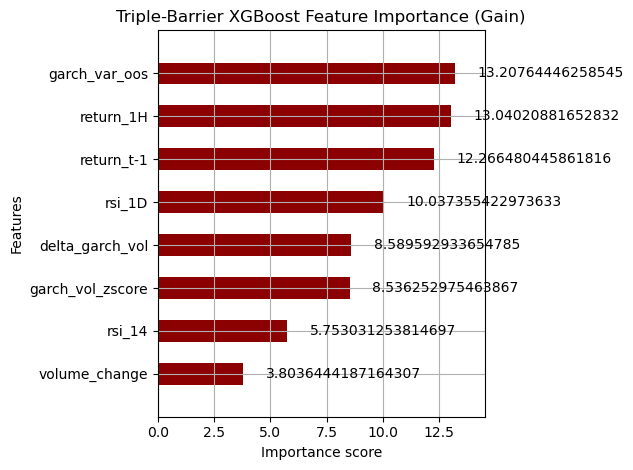

In [11]:
df_ready = df_15m.dropna().copy() # 基于上一步清洗后的数据

# 将 GARCH 输出的百分比 (如 2.5%) 转换为小数 (0.025)，方便计算
df_ready['garch_vol_oos'] = df_ready['cond_vol_oos'] / 100
df_ready['garch_var_oos'] = df_ready['var_long_oos'] / 100

# ==========================================
# 2. 特征工程 (保持不变，但使用 OOS 样本外数据)
# ==========================================
def create_features_oos(data):
    df = data.copy()
    
    df['return_t-1'] = df['close'].pct_change(1)
    df['volume_change'] = df['volume'].pct_change(1)
    df['rsi_14'] = ta.rsi(df['close'], length=14)
    
    # 24H Z-Score (使用无未来函数的 vol)
    window_24h = 96
    rolling_mean = df['garch_vol_oos'].rolling(window=window_24h).mean()
    rolling_std = df['garch_vol_oos'].rolling(window=window_24h).std()
    df['garch_vol_zscore'] = (df['garch_vol_oos'] - rolling_mean) / rolling_std
    
    df['delta_garch_vol'] = df['garch_vol_oos'].diff(1)
    df['return_1H'] = df['close'].pct_change(4)
    df['rsi_1D'] = ta.rsi(df['close'], length=96)
    
    return df.dropna()

df_features = create_features_oos(df_ready)

# ==========================================
# 3. 核心升级：动态三重屏障标签 (Triple-Barrier Method)
# ==========================================
def apply_triple_barrier(df, horizon=12, var_multiplier=1.0):
    """
    horizon: 时间屏障，未来 12 根 K 线 (3小时)
    var_multiplier: 动态屏障宽度乘数。用 GARCH_VaR 乘以这个系数作为止盈止损线。
    """
    print(f"\n正在计算三重屏障标签 (时间屏障={horizon}根K线)...")
    
    # 预分配 Label 列，默认 1 (震荡/观望)
    labels = np.ones(len(df))
    
    close_prices = df['close'].values
    # VaR 是负数，取绝对值作为边界宽度
    garch_var = df['garch_var_oos'].abs().values * var_multiplier 
    
    # 遍历每一根 K 线，模拟真实的未来轨迹 (Path Dependency)
    for i in range(len(df) - horizon):
        p0 = close_prices[i]
        
        # 动态计算当前时刻的上下屏障价格
        upper_barrier = p0 * (1 + garch_var[i])
        lower_barrier = p0 * (1 - garch_var[i])
        
        # 提取未来 horizon 根 K 线的价格轨迹
        path = close_prices[i+1 : i+1+horizon]
        
        # 寻找轨迹中第一次触碰上/下屏障的索引
        hit_upper = np.where(path >= upper_barrier)[0]
        hit_lower = np.where(path <= lower_barrier)[0]
        
        # 获取触碰的时间点（如果没有触碰，设为无穷大）
        idx_upper = hit_upper[0] if len(hit_upper) > 0 else np.inf
        idx_lower = hit_lower[0] if len(hit_lower) > 0 else np.inf
        
        # 逻辑判断：谁先被触碰？
        if idx_upper < idx_lower:
            labels[i] = 2  # 先碰到上屏障 -> 真正有效的上涨 (做多)
        elif idx_lower < idx_upper:
            labels[i] = 0  # 先碰到下屏障 -> 真正有效的下跌 (做空)
        else:
            labels[i] = 1  # 超时(时间屏障)或同时触碰(极罕见) -> 震荡不接 (观望)
            
    df['label'] = labels
    
    # 砍掉最后 horizon 行，因为它们没有足够的未来数据来判断屏障
    return df.iloc[:-horizon].copy()

# 应用三重屏障 (由于 GARCH VaR 是99%极限值，可能偏大，可以乘以 0.8 作为合理的止盈止损线)
df_labeled = apply_triple_barrier(df_features, horizon=12, var_multiplier=0.8)

print("\n三重屏障标签分布情况 (0:跌穿底线, 1:震荡超时, 2:涨破天际):")
print(df_labeled['label'].value_counts())

# ==========================================
# 4. XGBoost 模型训练与样本权重平衡 (Class Imbalance)
# ==========================================
feature_cols = [
    'return_t-1', 'volume_change', 'rsi_14', 
    'garch_vol_zscore', 'delta_garch_vol', 'garch_var_oos', 
    'return_1H', 'rsi_1D'
]

X = df_labeled[feature_cols]
y = df_labeled['label']

# 严格按时间切分训练/测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# 💡 核心优化：计算样本权重。
# 如果 '1'(震荡) 太多，'balanced' 模式会自动给 '0' 和 '2' 赋予极高的学习权重
# 强制 XGBoost 认真对待罕见但关键的突破信号！
train_weights = compute_sample_weight(class_weight='balanced', y=y_train)

# 初始化 XGBoost
xgb_model = xgb.XGBClassifier(
    objective='multi:softprob',
    num_class=3,
    max_depth=4, 
    learning_rate=0.03, # 稍微调低学习率，让加权学习更稳定
    n_estimators=300,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

print("\n开始训练 XGBoost 模型 (已启用样本权重平衡)...")
xgb_model.fit(
    X_train, y_train,
    sample_weight=train_weights,          # 💡 传入计算好的权重
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=False
)

# 预测测试集
y_pred = xgb_model.predict(X_test)

print("\n=== 进阶版 XGBoost 预测结果报告 ===")
print(classification_report(y_test, y_pred, target_names=['Down (0)', 'Flat (1)', 'Up (2)']))

# ==========================================
# 5. 特征重要性可视化
# ==========================================
plt.figure(figsize=(10, 6))
xgb.plot_importance(xgb_model, importance_type='gain', max_num_features=10, height=0.5, color='darkred')
plt.title('Triple-Barrier XGBoost Feature Importance (Gain)', fontsize=12)
plt.tight_layout()
plt.show()

In [12]:
# 提取测试集的特征
X_test_alpha = X_test.copy()

# ⚠️ 核心技巧：获取属于 0(跌), 1(平), 2(涨) 的概率矩阵
probs = xgb_model.predict_proba(X_test)

# 将概率拆解并存入 DataFrame 中
X_test_alpha['prob_down'] = probs[:, 0]  # 做空的概率
X_test_alpha['prob_flat'] = probs[:, 1]  # 震荡的概率
X_test_alpha['prob_up'] = probs[:, 2]    # 做多的概率

print("概率矩阵预览：")
print(X_test_alpha[['prob_down', 'prob_flat', 'prob_up']].head())

threshold_up = 0.40
threshold_down = 0.40 # 你模型的做空召回率高，做空阈值可以设高一点提高胜率

# 初始 Alpha 信号为 0 (空仓观望)
X_test_alpha['alpha_signal'] = 0

# 当做多概率大于阈值，发出 +1 信号
X_test_alpha.loc[X_test_alpha['prob_up'] > threshold_up, 'alpha_signal'] = 1

# 当做空概率大于阈值，发出 -1 信号
X_test_alpha.loc[X_test_alpha['prob_down'] > threshold_down, 'alpha_signal'] = -1

print("\n根据置信度过滤后的交易信号分布：")
print(X_test_alpha['alpha_signal'].value_counts())

# 假设你的初始资金为 10,000 U
# 我们希望每笔交易的潜在亏损(Risk)控制在总资金的 1% (即 100 U)
target_risk_per_trade = 0.01

# GARCH VaR 代表了极端的预期跌幅 (比如 0.02 就是预期可能跌 2%)
# 仓位大小 = 目标风险 / 预期风险
X_test_alpha['position_size'] = target_risk_per_trade / X_test_alpha['garch_var_oos'].abs()

# 设置最大杠杆限制（防止波动率极小时算出 100 倍杠杆）
max_leverage = 1
X_test_alpha['position_size'] = X_test_alpha['position_size'].clip(upper=max_leverage)

# 最终 Alpha 头寸 = 信号方向 * 仓位大小
X_test_alpha['target_position'] = X_test_alpha['alpha_signal'] * X_test_alpha['position_size']

print("\n最终的 Alpha 目标仓位 (部分展示)：")
print(X_test_alpha[['alpha_signal', 'garch_var_oos', 'position_size', 'target_position']].head(10))

概率矩阵预览：
                     prob_down  prob_flat   prob_up
timestamp                                          
2026-04-22 00:15:00   0.372905   0.153557  0.473538
2026-04-22 00:30:00   0.363208   0.237833  0.398959
2026-04-22 00:45:00   0.310148   0.333775  0.356077
2026-04-22 01:00:00   0.305370   0.350289  0.344341
2026-04-22 01:15:00   0.334070   0.195809  0.470121

根据置信度过滤后的交易信号分布：
alpha_signal
 0    5998
-1    1988
 1    1593
Name: count, dtype: int64

最终的 Alpha 目标仓位 (部分展示)：
                     alpha_signal  garch_var_oos  position_size  \
timestamp                                                         
2026-04-22 00:15:00             1      -0.005314            1.0   
2026-04-22 00:30:00             0      -0.005319            1.0   
2026-04-22 00:45:00             0      -0.005322            1.0   
2026-04-22 01:00:00             0      -0.005326            1.0   
2026-04-22 01:15:00             1      -0.005329            1.0   
2026-04-22 01:30:00             0      -0.005

In [13]:
# ==========================================
# 6. 向量化历史回测 (Backtesting)
# 附带在 xboost.py 的最末尾运行
# ==========================================
print("\n" + "="*40)
print("🚀 开始进行策略历史回测...")

# 我们把测试集的特征、信号以及原始的收盘价合并起来
horizon = 12  # 和标签的 horizon 保持一致

backtest_df = X_test_alpha.copy()
backtest_df['close'] = df_ready.loc[backtest_df.index, 'close']
backtest_df['market_return'] = backtest_df['close'].pct_change(1)

# 生成"锁仓版"的实际持仓：每次开仓后，接下来 horizon 根K线内仓位不变
locked_position = np.zeros(len(backtest_df))
i = 0
target_pos_arr = backtest_df['target_position'].values

while i < len(backtest_df):
    pos = target_pos_arr[i]
    if pos != 0:
        end = min(i + horizon, len(backtest_df))
        locked_position[i:end] = pos
        i = end  # 跳过这段持仓期，期间不再重新开仓
    else:
        i += 1

backtest_df['locked_position'] = locked_position

# 用锁仓后的仓位计算收益（依然shift(1)避免未来函数）
backtest_df['strategy_return'] = pd.Series(locked_position, index=backtest_df.index).shift(1) * backtest_df['market_return']

backtest_df['position_change'] = pd.Series(locked_position, index=backtest_df.index).diff().abs()
backtest_df['fee_cost'] = backtest_df['position_change'] * fee_rate
backtest_df['net_return'] = backtest_df['strategy_return'] - backtest_df['fee_cost']
# 清理 NaN 值
backtest_df.dropna(inplace=True)

# 计算累计收益率 (资金曲线)
backtest_df['cum_market'] = (1 + backtest_df['market_return']).cumprod()
backtest_df['cum_strategy'] = (1 + backtest_df['net_return']).cumprod()

# --- 统计关键回测指标 ---
total_return = backtest_df['cum_strategy'].iloc[-1] - 1
annualized_return = total_return * (365 * 24 * 4) / len(backtest_df) # 15分钟线年化乘数
sharpe_ratio = backtest_df['net_return'].mean() / backtest_df['net_return'].std() * np.sqrt(365 * 24 * 4)
max_drawdown = (backtest_df['cum_strategy'] / backtest_df['cum_strategy'].cummax() - 1).min()

print(f"📊 回测时间跨度: {backtest_df.index[0]} 至 {backtest_df.index[-1]}")
print(f"💰 策略累计收益: {total_return:.2%}")
print(f"📈 策略年化收益: {annualized_return:.2%}")
print(f"📉 最大回撤 (MDD): {max_drawdown:.2%}")
print(f"⚖️ 夏普比率 (Sharpe): {sharpe_ratio:.2f}")

# --- 画出资金曲线对比图 ---
plt.figure(figsize=(14, 7))
plt.plot(backtest_df.index, backtest_df['cum_market'], label='BTC 现货死拿 (Buy & Hold)', color='grey', alpha=0.6)
plt.plot(backtest_df.index, backtest_df['cum_strategy'], label='XGBoost 动态仓位策略', color='red', linewidth=2)

# 标记出开多和开空的点位
longs = backtest_df[backtest_df['alpha_signal'] == 1]
shorts = backtest_df[backtest_df['alpha_signal'] == -1]
plt.scatter(longs.index, backtest_df.loc[longs.index, 'cum_strategy'], marker='^', color='green', s=40, label='开多信号')
plt.scatter(shorts.index, backtest_df.loc[shorts.index, 'cum_strategy'], marker='v', color='red', s=40, label='开空信号')

plt.title('Triple-Barrier XGBoost Strategy vs BTC Market Return', fontsize=16)
plt.ylabel('累计净值 (Initial = 1.0)', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


🚀 开始进行策略历史回测...


NameError: name 'fee_rate' is not defined

In [ ]:
# 找出每次开仓的起点
trade_starts = np.where((locked_position != 0) & (np.roll(locked_position, 1) != locked_position))[0]
for idx in trade_starts[:20]:
    direction = locked_position[idx]
    entry_price = backtest_df['close'].iloc[idx]
    exit_idx = min(idx + horizon, len(backtest_df) - 1)
    exit_price = backtest_df['close'].iloc[exit_idx]
    pnl = direction * (exit_price / entry_price - 1)
    print(f"{backtest_df.index[idx]} 方向={direction:.2f} 盈亏={pnl:.2%}")

2026-04-22 00:30:00 方向=1.00 盈亏=1.63%
2026-04-22 05:15:00 方向=-1.00 盈亏=0.36%
2026-04-22 08:30:00 方向=1.00 盈亏=0.34%
2026-04-22 23:30:00 方向=-1.00 盈亏=0.49%
2026-04-23 02:45:00 方向=1.00 盈亏=0.12%
2026-04-23 06:45:00 方向=1.00 盈亏=-0.70%
2026-04-23 10:15:00 方向=1.00 盈亏=0.27%
2026-04-23 17:00:00 方向=1.00 盈亏=-0.05%
2026-04-23 20:45:00 方向=1.00 盈亏=0.46%
2026-04-24 01:15:00 方向=1.00 盈亏=-0.55%
2026-04-24 06:00:00 方向=1.00 盈亏=-0.55%
2026-04-24 09:15:00 方向=1.00 盈亏=0.99%
2026-04-24 13:30:00 方向=1.00 盈亏=-0.61%
2026-04-24 18:15:00 方向=1.00 盈亏=0.17%
2026-04-25 16:00:00 方向=-1.00 盈亏=0.16%
2026-04-25 22:30:00 方向=-1.00 盈亏=0.04%
2026-04-26 05:00:00 方向=1.00 盈亏=-0.07%
2026-04-26 19:15:00 方向=-1.00 盈亏=-0.42%
2026-04-26 22:15:00 方向=1.00 盈亏=0.47%
2026-04-27 05:15:00 方向=1.00 盈亏=-0.34%


In [ ]:
horizon = 12
close = backtest_df['close'].values
target_pos_arr = backtest_df['target_position'].values

trades = []  # 记录每笔交易
locked_position = np.zeros(len(backtest_df))

i = 0
while i < len(backtest_df):
    pos = target_pos_arr[i]
    if pos != 0:
        end = min(i + horizon, len(backtest_df) - 1)
        entry_price = close[i]
        exit_price = close[end]
        simple_return = pos * (exit_price / entry_price - 1)  # 整笔only算一次
        trades.append({
            'entry_time': backtest_df.index[i],
            'exit_time': backtest_df.index[end],
            'direction': pos,
            'entry_price': entry_price,
            'exit_price': exit_price,
            'pnl': simple_return,
            'fee': abs(pos) * fee_rate * 2  # 开仓+平仓各扣一次
        })
        locked_position[i:end+1] = pos
        i = end + 1
    else:
        i += 1

trades_df = pd.DataFrame(trades)
trades_df['net_pnl'] = trades_df['pnl'] - trades_df['fee']

print(f"总交易笔数: {len(trades_df)}")
print(f"胜率: {(trades_df['net_pnl'] > 0).mean():.2%}")
print(f"平均每笔净收益: {trades_df['net_pnl'].mean():.4%}")
print(f"盈亏比 (avg win / avg |loss|): "
      f"{trades_df[trades_df.net_pnl>0]['net_pnl'].mean() / abs(trades_df[trades_df.net_pnl<0]['net_pnl'].mean()):.2f}")

# 按时间段拆开看：4-6月 vs 6月以后
trades_df['period'] = np.where(trades_df['entry_time'] < '2026-06-01', '4-6月暴跌期', '6月后震荡期')
print(trades_df.groupby('period').agg(
    笔数=('net_pnl', 'count'),
    胜率=('net_pnl', lambda x: (x > 0).mean()),
    平均收益=('net_pnl', 'mean'),
    做多占比=('direction', lambda x: (x > 0).mean())
))

总交易笔数: 500
胜率: 39.20%
平均每笔净收益: -0.1460%
盈亏比 (avg win / avg |loss|): 0.88
          笔数        胜率      平均收益      做多占比
period                                    
4-6月暴跌期  209  0.373206 -0.001572  0.502392
6月后震荡期   291  0.405498 -0.001380  0.508591


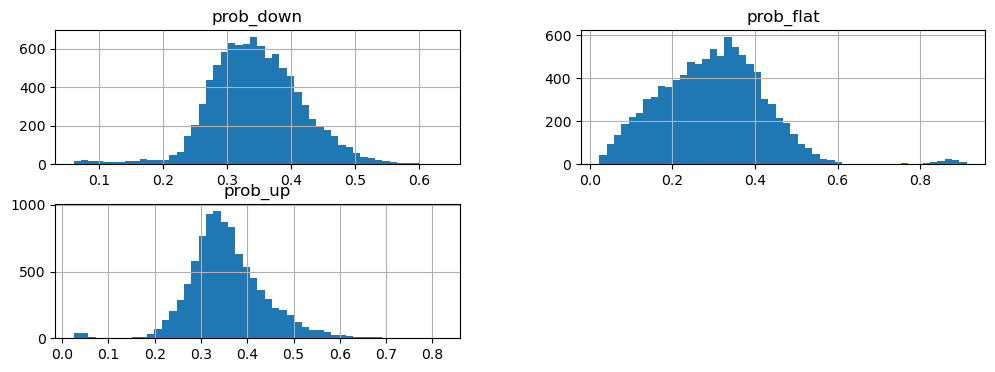

              precision    recall  f1-score   support

        Down       0.32      0.30      0.31      3002
        Flat       0.55      0.46      0.50      3944
          Up       0.31      0.42      0.36      2633

    accuracy                           0.40      9579
   macro avg       0.40      0.39      0.39      9579
weighted avg       0.41      0.40      0.40      9579



In [ ]:
import matplotlib.pyplot as plt
X_test_alpha[['prob_down','prob_flat','prob_up']].hist(bins=50, figsize=(12,4))
plt.show()

# 更关键：看模型预测和实际label的对齐程度
print(classification_report(y_test, xgb_model.predict(X_test), target_names=['Down','Flat','Up']))

In [ ]:
import numpy as np
import pandas as pd

np.random.seed(42)

horizon = 12

# 全部统一从 backtest_df 取，保证长度一致
close = backtest_df['close'].values
original_signal = backtest_df['alpha_signal'].values
position_size = backtest_df['position_size'].values

n_runs = 200
random_results = []

for run in range(n_runs):
    random_direction = np.where(
        original_signal != 0,
        np.random.choice([-1, 1], size=len(original_signal)),
        0
    )
    random_target_position = random_direction * position_size

    trades = []
    i = 0
    n = len(random_target_position)
    while i < n:
        pos = random_target_position[i]
        if pos != 0:
            end = min(i + horizon, n - 1)
            entry_price = close[i]
            exit_price = close[end]
            simple_return = pos * (exit_price / entry_price - 1)
            fee = abs(pos) * fee_rate * 2
            trades.append(simple_return - fee)
            i = end + 1
        else:
            i += 1

    if len(trades) > 0:
        trades_arr = np.array(trades)
        random_results.append({
            'run': run,
            'n_trades': len(trades_arr),
            'win_rate': (trades_arr > 0).mean(),
            'avg_pnl': trades_arr.mean(),
            'total_pnl': trades_arr.sum()
        })

random_df = pd.DataFrame(random_results)

print("=== 随机方向基准 (200次模拟) ===")
print(f"平均胜率: {random_df['win_rate'].mean():.2%} (标准差: {random_df['win_rate'].std():.2%})")
print(f"平均每笔收益: {random_df['avg_pnl'].mean():.4%} (标准差: {random_df['avg_pnl'].std():.4%})")
print(f"平均总收益: {random_df['total_pnl'].mean():.2%}")

model_avg_pnl = -0.001460  # 换成你实际的模型平均每笔净收益
percentile = (random_df['avg_pnl'] < model_avg_pnl).mean()
print(f"\n模型的平均每笔收益，在随机方向的200次模拟中排在第 {percentile:.1%} 分位")

=== 随机方向基准 (200次模拟) ===
平均胜率: 41.69% (标准差: 2.04%)
平均每笔收益: -0.0984% (标准差: 0.0346%)
平均总收益: -49.20%

模型的平均每笔收益，在随机方向的200次模拟中排在第 8.0% 分位


In [ ]:
###验证模型是不是学反掉了。
# 直接验证：概率最高的类别 vs 实际发生的方向，是否一致
pred_label = xgb_model.predict(X_test)  # 0=跌 1=平 2=涨
actual_label = y_test.values

# 只看模型预测为"涨"或"跌"（排除"平"）的样本，看方向准不准
mask = pred_label != 1
print(f"排除Flat后，方向预测准确率: {(pred_label[mask] == actual_label[mask]).mean():.2%}")
print(f"（如果这个数字明显<50%，说明模型是系统性地把方向搞反了）")

排除Flat后，方向预测准确率: 31.86%
（如果这个数字明显<50%，说明模型是系统性地把方向搞反了）


In [ ]:
print("模型的 classes_ 顺序:", xgb_model.classes_)

模型的 classes_ 顺序: [0 1 2]


In [ ]:
#反向测试
pred_label = xgb_model.predict(X_test)
actual_label = y_test.values
mask = pred_label != 1

# 把 0 和 2 互换，1 保持不变
flipped_pred = np.where(pred_label == 0, 2, np.where(pred_label == 2, 0, pred_label))

print(f"原始方向准确率: {(pred_label[mask] == actual_label[mask]).mean():.2%}")
print(f"翻转后方向准确率: {(flipped_pred[mask] == actual_label[mask]).mean():.2%}")

原始方向准确率: 31.86%
翻转后方向准确率: 34.18%


In [ ]:
#ok不是学反了，另有其他原因。

pred_label_train = xgb_model.predict(X_train)
actual_label_train = y_train.values
mask_train = pred_label_train != 1
print(f"训练集内方向准确率: {(pred_label_train[mask_train] == actual_label_train[mask_train]).mean():.2%}")

训练集内方向准确率: 48.11%


C:\Users\10914\AppData\Local\Temp\ipykernel_3500\3099623296.py:9: UserWarning: Glyph 35757 (\N{CJK UNIFIED IDEOGRAPH-8BAD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\10914\AppData\Local\Temp\ipykernel_3500\3099623296.py:9: UserWarning: Glyph 32451 (\N{CJK UNIFIED IDEOGRAPH-7EC3}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\10914\AppData\Local\Temp\ipykernel_3500\3099623296.py:9: UserWarning: Glyph 38598 (\N{CJK UNIFIED IDEOGRAPH-96C6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\10914\AppData\Local\Temp\ipykernel_3500\3099623296.py:9: UserWarning: Glyph 27979 (\N{CJK UNIFIED IDEOGRAPH-6D4B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\10914\AppData\Local\Temp\ipykernel_3500\3099623296.py:9: UserWarning: Glyph 35797 (\N{CJK UNIFIED IDEOGRAPH-8BD5}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
d:\Anaconda3\envs\dataanalysis\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 35757

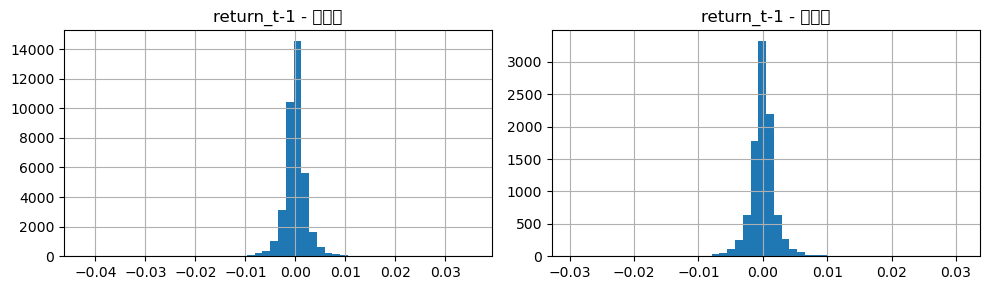

return_t-1: 训练集均值=0.0000, 测试集均值=-0.0000


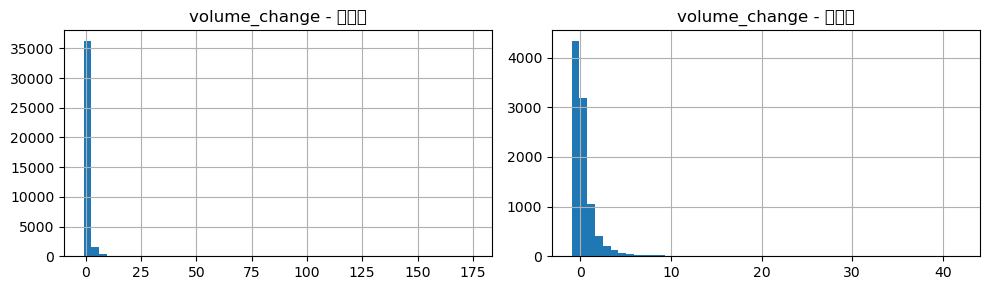

volume_change: 训练集均值=0.4114, 测试集均值=0.4204


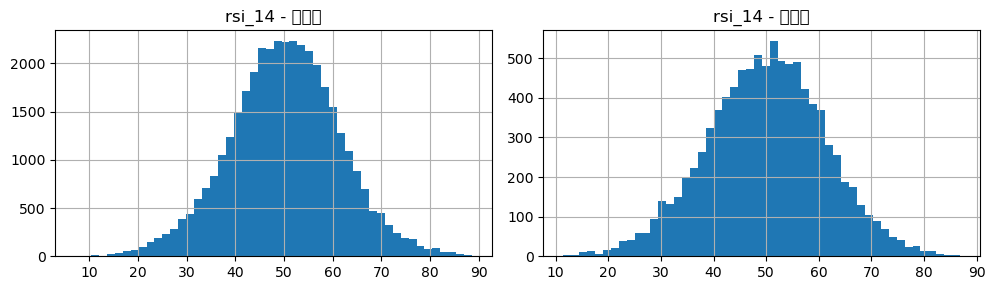

rsi_14: 训练集均值=50.1911, 测试集均值=49.9496


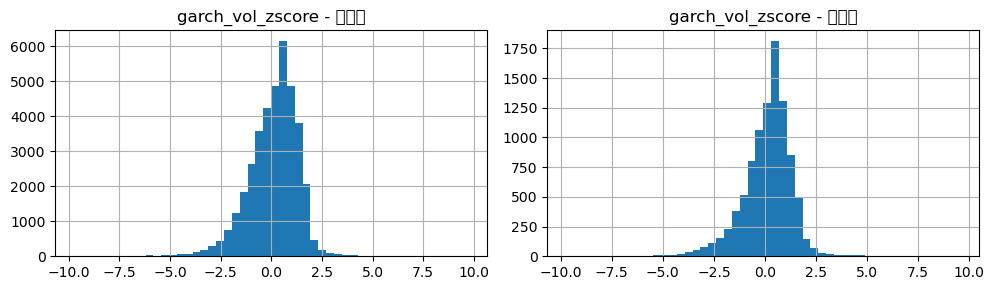

garch_vol_zscore: 训练集均值=0.1024, 测试集均值=0.1016


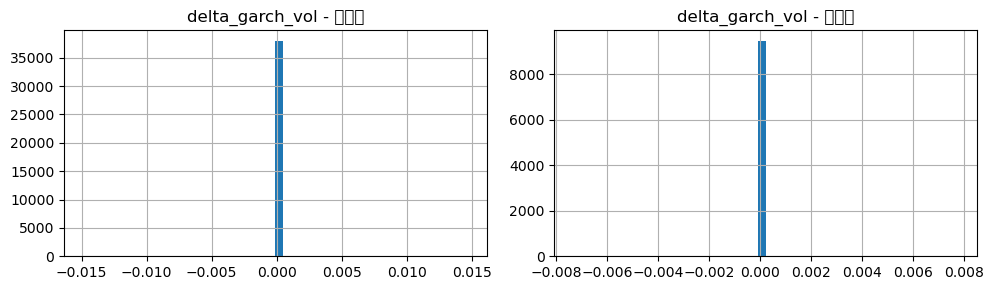

delta_garch_vol: 训练集均值=-0.0000, 测试集均值=0.0000


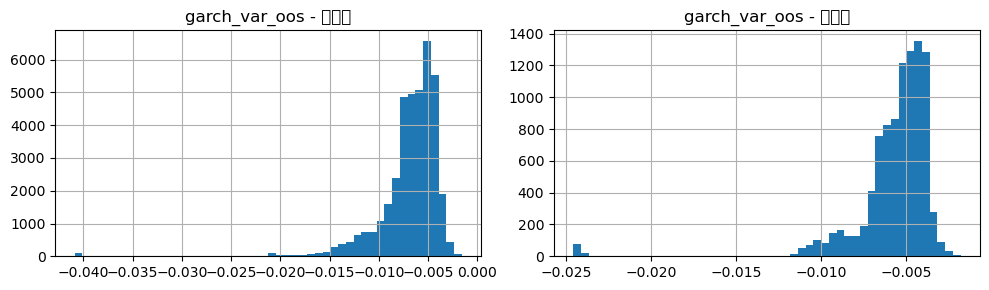

garch_var_oos: 训练集均值=-0.0068, 测试集均值=-0.0057


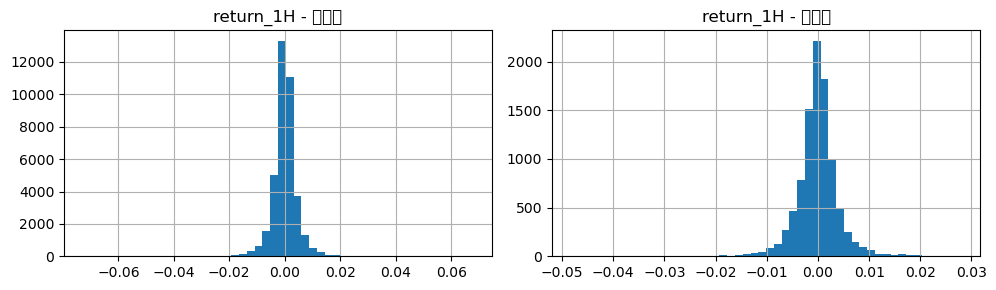

return_1H: 训练集均值=0.0000, 测试集均值=-0.0001


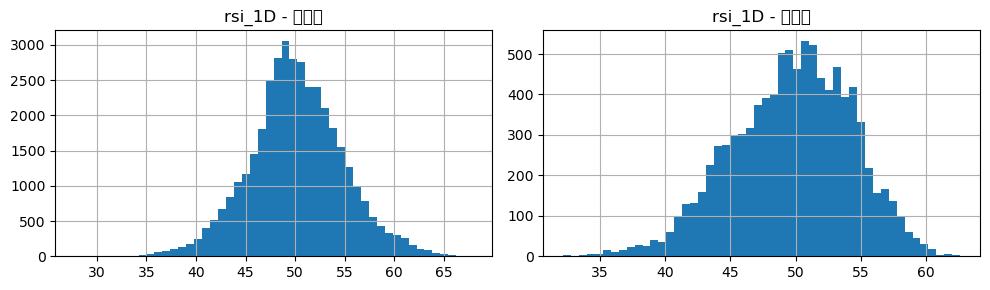

rsi_1D: 训练集均值=50.1475, 测试集均值=49.6978


In [ ]:
import matplotlib.pyplot as plt

for col in feature_cols:
    fig, ax = plt.subplots(1, 2, figsize=(10, 3))
    X_train[col].hist(bins=50, ax=ax[0])
    ax[0].set_title(f'{col} - 训练集')
    X_test[col].hist(bins=50, ax=ax[1])
    ax[1].set_title(f'{col} - 测试集')
    plt.tight_layout()
    plt.show()
    print(f"{col}: 训练集均值={X_train[col].mean():.4f}, 测试集均值={X_test[col].mean():.4f}")

In [ ]:
print(f"训练集时间范围: {X_train.index.min()} 至 {X_train.index.max()}")
print(f"测试集时间范围: {X_test.index.min()} 至 {X_test.index.max()}")

训练集时间范围: 2025-03-18 22:00:00 至 2026-04-22 00:00:00
测试集时间范围: 2026-04-22 00:15:00 至 2026-07-30 18:45:00



正在计算三重屏障标签 (时间屏障=12根K线)...

三重屏障标签分布情况 (0:跌穿底线, 1:震荡超时, 2:涨破天际):
label
1.0    21268
0.0    13711
2.0    12913
Name: count, dtype: int64

加入regime特征前，dropna前总行数: 47892
dropna后剩余行数: 45013 (丢弃 2879 行)

开始训练 XGBoost 模型 (已启用样本权重平衡 + regime特征)...

=== 加入Regime特征后的 XGBoost 预测结果报告 ===
              precision    recall  f1-score   support

    Down (0)       0.36      0.32      0.34      2865
    Flat (1)       0.57      0.49      0.52      3672
      Up (2)       0.31      0.41      0.35      2466

    accuracy                           0.41      9003
   macro avg       0.41      0.40      0.40      9003
weighted avg       0.43      0.41      0.42      9003


排除Flat后，方向预测准确率: 32.89%
（此前不含regime特征时的基准是 31.86%，现在看是否有改善）


C:\Users\10914\AppData\Local\Temp\ipykernel_3500\3732800563.py:153: UserWarning: Glyph 21152 (\N{CJK UNIFIED IDEOGRAPH-52A0}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\10914\AppData\Local\Temp\ipykernel_3500\3732800563.py:153: UserWarning: Glyph 20837 (\N{CJK UNIFIED IDEOGRAPH-5165}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\10914\AppData\Local\Temp\ipykernel_3500\3732800563.py:153: UserWarning: Glyph 29305 (\N{CJK UNIFIED IDEOGRAPH-7279}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\10914\AppData\Local\Temp\ipykernel_3500\3732800563.py:153: UserWarning: Glyph 24449 (\N{CJK UNIFIED IDEOGRAPH-5F81}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\10914\AppData\Local\Temp\ipykernel_3500\3732800563.py:153: UserWarning: Glyph 21518 (\N{CJK UNIFIED IDEOGRAPH-540E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\10914\AppData\Local\Temp\ipykernel_3500\3732800563.py:153: UserWarning: Glyph 30340 (\

<Figure size 1000x600 with 0 Axes>

d:\Anaconda3\envs\dataanalysis\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 21152 (\N{CJK UNIFIED IDEOGRAPH-52A0}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\Anaconda3\envs\dataanalysis\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 20837 (\N{CJK UNIFIED IDEOGRAPH-5165}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\Anaconda3\envs\dataanalysis\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 29305 (\N{CJK UNIFIED IDEOGRAPH-7279}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\Anaconda3\envs\dataanalysis\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 24449 (\N{CJK UNIFIED IDEOGRAPH-5F81}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\Anaconda3\envs\dataanalysis\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 21518 (\N{CJK UNIFIED IDEOGRAPH-540E}) m

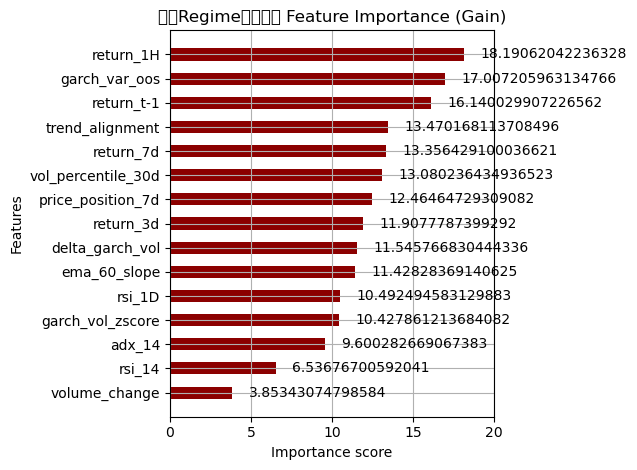

In [ ]:
#加入趋势特征

df_ready = df_15m.dropna().copy() # 基于上一步清洗后的数据

# 将 GARCH 输出的百分比 (如 2.5%) 转换为小数 (0.025)，方便计算
df_ready['garch_vol_oos'] = df_ready['cond_vol_oos'] / 100
df_ready['garch_var_oos'] = df_ready['var_long_oos'] / 100

# ==========================================
# 2. 特征工程 (保持不变，但使用 OOS 样本外数据)
# ==========================================
def add_regime_features(df):
    df = df.copy()
    
    # ① 趋势方向和强度：用长短均线的相对位置和斜率，判断当前是不是在趋势中
    df['ema_20'] = df['close'].ewm(span=20).mean()
    df['ema_60'] = df['close'].ewm(span=60).mean()
    df['ema_120'] = df['close'].ewm(span=120).mean()
    
    # 均线排列：多头排列(20>60>120)还是空头排列，量化成一个连续值而非布尔
    df['trend_alignment'] = (df['ema_20'] - df['ema_120']) / df['ema_120']
    
    # 均线斜率：捕捉趋势的"新鲜度"，而不只是位置
    df['ema_60_slope'] = df['ema_60'].pct_change(20)
    
    # ② 趋势强度指标 ADX：区分"有方向的趋势市" vs "无方向的震荡市"
    # 用 pandas_ta 自带的 adx
    adx_result = ta.adx(df['high'], df['low'], df['close'], length=14)
    df['adx_14'] = adx_result['ADX_14']
    
    # ③ 波动率的历史分位数：而不只是z-score，分位数能更好刻画"现在是极端还是正常"
    df['vol_percentile_30d'] = df['garch_vol_oos'].rolling(96*30).rank(pct=True)
    
    # ④ 价格在近期高低点中的位置：捕捉是不是处于突破/破位的关键位置
    rolling_high = df['close'].rolling(96*7).max()  # 近7天最高
    rolling_low = df['close'].rolling(96*7).min()   # 近7天最低
    df['price_position_7d'] = (df['close'] - rolling_low) / (rolling_high - rolling_low + 1e-9)
    
    # ⑤ 长周期动量方向：比如过去3天、7天的累计收益，捕捉更大周期的趋势背景
    df['return_3d'] = df['close'].pct_change(96*3)
    df['return_7d'] = df['close'].pct_change(96*7)
    
    return df

df_features_v2 = add_regime_features(df_features)

# ==========================================
# 3. 核心升级：动态三重屏障标签 (Triple-Barrier Method)
# ==========================================
def apply_triple_barrier(df, horizon=12, var_multiplier=1.0):
    """
    horizon: 时间屏障，未来 12 根 K 线 (3小时)
    var_multiplier: 动态屏障宽度乘数。用 GARCH_VaR 乘以这个系数作为止盈止损线。
    """
    print(f"\n正在计算三重屏障标签 (时间屏障={horizon}根K线)...")
    
    labels = np.ones(len(df))
    close_prices = df['close'].values
    garch_var = df['garch_var_oos'].abs().values * var_multiplier 
    
    for i in range(len(df) - horizon):
        p0 = close_prices[i]
        upper_barrier = p0 * (1 + garch_var[i])
        lower_barrier = p0 * (1 - garch_var[i])
        path = close_prices[i+1 : i+1+horizon]
        
        hit_upper = np.where(path >= upper_barrier)[0]
        hit_lower = np.where(path <= lower_barrier)[0]
        idx_upper = hit_upper[0] if len(hit_upper) > 0 else np.inf
        idx_lower = hit_lower[0] if len(hit_lower) > 0 else np.inf
        
        if idx_upper < idx_lower:
            labels[i] = 2
        elif idx_lower < idx_upper:
            labels[i] = 0
        else:
            labels[i] = 1
            
    df['label'] = labels
    return df.iloc[:-horizon].copy()

# ⚠️ 关键修正：这里必须用 df_features_v2（含regime特征），而不是旧的 df_features
df_labeled = apply_triple_barrier(df_features_v2, horizon=12, var_multiplier=0.8)

print("\n三重屏障标签分布情况 (0:跌穿底线, 1:震荡超时, 2:涨破天际):")
print(df_labeled['label'].value_counts())

# ==========================================
# 4. XGBoost 模型训练与样本权重平衡 (Class Imbalance)
# ==========================================
# ⚠️ 关键修正：加入新的 regime 特征
feature_cols = [
    'return_t-1', 'volume_change', 'rsi_14', 
    'garch_vol_zscore', 'delta_garch_vol', 'garch_var_oos', 
    'return_1H', 'rsi_1D',
    # 新增的regime特征
    'trend_alignment', 'ema_60_slope', 'adx_14',
    'vol_percentile_30d', 'price_position_7d',
    'return_3d', 'return_7d'
]

# 加入regime特征(尤其是 return_3d/7d, vol_percentile_30d)之后会引入更多NaN
# （比如 rolling(96*30) 需要30天数据才有值），这里要检查一下丢了多少行
print(f"\n加入regime特征前，dropna前总行数: {len(df_labeled)}")
df_labeled_clean = df_labeled.dropna(subset=feature_cols + ['label']).copy()
print(f"dropna后剩余行数: {len(df_labeled_clean)} (丢弃 {len(df_labeled) - len(df_labeled_clean)} 行)")

X = df_labeled_clean[feature_cols]
y = df_labeled_clean['label']

# 严格按时间切分训练/测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

train_weights = compute_sample_weight(class_weight='balanced', y=y_train)

xgb_model = xgb.XGBClassifier(
    objective='multi:softprob',
    num_class=3,
    max_depth=4, 
    learning_rate=0.03,
    n_estimators=300,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

print("\n开始训练 XGBoost 模型 (已启用样本权重平衡 + regime特征)...")
xgb_model.fit(
    X_train, y_train,
    sample_weight=train_weights,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=False
)

y_pred = xgb_model.predict(X_test)

print("\n=== 加入Regime特征后的 XGBoost 预测结果报告 ===")
print(classification_report(y_test, y_pred, target_names=['Down (0)', 'Flat (1)', 'Up (2)']))

# 顺手把方向准确率也打印出来，方便直接对比之前 31.86% 这个基准
pred_label = xgb_model.predict(X_test)
actual_label = y_test.values
mask = pred_label != 1
print(f"\n排除Flat后，方向预测准确率: {(pred_label[mask] == actual_label[mask]).mean():.2%}")
print(f"（此前不含regime特征时的基准是 31.86%，现在看是否有改善）")

# ==========================================
# 5. 特征重要性可视化
# ==========================================
plt.figure(figsize=(10, 6))
xgb.plot_importance(xgb_model, importance_type='gain', max_num_features=15, height=0.5, color='darkred')
plt.title('加入Regime特征后的 Feature Importance (Gain)', fontsize=12)
plt.tight_layout()
plt.show()

100%|██████████| 27/27 [00:15<00:00,  1.77it/s]

            test_start            test_end  direction_acc  overall_acc  \
0  2025-07-16 21:45:00 2025-07-30 21:30:00       0.289340     0.351190   
1  2025-07-30 21:45:00 2025-08-13 21:30:00       0.340266     0.364583   
2  2025-08-13 21:45:00 2025-08-27 21:30:00       0.312792     0.350446   
3  2025-08-27 21:45:00 2025-09-10 21:30:00       0.327645     0.469494   
4  2025-09-10 21:45:00 2025-09-24 21:30:00       0.292208     0.409226   
5  2025-09-24 21:45:00 2025-10-08 21:30:00       0.245128     0.322173   
6  2025-10-08 21:45:00 2025-10-22 21:30:00       0.353791     0.445685   
7  2025-10-22 21:45:00 2025-11-05 21:30:00       0.320451     0.505952   
8  2025-11-05 21:45:00 2025-11-19 21:30:00       0.381890     0.453125   
9  2025-11-19 21:45:00 2025-12-03 21:30:00       0.349014     0.419643   
10 2025-12-03 21:45:00 2025-12-17 21:30:00       0.270000     0.496280   
11 2025-12-17 21:45:00 2025-12-31 21:30:00       0.232143     0.619792   
12 2025-12-31 21:45:00 2026-01-14 21:3


d:\Anaconda3\envs\dataanalysis\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 28369 (\N{CJK UNIFIED IDEOGRAPH-6ED1}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\Anaconda3\envs\dataanalysis\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 21160 (\N{CJK UNIFIED IDEOGRAPH-52A8}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\Anaconda3\envs\dataanalysis\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 31383 (\N{CJK UNIFIED IDEOGRAPH-7A97}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\Anaconda3\envs\dataanalysis\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 21475 (\N{CJK UNIFIED IDEOGRAPH-53E3}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\Anaconda3\envs\dataanalysis\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 65306 (\N{FULLWIDTH COLON}) missing fro

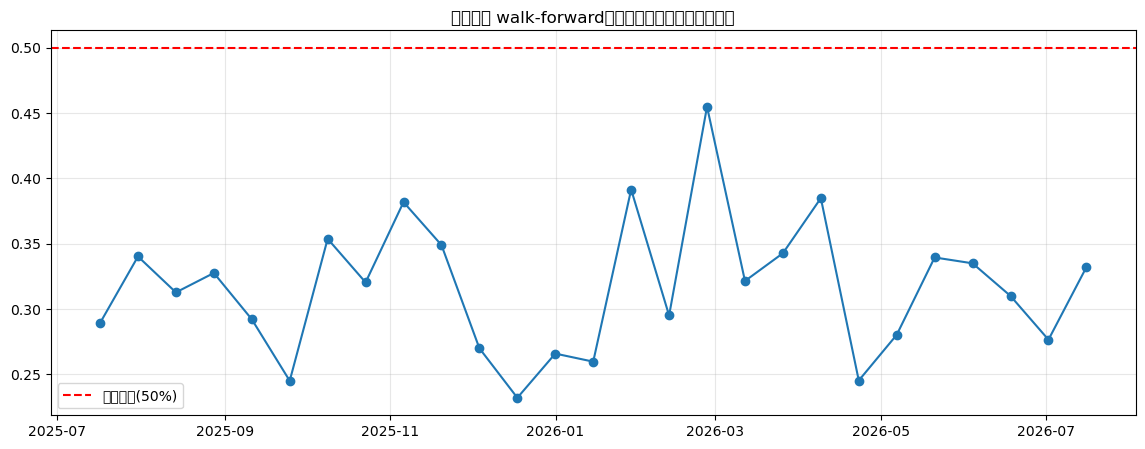

In [ ]:
#滑动窗口验证
from sklearn.metrics import accuracy_score

def walk_forward_validation(df, feature_cols, label_col='label', 
                             train_window=96*90,   # 训练窗口：90天
                             test_window=96*14,    # 每次预测：14天
                             step=96*14):           # 滑动步长：14天（不重叠）
    
    results = []
    n = len(df)
    
    for start in tqdm(range(0, n - train_window - test_window, step)):
        train_end = start + train_window
        test_end = train_end + test_window
        
        train_slice = df.iloc[start:train_end]
        test_slice = df.iloc[train_end:test_end]
        
        X_tr = train_slice[feature_cols]
        y_tr = train_slice[label_col]
        X_te = test_slice[feature_cols]
        y_te = test_slice[label_col]
        
        weights = compute_sample_weight(class_weight='balanced', y=y_tr)
        
        model = xgb.XGBClassifier(
            objective='multi:softprob', num_class=3,
            max_depth=4, learning_rate=0.03, n_estimators=300,
            subsample=0.8, colsample_bytree=0.8, random_state=42
        )
        model.fit(X_tr, y_tr, sample_weight=weights, verbose=False)
        
        pred = model.predict(X_te)
        mask = pred != 1  # 排除Flat，只看方向准确率
        
        dir_acc = (pred[mask] == y_te.values[mask]).mean() if mask.sum() > 0 else np.nan
        overall_acc = accuracy_score(y_te, pred)
        
        results.append({
            'train_start': train_slice.index[0],
            'train_end': train_slice.index[-1],
            'test_start': test_slice.index[0],
            'test_end': test_slice.index[-1],
            'direction_acc': dir_acc,
            'overall_acc': overall_acc,
            'n_direction_signals': mask.sum()
        })
    
    return pd.DataFrame(results)

wf_results = walk_forward_validation(df_labeled_clean, feature_cols)
print(wf_results[['test_start', 'test_end', 'direction_acc', 'overall_acc', 'n_direction_signals']])

# 关键：看方向准确率随时间是否稳定，还是每段都不一样甚至正负交替
plt.figure(figsize=(14, 5))
plt.plot(wf_results['test_start'], wf_results['direction_acc'], marker='o')
plt.axhline(0.5, color='red', linestyle='--', label='随机水平(50%)')
plt.title('滑动窗口 walk-forward：方向预测准确率随时间变化')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

100%|██████████| 27/27 [00:15<00:00,  1.77it/s]

            test_start            test_end  direction_acc  overall_acc  \
0  2025-07-16 21:45:00 2025-07-30 21:30:00       0.465561     0.351190   
1  2025-07-30 21:45:00 2025-08-13 21:30:00       0.496098     0.364583   
2  2025-08-13 21:45:00 2025-08-27 21:30:00       0.520052     0.350446   
3  2025-08-27 21:45:00 2025-09-10 21:30:00       0.543210     0.469494   
4  2025-09-10 21:45:00 2025-09-24 21:30:00       0.552923     0.409226   
5  2025-09-24 21:45:00 2025-10-08 21:30:00       0.377515     0.322173   
6  2025-10-08 21:45:00 2025-10-22 21:30:00       0.530941     0.445685   
7  2025-10-22 21:45:00 2025-11-05 21:30:00       0.515347     0.505952   
8  2025-11-05 21:45:00 2025-11-19 21:30:00       0.539340     0.453125   
9  2025-11-19 21:45:00 2025-12-03 21:30:00       0.485277     0.419643   
10 2025-12-03 21:45:00 2025-12-17 21:30:00       0.554672     0.496280   
11 2025-12-17 21:45:00 2025-12-31 21:30:00       0.589744     0.619792   
12 2025-12-31 21:45:00 2026-01-14 21:3


d:\Anaconda3\envs\dataanalysis\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 20462 (\N{CJK UNIFIED IDEOGRAPH-4FEE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\Anaconda3\envs\dataanalysis\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 27491 (\N{CJK UNIFIED IDEOGRAPH-6B63}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\Anaconda3\envs\dataanalysis\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 21518 (\N{CJK UNIFIED IDEOGRAPH-540E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\Anaconda3\envs\dataanalysis\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 65306 (\N{FULLWIDTH COLON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\Anaconda3\envs\dataanalysis\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 30495 (\N{CJK UNIFIED IDEOGRAPH-771F}) missing fro

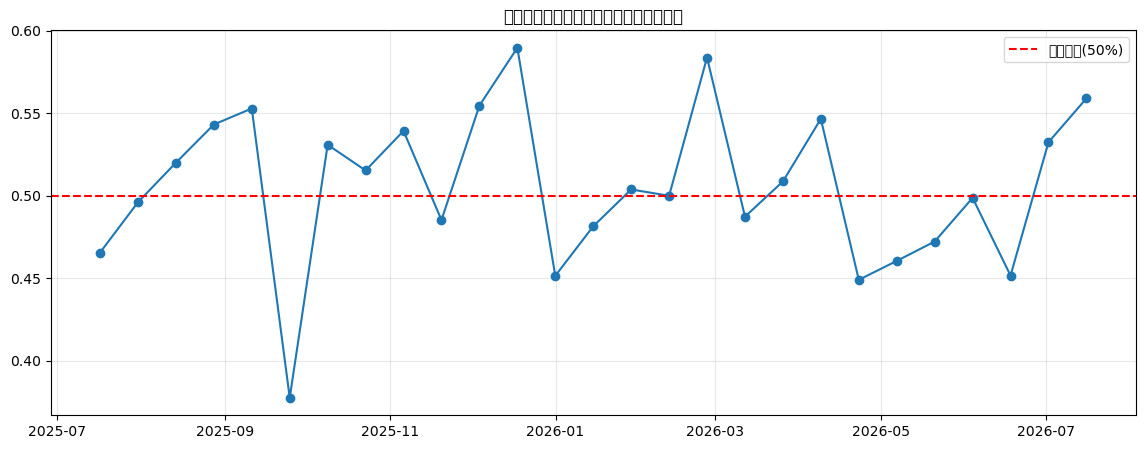

In [ ]:
#mask = pred != 1 这行本身有逻辑漏洞
def walk_forward_validation(df, feature_cols, label_col='label', 
                             train_window=96*90,
                             test_window=96*14,
                             step=96*14):
    
    results = []
    n = len(df)
    
    for start in tqdm(range(0, n - train_window - test_window, step)):
        train_end = start + train_window
        test_end = train_end + test_window
        
        train_slice = df.iloc[start:train_end]
        test_slice = df.iloc[train_end:test_end]
        
        X_tr, y_tr = train_slice[feature_cols], train_slice[label_col]
        X_te, y_te = test_slice[feature_cols], test_slice[label_col]
        
        weights = compute_sample_weight(class_weight='balanced', y=y_tr)
        
        model = xgb.XGBClassifier(
            objective='multi:softprob', num_class=3,
            max_depth=4, learning_rate=0.03, n_estimators=300,
            subsample=0.8, colsample_bytree=0.8, random_state=42
        )
        model.fit(X_tr, y_tr, sample_weight=weights, verbose=False)
        
        probs = model.predict_proba(X_te)
        actual = y_te.values
        
        # ⚠️ 关键修正：mask 用真实标签筛选，只看"真的发生了方向性行情"的样本
        mask = actual != 1
        
        if mask.sum() > 0:
            # 在这些真正有方向的样本里，只比较 prob_up vs prob_down 谁更高，
            # 完全不管 Flat 概率，纯粹看方向判断能力
            prob_up = probs[:, 2]
            prob_down = probs[:, 0]
            direction_guess = np.where(prob_up[mask] > prob_down[mask], 2, 0)
            dir_acc = (direction_guess == actual[mask]).mean()
        else:
            dir_acc = np.nan
        
        pred_full = model.predict(X_te)
        overall_acc = accuracy_score(y_te, pred_full)
        
        results.append({
            'train_start': train_slice.index[0],
            'train_end': train_slice.index[-1],
            'test_start': test_slice.index[0],
            'test_end': test_slice.index[-1],
            'direction_acc': dir_acc,
            'overall_acc': overall_acc,
            'n_direction_samples': mask.sum()
        })
    
    return pd.DataFrame(results)

wf_results = walk_forward_validation(df_labeled_clean, feature_cols)
print(wf_results[['test_start', 'test_end', 'direction_acc', 'overall_acc', 'n_direction_samples']])

print(f"\n修正后方向准确率均值: {wf_results['direction_acc'].mean():.2%}")
print(f"修正后方向准确率标准差: {wf_results['direction_acc'].std():.2%}")

plt.figure(figsize=(14, 5))
plt.plot(wf_results['test_start'], wf_results['direction_acc'], marker='o')
plt.axhline(0.5, color='red', linestyle='--', label='随机水平(50%)')
plt.title('修正后：真实方向性样本上的方向准确率')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
from scipy import stats as sp_stats

mean_acc = wf_results['direction_acc'].mean()
std_acc = wf_results['direction_acc'].std()
n_windows = len(wf_results)

# 单样本t检验：均值是否显著不等于0.5
t_stat, p_value = sp_stats.ttest_1samp(wf_results['direction_acc'].dropna(), 0.5)

print(f"27个窗口方向准确率均值: {mean_acc:.4f}")
print(f"标准差: {std_acc:.4f}")
print(f"t统计量: {t_stat:.4f}, p-value: {p_value:.4f}")
print("结论: ", end="")
if p_value < 0.05:
    print(f"均值显著{'高于' if mean_acc > 0.5 else '低于'}50%，存在统计显著的{'正' if mean_acc>0.5 else '负'}alpha")
else:
    print("均值与50%无统计显著差异，目前更接近'零alpha'，噪音主导")

27个窗口方向准确率均值: 0.5058
标准差: 0.0474
t统计量: 0.6403, p-value: 0.5276
结论: 均值与50%无统计显著差异，目前更接近'零alpha'，噪音主导


In [ ]:
#27个窗口方向准确率均值: 0.5058
#标准差: 0.0474
#t统计量: 0.6403, p-value: 0.5276
#结论: 均值与50%无统计显著差异，目前更接近'零alpha'，噪音主导
#路径A：接受"零alpha"这个结论，先别再加特征了，回去把交易结构本身的期望值改善

#回忆一下最早测出来的：即使完全随机猜方向，因为屏障不对称+手续费，期望值也是 -0.0984%/笔。这是个"结构性负期望"，跟模型好坏无关。如果方向预测这条路短期很难突破50%，那更实际的杠杆点是把这个负期望的"地板"抬高：

#检查 var_multiplier=0.8 这个屏障宽度是不是让"先碰到止损"的概率结构性偏高（比如做个简单模拟：固定方向为多头，不同 var_multiplier 下的胜率曲线，找到让胜率和盈亏比最平衡的宽度）；
#重新核实 fee_rate=0.0005 是否符合你实际的手续费+滑点情况（如果实际滑点更大，这个负期望的地板会更深，值得先精确测一下）；
#这条路的好处是：不依赖"模型能不能学到东西"，改善的是确定性的机械结构。

#路径B：换一个更长的horizon，降低噪声

#15分钟K线预测3小时方向，噪音本身就很大（这也是很多量化团队在这个频段很难做出稳定alpha的原因）。可以尝试把 horizon 从12（3小时）拉长到比如48（12小时）甚至更长，同时对应地调整 resample到1小时线做特征计算，看方向准确率的均值和标准差会不会变得更稳定——更长周期通常信噪比更好，虽然交易频率会降低。

#路径C：继续加特征，但要更有针对性，而不是"多多益善"

#如果还想继续在方向预测上挖潜力，与其继续堆技术指标，不如针对已知偏弱的时段（04-06月，也就是暴跌期）去想：这段时间缺的到底是什么信息？比如：

#资金费率(funding rate)——永续合约暴跌时往往伴随资金费率由正转负，这是市场情绪的直接信号，而目前完全没用到；
#多空持仓量比、爆仓数据这类衍生品特有的信息（如果OKX API能拿到）；
#这类信息和技术指标的相关性低，更有可能带来增量，而不是继续在RSI/均线家族里打转。


正在网格搜索最优屏障宽度组合...
     avg_pnl  win_rate  n_trades  upper_mult  lower_mult  direction
7  -0.000674  0.373093      3999         0.5         1.1         -1
24 -0.000719  0.366842      3999         1.1         0.5          1
5  -0.000741  0.387847      3999         0.5         0.9         -1
15 -0.000795  0.398350      3999         0.7         1.1         -1
16 -0.000809  0.378345      3999         0.9         0.5          1
3  -0.000835  0.415604      3999         0.5         0.7         -1
13 -0.000858  0.413353      3999         0.7         0.9         -1
26 -0.000869  0.392598      3999         1.1         0.7          1
23 -0.000892  0.414354      3999         0.9         1.1         -1
8  -0.000909  0.404101      3999         0.7         0.5          1

✅ 选定最优屏障宽度: upper_mult=0.5, lower_mult=1.1

正在用优化后的屏障宽度计算标签 (upper_mult=0.5, lower_mult=1.1)...

新标签分布 (0:跌穿底线, 1:震荡超时, 2:涨破天际):
label_v3
2.0    20668
1.0    18707
0.0     8517
Name: count, dtype: int64

实际使用的特征数: 15
清理NaN后剩余行数: 4501

100%|██████████| 27/27 [00:15<00:00,  1.77it/s]
C:\Users\10914\AppData\Local\Temp\ipykernel_3500\1408412344.py:263: UserWarning: Glyph 32047 (\N{CJK UNIFIED IDEOGRAPH-7D2F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\10914\AppData\Local\Temp\ipykernel_3500\1408412344.py:263: UserWarning: Glyph 35745 (\N{CJK UNIFIED IDEOGRAPH-8BA1}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\10914\AppData\Local\Temp\ipykernel_3500\1408412344.py:263: UserWarning: Glyph 20928 (\N{CJK UNIFIED IDEOGRAPH-51C0}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\10914\AppData\Local\Temp\ipykernel_3500\1408412344.py:263: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAPH-503C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\10914\AppData\Local\Temp\ipykernel_3500\1408412344.py:263: UserWarning: Glyph 20248 (\N{CJK UNIFIED IDEOGRAPH-4F18}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\10914\AppData\Local\Temp\ipykernel_350

生成信号总数: 36288，其中非零信号数: 30208

🚀 优化交易结构后的回测结果
总交易笔数: 2702
胜率: 42.60%
平均每笔净收益: -0.1345%
盈亏比: 0.92
累计净收益 (简单加总): -363.48%


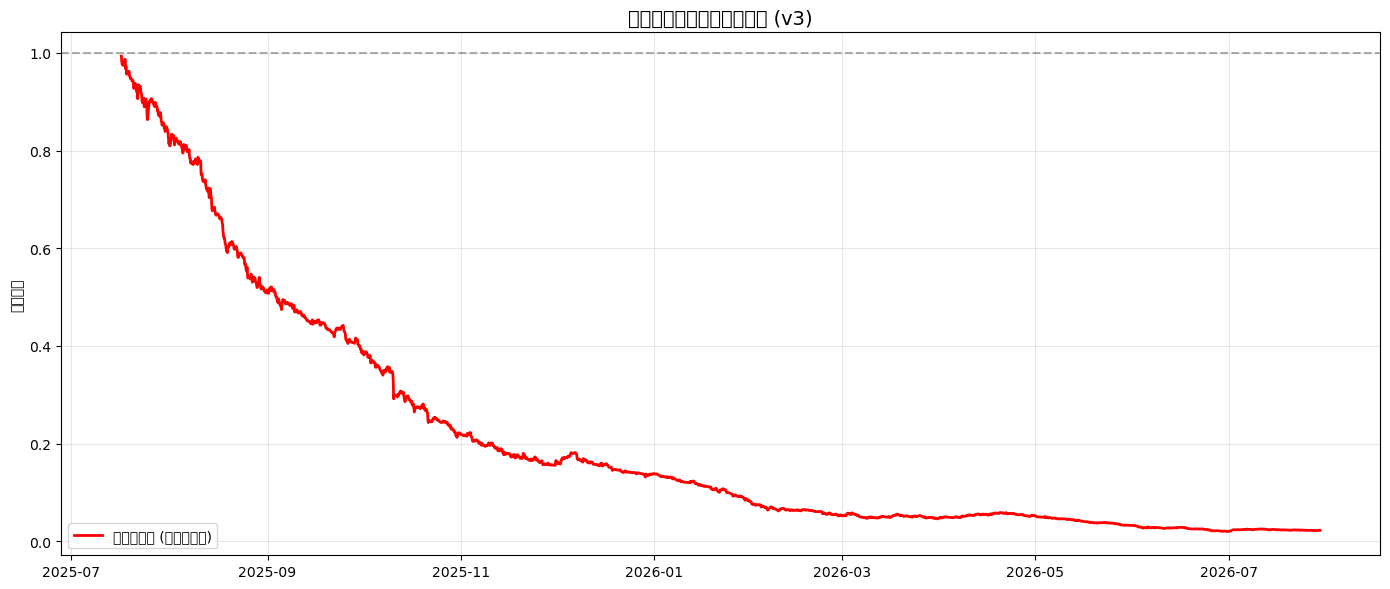


分时段表现:
             笔数        胜率      平均收益
period_v3                          
4-6月暴跌期    2277  0.420290 -0.001449
6月后震荡期      425  0.456471 -0.000788


In [ ]:
# ==========================================================
# 优化交易结构后的完整回测框架 (v3)
# 全部使用 _v3 后缀，避免和之前notebook里的变量冲突
# ==========================================================

# ----------------------------------------------------------
# 第1步：网格搜索最优非对称屏障宽度（纯结构性期望值，不涉及模型）
# ----------------------------------------------------------
def simulate_asymmetric_barrier_v3(df, horizon=12, upper_mult=0.8, lower_mult=0.8, 
                                     direction=1, fee_rate_v3=0.0005):
    close_prices_v3 = df['close'].values
    garch_var_base_v3 = df['garch_var_oos'].abs().values
    n_v3 = len(df)
    pnls_v3 = []
    
    for i in range(0, n_v3 - horizon, horizon):
        p0_v3 = close_prices_v3[i]
        upper_barrier_v3 = p0_v3 * (1 + garch_var_base_v3[i] * upper_mult)
        lower_barrier_v3 = p0_v3 * (1 - garch_var_base_v3[i] * lower_mult)
        path_v3 = close_prices_v3[i+1 : i+1+horizon]
        
        hit_upper_v3 = np.where(path_v3 >= upper_barrier_v3)[0]
        hit_lower_v3 = np.where(path_v3 <= lower_barrier_v3)[0]
        idx_upper_v3 = hit_upper_v3[0] if len(hit_upper_v3) > 0 else np.inf
        idx_lower_v3 = hit_lower_v3[0] if len(hit_lower_v3) > 0 else np.inf
        
        if direction == 1:
            if idx_upper_v3 < idx_lower_v3:
                pnl_v3 = garch_var_base_v3[i] * upper_mult
            elif idx_lower_v3 < idx_upper_v3:
                pnl_v3 = -garch_var_base_v3[i] * lower_mult
            else:
                pnl_v3 = (path_v3[-1] / p0_v3 - 1) if len(path_v3) > 0 else 0
        else:
            if idx_lower_v3 < idx_upper_v3:
                pnl_v3 = garch_var_base_v3[i] * lower_mult
            elif idx_upper_v3 < idx_lower_v3:
                pnl_v3 = -garch_var_base_v3[i] * upper_mult
            else:
                pnl_v3 = -(path_v3[-1] / p0_v3 - 1) if len(path_v3) > 0 else 0
        
        pnls_v3.append(pnl_v3 - fee_rate_v3 * 2)
    
    pnls_v3 = np.array(pnls_v3)
    return {
        'avg_pnl': pnls_v3.mean(),
        'win_rate': (pnls_v3 > 0).mean(),
        'n_trades': len(pnls_v3)
    }

print("正在网格搜索最优屏障宽度组合...")
grid_results_v3 = []
for um_v3 in [0.5, 0.7, 0.9, 1.1]:
    for lm_v3 in [0.5, 0.7, 0.9, 1.1]:
        for direction_v3 in [1, -1]:
            r_v3 = simulate_asymmetric_barrier_v3(
                df_ready, upper_mult=um_v3, lower_mult=lm_v3, direction=direction_v3
            )
            r_v3.update({'upper_mult': um_v3, 'lower_mult': lm_v3, 'direction': direction_v3})
            grid_results_v3.append(r_v3)

grid_df_v3 = pd.DataFrame(grid_results_v3)
print(grid_df_v3.sort_values('avg_pnl', ascending=False).head(10))

# 自动选出全局最优的上下轨宽度（取 avg_pnl 最高的一组，忽略方向，因为方向交给模型判断）
# 这里我们分别取多头和空头视角下各自的最优宽度，再取二者的平均作为对称/近似对称的基础
best_row_v3 = grid_df_v3.sort_values('avg_pnl', ascending=False).iloc[0]
best_upper_mult_v3 = best_row_v3['upper_mult']
best_lower_mult_v3 = best_row_v3['lower_mult']
print(f"\n✅ 选定最优屏障宽度: upper_mult={best_upper_mult_v3}, lower_mult={best_lower_mult_v3}")

# ----------------------------------------------------------
# 第2步：用最优屏障宽度重新打三重屏障标签
# ----------------------------------------------------------
def apply_triple_barrier_v3(df, horizon=12, upper_mult=0.8, lower_mult=0.8):
    print(f"\n正在用优化后的屏障宽度计算标签 (upper_mult={upper_mult}, lower_mult={lower_mult})...")
    labels_v3 = np.ones(len(df))
    close_prices_v3 = df['close'].values
    garch_var_base_v3 = df['garch_var_oos'].abs().values
    
    for i in range(len(df) - horizon):
        p0_v3 = close_prices_v3[i]
        upper_barrier_v3 = p0_v3 * (1 + garch_var_base_v3[i] * upper_mult)
        lower_barrier_v3 = p0_v3 * (1 - garch_var_base_v3[i] * lower_mult)
        path_v3 = close_prices_v3[i+1 : i+1+horizon]
        
        hit_upper_v3 = np.where(path_v3 >= upper_barrier_v3)[0]
        hit_lower_v3 = np.where(path_v3 <= lower_barrier_v3)[0]
        idx_upper_v3 = hit_upper_v3[0] if len(hit_upper_v3) > 0 else np.inf
        idx_lower_v3 = hit_lower_v3[0] if len(hit_lower_v3) > 0 else np.inf
        
        if idx_upper_v3 < idx_lower_v3:
            labels_v3[i] = 2
        elif idx_lower_v3 < idx_upper_v3:
            labels_v3[i] = 0
        else:
            labels_v3[i] = 1
            
    df = df.copy()
    df['label_v3'] = labels_v3
    return df.iloc[:-horizon].copy()

horizon_v3 = 12

# 复用你已经算好的regime特征（df_features_v2），如果还没跑过这步，先跑 add_regime_features(df_features)
df_features_for_v3 = add_regime_features(df_ready) if 'df_features_v2' not in dir() else df_features_v2.copy()

df_labeled_v3 = apply_triple_barrier_v3(
    df_features_for_v3, horizon=horizon_v3, 
    upper_mult=best_upper_mult_v3, lower_mult=best_lower_mult_v3
)

print("\n新标签分布 (0:跌穿底线, 1:震荡超时, 2:涨破天际):")
print(df_labeled_v3['label_v3'].value_counts())

# ----------------------------------------------------------
# 第3步：特征列表 + 清理NaN
# ----------------------------------------------------------
feature_cols_v3 = [
    'return_t-1', 'volume_change', 'rsi_14', 
    'garch_vol_zscore', 'delta_garch_vol', 'garch_var_oos', 
    'return_1H', 'rsi_1D',
    'trend_alignment', 'ema_60_slope', 'adx_14',
    'vol_percentile_30d', 'price_position_7d',
    'return_3d', 'return_7d'
]

# 只保留真正存在于df中的列（防止有的特征你之前没跑过）
feature_cols_v3 = [c for c in feature_cols_v3 if c in df_labeled_v3.columns]
print(f"\n实际使用的特征数: {len(feature_cols_v3)}")

df_labeled_clean_v3 = df_labeled_v3.dropna(subset=feature_cols_v3 + ['label_v3']).copy()
print(f"清理NaN后剩余行数: {len(df_labeled_clean_v3)}")

# ----------------------------------------------------------
# 第4步：Walk-forward 训练 + 用修正后的方向判断法生成完整历史信号
# ----------------------------------------------------------
def walk_forward_backtest_v3(df, feature_cols, label_col='label_v3',
                               train_window_v3=96*90, test_window_v3=96*14, step_v3=96*14,
                               prob_gap_threshold_v3=0.05):
    """
    每个窗口用train_window训练，在test_window上预测，
    用 prob_up - prob_down 的差值来决定方向和是否交易（差值越大，信号越强）
    返回所有窗口拼接起来的、完整的样本外信号序列
    """
    n_v3 = len(df)
    all_signals_v3 = []
    
    for start_v3 in tqdm(range(0, n_v3 - train_window_v3 - test_window_v3, step_v3)):
        train_end_v3 = start_v3 + train_window_v3
        test_end_v3 = train_end_v3 + test_window_v3
        
        train_slice_v3 = df.iloc[start_v3:train_end_v3]
        test_slice_v3 = df.iloc[train_end_v3:test_end_v3]
        
        X_tr_v3 = train_slice_v3[feature_cols]
        y_tr_v3 = train_slice_v3[label_col]
        X_te_v3 = test_slice_v3[feature_cols]
        
        weights_v3 = compute_sample_weight(class_weight='balanced', y=y_tr_v3)
        
        model_v3 = xgb.XGBClassifier(
            objective='multi:softprob', num_class=3,
            max_depth=4, learning_rate=0.03, n_estimators=300,
            subsample=0.8, colsample_bytree=0.8, random_state=42
        )
        model_v3.fit(X_tr_v3, y_tr_v3, sample_weight=weights_v3, verbose=False)
        
        probs_v3 = model_v3.predict_proba(X_te_v3)
        prob_down_v3 = probs_v3[:, 0]
        prob_up_v3 = probs_v3[:, 2]
        prob_gap_v3 = prob_up_v3 - prob_down_v3
        
        # 只有差值超过阈值才开仓，差值本身也决定仓位大小的置信度权重
        signal_v3 = np.where(prob_gap_v3 > prob_gap_threshold_v3, 1,
                     np.where(prob_gap_v3 < -prob_gap_threshold_v3, -1, 0))
        
        window_result_v3 = pd.DataFrame({
            'signal_v3': signal_v3,
            'prob_gap_v3': prob_gap_v3
        }, index=test_slice_v3.index)
        
        all_signals_v3.append(window_result_v3)
    
    return pd.concat(all_signals_v3)

print("\n开始 Walk-Forward 训练并生成样本外信号...")
signals_v3 = walk_forward_backtest_v3(df_labeled_clean_v3, feature_cols_v3)
print(f"生成信号总数: {len(signals_v3)}，其中非零信号数: {(signals_v3['signal_v3'] != 0).sum()}")

# ----------------------------------------------------------
# 第5步：仓位大小 + 按"整笔交易"结算的回测（不逐bar复利）
# ----------------------------------------------------------
backtest_base_v3 = df_labeled_clean_v3.loc[signals_v3.index].copy()
backtest_base_v3['signal_v3'] = signals_v3['signal_v3']
backtest_base_v3['prob_gap_v3'] = signals_v3['prob_gap_v3']

target_risk_per_trade_v3 = 0.01
max_leverage_v3 = 1.5  # 先保守设置，避免重蹈杠杆放大损耗的覆辙

backtest_base_v3['position_size_v3'] = (
    target_risk_per_trade_v3 / backtest_base_v3['garch_var_oos'].abs()
).clip(upper=max_leverage_v3)

backtest_base_v3['target_position_v3'] = (
    backtest_base_v3['signal_v3'] * backtest_base_v3['position_size_v3']
)

close_arr_v3 = backtest_base_v3['close'].values
pos_arr_v3 = backtest_base_v3['target_position_v3'].values
index_arr_v3 = backtest_base_v3.index

trades_v3 = []
i_v3 = 0
n_bt_v3 = len(backtest_base_v3)

while i_v3 < n_bt_v3:
    pos_v3 = pos_arr_v3[i_v3]
    if pos_v3 != 0:
        end_v3 = min(i_v3 + horizon_v3, n_bt_v3 - 1)
        entry_price_v3 = close_arr_v3[i_v3]
        exit_price_v3 = close_arr_v3[end_v3]
        simple_return_v3 = pos_v3 * (exit_price_v3 / entry_price_v3 - 1)
        fee_v3 = abs(pos_v3) * fee_rate * 2
        trades_v3.append({
            'entry_time': index_arr_v3[i_v3],
            'exit_time': index_arr_v3[end_v3],
            'direction': np.sign(pos_v3),
            'position_size': abs(pos_v3),
            'pnl': simple_return_v3,
            'fee': fee_v3,
            'net_pnl': simple_return_v3 - fee_v3
        })
        i_v3 = end_v3 + 1
    else:
        i_v3 += 1

trades_df_v3 = pd.DataFrame(trades_v3)

print("\n" + "="*40)
print("🚀 优化交易结构后的回测结果")
print("="*40)
print(f"总交易笔数: {len(trades_df_v3)}")
print(f"胜率: {(trades_df_v3['net_pnl'] > 0).mean():.2%}")
print(f"平均每笔净收益: {trades_df_v3['net_pnl'].mean():.4%}")
win_avg_v3 = trades_df_v3[trades_df_v3.net_pnl > 0]['net_pnl'].mean()
loss_avg_v3 = abs(trades_df_v3[trades_df_v3.net_pnl < 0]['net_pnl'].mean())
print(f"盈亏比: {win_avg_v3 / loss_avg_v3:.2f}")
print(f"累计净收益 (简单加总): {trades_df_v3['net_pnl'].sum():.2%}")

# 累计净值曲线（用交易发生的顺序累乘，而不是逐bar）
trades_df_v3 = trades_df_v3.sort_values('entry_time').reset_index(drop=True)
trades_df_v3['cum_net_value'] = (1 + trades_df_v3['net_pnl']).cumprod()

plt.figure(figsize=(14, 6))
plt.plot(trades_df_v3['entry_time'], trades_df_v3['cum_net_value'], 
         color='red', linewidth=2, label='优化后策略 (按交易结算)')
plt.axhline(1.0, color='black', linestyle='--', alpha=0.3)
plt.title('优化交易结构后的资金曲线 (v3)', fontsize=14)
plt.ylabel('累计净值')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 按时间段拆开看，方便和之前的结果直接对比
trades_df_v3['period_v3'] = np.where(
    trades_df_v3['entry_time'] < '2026-06-01', '4-6月暴跌期', '6月后震荡期'
)
print("\n分时段表现:")
print(trades_df_v3.groupby('period_v3').agg(
    笔数=('net_pnl', 'count'),
    胜率=('net_pnl', lambda x: (x > 0).mean()),
    平均收益=('net_pnl', 'mean')
))

In [ ]:
# ==========================================================
# 阈值敏感性扫描：提高 prob_gap 门槛，用"数量换质量"
# ==========================================================
def evaluate_threshold_v3(signals_df, backtest_base, horizon, fee_rate_v3, threshold_v3):
    mask_v3 = signals_df['prob_gap_v3'].abs() > threshold_v3
    filtered_signal_v3 = np.where(
        mask_v3, np.sign(signals_df['prob_gap_v3']), 0
    )
    
    close_arr = backtest_base['close'].values
    position_size_arr = backtest_base['position_size_v3'].values
    n = len(backtest_base)
    
    trades = []
    i = 0
    while i < n:
        sig = filtered_signal_v3[i]
        if sig != 0:
            end = min(i + horizon, n - 1)
            entry_price = close_arr[i]
            exit_price = close_arr[end]
            pos = sig * position_size_arr[i]
            simple_return = pos * (exit_price / entry_price - 1)
            fee = abs(pos) * fee_rate_v3 * 2
            trades.append(simple_return - fee)
            i = end + 1
        else:
            i += 1
    
    trades = np.array(trades)
    if len(trades) == 0:
        return None
    return {
        'threshold': threshold_v3,
        'n_trades': len(trades),
        'win_rate': (trades > 0).mean(),
        'avg_pnl': trades.mean(),
        'total_simple_sum': trades.sum()
    }

threshold_scan_v3 = []
for th_v3 in [0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40]:
    res_v3 = evaluate_threshold_v3(
        signals_v3, backtest_base_v3, horizon_v3, fee_rate, th_v3
    )
    if res_v3:
        threshold_scan_v3.append(res_v3)

threshold_scan_df_v3 = pd.DataFrame(threshold_scan_v3)
print(threshold_scan_df_v3)

   threshold  n_trades  win_rate   avg_pnl  total_simple_sum
0       0.05      2702  0.425981 -0.001345         -3.634765
1       0.10      2477  0.426726 -0.001179         -2.919793
2       0.15      2171  0.434362 -0.001166         -2.530822
3       0.20      1826  0.429901 -0.001281         -2.338650
4       0.25      1492  0.442359 -0.000941         -1.403604
5       0.30      1187  0.441449 -0.001075         -1.275560
6       0.35       931  0.451128 -0.001158         -1.078110
7       0.40       715  0.471329 -0.000980         -0.700525


到这一步，我们已经做了很多层排查：修复了阈值不对称的bug、修复了指标计算的bug、加了regime特征（确认能把负alpha拉回接近零）、优化了屏障结构。每一步都验证了假设、也确实带来了方向正确但幅度很小的改善。这个过程本身很扎实，但目前的结果综合起来说明：用15分钟K线上的价格/成交量衍生技术指标，去预测BTC永续合约未来3小时的方向，在当前这套方法论下，很可能已经接近这批特征所能提供信息量的天花板。

1. 换信息源，而不是继续调这批特征
目前所有特征都来自同一个数据源（OHLCV价格/成交量），彼此高度相关，很难再挖出增量信息。真正可能带来突破的是完全不同类型的数据：

资金费率（funding rate）——直接反映多空双方付出的溢价，是市场情绪的直接量化指标，且和技术指标几乎不相关；
多空持仓量比、大户持仓比（如果OKX API能拿到 fetch_open_interest 或类似接口）；
现货-合约基差；
这些数据在你的技术栈里（ccxt）大概率能直接通过API拿到，值得优先尝试。

2. 拉长horizon，换取更好的信噪比
15分钟预测3小时，噪音天然很大。可以试试用1小时K线预测12-24小时方向，通常中低频的方向性信号会比高频稳定，虽然交易频率会降低。

3. 重新评估"方向预测"这个任务本身是否是正确的建模目标
既然模型在"是否会有大波动"(Flat vs 非Flat)这件事上学得明显更好（还记得最早的classification_report，Flat的precision从41%基准提升到55%），也许更现实的策略不是"猜涨跌方向"，而是"猜什么时候会有大波动"——比如波动率突破策略（不判断方向，同时挂双向的突破单，谁先触发就跟哪边，也就是经典的"日内突破"打法），这样能直接利用模型已经证明学得不错的那部分能力，而不是硬逼它去做它做得不好的方向判断。

In [ ]:
#way1
# ==========================================================
# 第1步：抓取OKX资金费率历史数据 (用 exchange_open，公开数据不需要API Key)
# ==========================================================
def fetch_funding_rate_history_v4(exchange, symbol='BTC/USDT:USDT', target_days=400):
    """
    OKX资金费率一般每8小时结算一次
    ccxt 的 fetchFundingRateHistory 单次上限通常是100条，需要分页拉取
    """
    all_funding_v4 = []
    limit_per_request_v4 = 100
    tf_ms_v4 = 8 * 60 * 60 * 1000  # 8小时的毫秒数
    
    current_time_v4 = exchange.milliseconds()
    since_v4 = current_time_v4 - (target_days * 24 * 60 * 60 * 1000)
    
    print(f"正在抓取 {symbol} 的资金费率历史，目标约 {target_days} 天...")
    
    while True:
        try:
            funding_v4 = exchange.fetch_funding_rate_history(symbol, since=since_v4, limit=limit_per_request_v4)
            
            if not funding_v4:
                break
            
            all_funding_v4.extend(funding_v4)
            since_v4 = funding_v4[-1]['timestamp'] + 1
            print(f"已累计获取: {len(all_funding_v4)} 条")
            
            time.sleep(exchange.rateLimit / 1000)
            
            if len(funding_v4) < limit_per_request_v4:
                break
            if since_v4 > current_time_v4:
                break
                
        except Exception as e:
            print(f"抓取资金费率时发生错误: {e}")
            break
    
    if not all_funding_v4:
        print("⚠️ 没有抓到任何资金费率数据，请检查 symbol 格式是否正确（永续合约通常需要 'BTC/USDT:USDT' 这种格式）")
        return pd.DataFrame()
    
    df_funding_v4 = pd.DataFrame(all_funding_v4)
    df_funding_v4['timestamp'] = pd.to_datetime(df_funding_v4['timestamp'], unit='ms')
    df_funding_v4 = df_funding_v4[['timestamp', 'fundingRate']].dropna()
    df_funding_v4 = df_funding_v4.drop_duplicates(subset='timestamp').sort_values('timestamp')
    df_funding_v4.set_index('timestamp', inplace=True)
    
    print(f"\n✅ 资金费率抓取完毕，共 {len(df_funding_v4)} 条记录")
    print(df_funding_v4.tail())
    return df_funding_v4

# 注意：这里用 exchange_open（不带API Key的公开接口对象），资金费率历史是公开数据不需要鉴权
# symbol 格式可能因ccxt版本/交易所而异，如果 'BTC/USDT:USDT' 报错，可以尝试 'BTC/USDT'
try:
    df_funding_v4 = fetch_funding_rate_history_v4(exchange_open, symbol='BTC/USDT:USDT', target_days=400)
except Exception as e:
    print(f"用 'BTC/USDT:USDT' 失败: {e}\n尝试 'BTC/USDT' 格式...")
    df_funding_v4 = fetch_funding_rate_history_v4(exchange_open, symbol='BTC/USDT', target_days=400)

# 存一份，避免重复抓取
df_funding_v4.to_csv('okx_btc_funding_rate_v4.csv')

# ==========================================================
# 第2步：（可选）尝试抓取未平仓合约量历史 (open interest)
# 不是所有交易所/ccxt版本都支持这个接口，用try-except包住
# ==========================================================
def fetch_open_interest_history_v4(exchange, symbol='BTC/USDT:USDT', timeframe='1h', target_limit=3000):
    try:
        all_oi_v4 = []
        since_v4 = exchange.milliseconds() - target_limit * 60 * 60 * 1000
        
        while len(all_oi_v4) < target_limit:
            oi_v4 = exchange.fetch_open_interest_history(symbol, timeframe=timeframe, since=since_v4, limit=100)
            if not oi_v4:
                break
            all_oi_v4.extend(oi_v4)
            since_v4 = oi_v4[-1]['timestamp'] + 1
            time.sleep(exchange.rateLimit / 1000)
            if len(oi_v4) < 100:
                break
        
        if not all_oi_v4:
            return pd.DataFrame()
        
        df_oi_v4 = pd.DataFrame(all_oi_v4)
        df_oi_v4['timestamp'] = pd.to_datetime(df_oi_v4['timestamp'], unit='ms')
        df_oi_v4 = df_oi_v4[['timestamp', 'openInterestAmount']].dropna()
        df_oi_v4.set_index('timestamp', inplace=True)
        print(f"✅ 未平仓合约量抓取完毕，共 {len(df_oi_v4)} 条")
        return df_oi_v4
    except Exception as e:
        print(f"⚠️ 未平仓合约量接口不可用或抓取失败: {e}")
        print("这个数据源是可选项，跳过不影响后续流程")
        return pd.DataFrame()

df_oi_v4 = fetch_open_interest_history_v4(exchange_open)

# ==========================================================
# 第3步：把资金费率(及可选的OI)对齐合并到15分钟K线数据里
# ==========================================================
def merge_funding_features_v4(df_price, df_funding, df_oi=None):
    df = df_price.copy()
    
    if len(df_funding) > 0:
        # 资金费率是8小时一次，用 merge_asof 做"取最近一次已知的费率"对齐（避免未来函数）
        df = df.sort_index()
        df_funding_sorted = df_funding.sort_index()
        
        df = pd.merge_asof(
            df, df_funding_sorted, 
            left_index=True, right_index=True, 
            direction='backward'  # 只用过去已经发生的费率，杜绝未来函数
        )
        df.rename(columns={'fundingRate': 'funding_rate_v4'}, inplace=True)
        
        # 衍生特征：费率的变化趋势、以及相对历史的极端程度
        df['funding_rate_ma_v4'] = df['funding_rate_v4'].rolling(96*3).mean()  # 3天均值
        df['funding_rate_change_v4'] = df['funding_rate_v4'].diff(96)  # 相比1天前的变化
        df['funding_rate_zscore_v4'] = (
            (df['funding_rate_v4'] - df['funding_rate_v4'].rolling(96*30).mean()) 
            / df['funding_rate_v4'].rolling(96*30).std()
        )
    else:
        print("⚠️ 没有资金费率数据，相关特征将全部跳过")
    
    if df_oi is not None and len(df_oi) > 0:
        df_oi_sorted = df_oi.sort_index()
        df = pd.merge_asof(
            df, df_oi_sorted,
            left_index=True, right_index=True,
            direction='backward'
        )
        df.rename(columns={'openInterestAmount': 'open_interest_v4'}, inplace=True)
        df['oi_change_v4'] = df['open_interest_v4'].pct_change(4)  # 1小时变化
    else:
        print("⚠️ 没有未平仓合约量数据，相关特征将跳过")
    
    return df

# 复用你已经算好的regime特征版本（如果存在），否则现场算一遍
df_base_for_v4 = df_features_v2.copy() if 'df_features_v2' in dir() else add_regime_features(df_ready)

df_with_funding_v4 = merge_funding_features_v4(df_base_for_v4, df_funding_v4, df_oi_v4)

print("\n合并后新增的列:")
new_cols_v4 = [c for c in df_with_funding_v4.columns if c.endswith('_v4')]
print(new_cols_v4)
print(df_with_funding_v4[new_cols_v4].describe())

正在抓取 BTC/USDT:USDT 的资金费率历史，目标约 400 天...
已累计获取: 100 条
已累计获取: 200 条
已累计获取: 277 条

✅ 资金费率抓取完毕，共 277 条记录
                     fundingRate
timestamp                       
2026-07-29 08:00:00     0.000030
2026-07-29 16:00:00     0.000083
2026-07-30 00:00:00     0.000040
2026-07-30 08:00:00     0.000096
2026-07-30 16:00:00     0.000065
⚠️ 未平仓合约量接口不可用或抓取失败: okx {"code":"50030","data":[],"msg":"Illegal time range"}
这个数据源是可选项，跳过不影响后续流程
⚠️ 没有未平仓合约量数据，相关特征将跳过

合并后新增的列:
['funding_rate_v4', 'funding_rate_ma_v4', 'funding_rate_change_v4', 'funding_rate_zscore_v4']
       funding_rate_v4  funding_rate_ma_v4  funding_rate_change_v4  \
count     8.856000e+03         8569.000000            8.760000e+03   
mean      2.763753e-05            0.000028            7.532041e-07   
std       4.339670e-05            0.000029            4.824381e-05   
min      -7.810484e-05           -0.000053           -1.612752e-04   
25%      -9.210843e-07            0.000007           -3.438392e-05   
50%       2.905889e-05 

In [ ]:
# ==========================================================
# 第4步：重新打三重屏障标签（复用之前v3已经选出的最优屏障宽度）
# ==========================================================
horizon_v4 = 12

# 复用第一轮网格搜索找到的最优屏障宽度（best_upper_mult_v3 / best_lower_mult_v3）
# 如果这两个变量还在你notebook里，直接用；否则退回默认0.8
upper_mult_v4 = best_upper_mult_v3 if 'best_upper_mult_v3' in dir() else 0.8
lower_mult_v4 = best_lower_mult_v3 if 'best_lower_mult_v3' in dir() else 0.8
print(f"使用屏障宽度: upper={upper_mult_v4}, lower={lower_mult_v4}")

def apply_triple_barrier_v4(df, horizon=12, upper_mult=0.8, lower_mult=0.8):
    print(f"\n正在计算三重屏障标签 (upper_mult={upper_mult}, lower_mult={lower_mult})...")
    labels_v4 = np.ones(len(df))
    close_prices_v4 = df['close'].values
    garch_var_base_v4 = df['garch_var_oos'].abs().values
    
    for i in range(len(df) - horizon):
        p0_v4 = close_prices_v4[i]
        upper_barrier_v4 = p0_v4 * (1 + garch_var_base_v4[i] * upper_mult)
        lower_barrier_v4 = p0_v4 * (1 - garch_var_base_v4[i] * lower_mult)
        path_v4 = close_prices_v4[i+1 : i+1+horizon]
        
        hit_upper_v4 = np.where(path_v4 >= upper_barrier_v4)[0]
        hit_lower_v4 = np.where(path_v4 <= lower_barrier_v4)[0]
        idx_upper_v4 = hit_upper_v4[0] if len(hit_upper_v4) > 0 else np.inf
        idx_lower_v4 = hit_lower_v4[0] if len(hit_lower_v4) > 0 else np.inf
        
        if idx_upper_v4 < idx_lower_v4:
            labels_v4[i] = 2
        elif idx_lower_v4 < idx_upper_v4:
            labels_v4[i] = 0
        else:
            labels_v4[i] = 1
            
    df = df.copy()
    df['label_v4'] = labels_v4
    return df.iloc[:-horizon].copy()

df_labeled_v4 = apply_triple_barrier_v4(
    df_with_funding_v4, horizon=horizon_v4, 
    upper_mult=upper_mult_v4, lower_mult=lower_mult_v4
)

print("\n标签分布:")
print(df_labeled_v4['label_v4'].value_counts())

# ==========================================================
# 第5步：特征列表 —— 原有特征 + 资金费率/OI特征
# ==========================================================
base_feature_cols_v4 = [
    'return_t-1', 'volume_change', 'rsi_14', 
    'garch_vol_zscore', 'delta_garch_vol', 'garch_var_oos', 
    'return_1H', 'rsi_1D',
    'trend_alignment', 'ema_60_slope', 'adx_14',
    'vol_percentile_30d', 'price_position_7d',
    'return_3d', 'return_7d'
]

funding_feature_cols_v4 = [
    c for c in ['funding_rate_v4', 'funding_rate_ma_v4', 
                'funding_rate_change_v4', 'funding_rate_zscore_v4',
                'open_interest_v4', 'oi_change_v4']
    if c in df_labeled_v4.columns
]

feature_cols_v4 = [c for c in base_feature_cols_v4 if c in df_labeled_v4.columns] + funding_feature_cols_v4
print(f"\n总特征数: {len(feature_cols_v4)}")
print(f"其中资金费率/OI相关特征: {funding_feature_cols_v4}")

df_labeled_clean_v4 = df_labeled_v4.dropna(subset=feature_cols_v4 + ['label_v4']).copy()
print(f"清理NaN后剩余行数: {len(df_labeled_clean_v4)} (原始 {len(df_labeled_v4)} 行)")

# ==========================================================
# 第6步：Walk-Forward 训练 + 生成方向信号（复用v3的逻辑）
# ==========================================================
def walk_forward_backtest_v4(df, feature_cols, label_col='label_v4',
                               train_window_v4=96*90, test_window_v4=96*14, step_v4=96*14,
                               prob_gap_threshold_v4=0.05):
    n_v4 = len(df)
    all_signals_v4 = []
    all_dir_acc_v4 = []
    
    for start_v4 in tqdm(range(0, n_v4 - train_window_v4 - test_window_v4, step_v4)):
        train_end_v4 = start_v4 + train_window_v4
        test_end_v4 = train_end_v4 + test_window_v4
        
        train_slice_v4 = df.iloc[start_v4:train_end_v4]
        test_slice_v4 = df.iloc[train_end_v4:test_end_v4]
        
        X_tr_v4 = train_slice_v4[feature_cols]
        y_tr_v4 = train_slice_v4[label_col]
        X_te_v4 = test_slice_v4[feature_cols]
        y_te_v4 = test_slice_v4[label_col]
        
        weights_v4 = compute_sample_weight(class_weight='balanced', y=y_tr_v4)
        
        model_v4 = xgb.XGBClassifier(
            objective='multi:softprob', num_class=3,
            max_depth=4, learning_rate=0.03, n_estimators=300,
            subsample=0.8, colsample_bytree=0.8, random_state=42
        )
        model_v4.fit(X_tr_v4, y_tr_v4, sample_weight=weights_v4, verbose=False)
        
        probs_v4 = model_v4.predict_proba(X_te_v4)
        prob_down_v4 = probs_v4[:, 0]
        prob_up_v4 = probs_v4[:, 2]
        prob_gap_v4 = prob_up_v4 - prob_down_v4
        
        signal_v4 = np.where(prob_gap_v4 > prob_gap_threshold_v4, 1,
                     np.where(prob_gap_v4 < -prob_gap_threshold_v4, -1, 0))
        
        # 顺便算一下这个窗口的方向准确率，方便和之前(无资金费率版本)直接对比
        actual_v4 = y_te_v4.values
        mask_dir_v4 = actual_v4 != 1
        if mask_dir_v4.sum() > 0:
            direction_guess_v4 = np.where(prob_up_v4[mask_dir_v4] > prob_down_v4[mask_dir_v4], 2, 0)
            dir_acc_v4 = (direction_guess_v4 == actual_v4[mask_dir_v4]).mean()
        else:
            dir_acc_v4 = np.nan
        all_dir_acc_v4.append(dir_acc_v4)
        
        window_result_v4 = pd.DataFrame({
            'signal_v4': signal_v4,
            'prob_gap_v4': prob_gap_v4
        }, index=test_slice_v4.index)
        all_signals_v4.append(window_result_v4)
    
    signals_concat_v4 = pd.concat(all_signals_v4)
    return signals_concat_v4, all_dir_acc_v4

print("\n开始 Walk-Forward 训练 (含资金费率特征)...")
signals_v4, dir_acc_list_v4 = walk_forward_backtest_v4(df_labeled_clean_v4, feature_cols_v4)

print(f"\n生成信号总数: {len(signals_v4)}，非零信号数: {(signals_v4['signal_v4'] != 0).sum()}")

dir_acc_arr_v4 = np.array([x for x in dir_acc_list_v4 if not np.isnan(x)])
print(f"\n=== 方向准确率对比 ===")
print(f"加入资金费率特征后 - 均值: {dir_acc_arr_v4.mean():.4f}, 标准差: {dir_acc_arr_v4.std():.4f}")
print(f"（此前只有regime特征时的均值是 0.5058，标准差 0.0474）")

from scipy import stats as sp_stats_v4
t_stat_v4, p_value_v4 = sp_stats_v4.ttest_1samp(dir_acc_arr_v4, 0.5)
print(f"t统计量: {t_stat_v4:.4f}, p-value: {p_value_v4:.4f}")
if p_value_v4 < 0.05:
    print(f"✅ 均值显著{'高于' if dir_acc_arr_v4.mean() > 0.5 else '低于'}50%")
else:
    print("均值与50%无统计显著差异")

# ==========================================================
# 第7步：回测 —— 按整笔交易结算
# ==========================================================
backtest_base_v4 = df_labeled_clean_v4.loc[signals_v4.index].copy()
backtest_base_v4['signal_v4'] = signals_v4['signal_v4']
backtest_base_v4['prob_gap_v4'] = signals_v4['prob_gap_v4']

target_risk_per_trade_v4 = 0.01
max_leverage_v4 = 1.5

backtest_base_v4['position_size_v4'] = (
    target_risk_per_trade_v4 / backtest_base_v4['garch_var_oos'].abs()
).clip(upper=max_leverage_v4)

backtest_base_v4['target_position_v4'] = (
    backtest_base_v4['signal_v4'] * backtest_base_v4['position_size_v4']
)

close_arr_v4 = backtest_base_v4['close'].values
pos_arr_v4 = backtest_base_v4['target_position_v4'].values
index_arr_v4 = backtest_base_v4.index

trades_v4 = []
i_v4 = 0
n_bt_v4 = len(backtest_base_v4)

while i_v4 < n_bt_v4:
    pos_v4 = pos_arr_v4[i_v4]
    if pos_v4 != 0:
        end_v4 = min(i_v4 + horizon_v4, n_bt_v4 - 1)
        entry_price_v4 = close_arr_v4[i_v4]
        exit_price_v4 = close_arr_v4[end_v4]
        simple_return_v4 = pos_v4 * (exit_price_v4 / entry_price_v4 - 1)
        fee_v4 = abs(pos_v4) * fee_rate * 2
        trades_v4.append({
            'entry_time': index_arr_v4[i_v4],
            'exit_time': index_arr_v4[end_v4],
            'direction': np.sign(pos_v4),
            'pnl': simple_return_v4,
            'fee': fee_v4,
            'net_pnl': simple_return_v4 - fee_v4
        })
        i_v4 = end_v4 + 1
    else:
        i_v4 += 1

trades_df_v4 = pd.DataFrame(trades_v4)

print("\n" + "="*40)
print("🚀 加入资金费率特征后的回测结果")
print("="*40)
print(f"总交易笔数: {len(trades_df_v4)}")
print(f"胜率: {(trades_df_v4['net_pnl'] > 0).mean():.2%}")
print(f"平均每笔净收益: {trades_df_v4['net_pnl'].mean():.4%}")
win_avg_v4 = trades_df_v4[trades_df_v4.net_pnl > 0]['net_pnl'].mean()
loss_avg_v4 = abs(trades_df_v4[trades_df_v4.net_pnl < 0]['net_pnl'].mean())
print(f"盈亏比: {win_avg_v4 / loss_avg_v4:.2f}")

trades_df_v4 = trades_df_v4.sort_values('entry_time').reset_index(drop=True)
trades_df_v4['cum_net_value'] = (1 + trades_df_v4['net_pnl']).cumprod()
print(f"最终累计净值: {trades_df_v4['cum_net_value'].iloc[-1]:.4f} (相当于{(trades_df_v4['cum_net_value'].iloc[-1]-1):.2%})")

plt.figure(figsize=(14, 6))
plt.plot(trades_df_v4['entry_time'], trades_df_v4['cum_net_value'], 
         color='purple', linewidth=2, label='加入资金费率特征后的策略')
plt.axhline(1.0, color='black', linestyle='--', alpha=0.3)
plt.title('加入资金费率/OI特征后的资金曲线 (v4)', fontsize=14)
plt.ylabel('累计净值')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 特征重要性——重点看资金费率类特征排第几，这个最直接说明有没有用
final_model_v4 = xgb.XGBClassifier(
    objective='multi:softprob', num_class=3,
    max_depth=4, learning_rate=0.03, n_estimators=300,
    subsample=0.8, colsample_bytree=0.8, random_state=42
)
final_weights_v4 = compute_sample_weight(class_weight='balanced', y=df_labeled_clean_v4['label_v4'])
final_model_v4.fit(df_labeled_clean_v4[feature_cols_v4], df_labeled_clean_v4['label_v4'], 
                     sample_weight=final_weights_v4, verbose=False)

plt.figure(figsize=(10, 8))
xgb.plot_importance(final_model_v4, importance_type='gain', max_num_features=20, height=0.5, color='purple')
plt.title('含资金费率特征的 Feature Importance (Gain)', fontsize=12)
plt.tight_layout()
plt.show()

使用屏障宽度: upper=0.5, lower=1.1

正在计算三重屏障标签 (upper_mult=0.5, lower_mult=1.1)...

标签分布:
label_v4
2.0    20668
1.0    18707
0.0     8517
Name: count, dtype: int64

总特征数: 19
其中资金费率/OI相关特征: ['funding_rate_v4', 'funding_rate_ma_v4', 'funding_rate_change_v4', 'funding_rate_zscore_v4']
清理NaN后剩余行数: 5965 (原始 47892 行)

开始 Walk-Forward 训练 (含资金费率特征)...


0it [00:00, ?it/s]


ValueError: No objects to concatenate

In [ ]:
# ==========================================================
# 诊断：逐步排查数据在哪一步被砍掉太多
# ==========================================================
print(f"df_with_funding_v4 原始行数: {len(df_with_funding_v4)}")
print(f"df_labeled_v4 (打标签后)行数: {len(df_labeled_v4)}")
print(f"df_labeled_clean_v4 (dropna后)行数: {len(df_labeled_clean_v4)}")
print(f"\n需要的最小行数 (train_window+test_window): {96*90 + 96*14}")

print(f"\n资金费率数据本身的时间范围: {df_funding_v4.index.min()} 至 {df_funding_v4.index.max()}")
print(f"价格数据的时间范围: {df_ready.index.min()} 至 {df_ready.index.max()}")

# 逐列检查是哪个特征在dropna时贡献了最多的NaN
print("\n各特征列的NaN数量:")
for col in feature_cols_v4:
    n_nan = df_labeled_v4[col].isna().sum()
    if n_nan > 0:
        print(f"  {col}: {n_nan} 个NaN")

df_with_funding_v4 原始行数: 47904
df_labeled_v4 (打标签后)行数: 47892
df_labeled_clean_v4 (dropna后)行数: 5965

需要的最小行数 (train_window+test_window): 9984

资金费率数据本身的时间范围: 2026-04-29 16:00:00 至 2026-07-30 16:00:00
价格数据的时间范围: 2025-03-17 22:15:00 至 2026-07-30 21:45:00

各特征列的NaN数量:
  ema_60_slope: 20 个NaN
  adx_14: 13 个NaN
  vol_percentile_30d: 2879 个NaN
  price_position_7d: 671 个NaN
  return_3d: 288 个NaN
  return_7d: 672 个NaN
  funding_rate_v4: 39048 个NaN
  funding_rate_ma_v4: 39335 个NaN
  funding_rate_change_v4: 39144 个NaN
  funding_rate_zscore_v4: 41927 个NaN


In [ ]:
# 测试一下能否抓到2026-04-29更早的资金费率数据
try:
    earliest_test_v4 = exchange_open.fetch_funding_rate_history(
        'BTC/USDT:USDT', 
        since=exchange_open.parse8601('2025-06-01T00:00:00Z'), 
        limit=10
    )
    print("能否抓到2025年6月的资金费率:", earliest_test_v4[:2] if earliest_test_v4 else "返回为空")
except Exception as e:
    print(f"测试失败: {e}")

能否抓到2025年6月的资金费率: [{'info': {'formulaType': 'withRate', 'fundingRate': '0.0000181048476583', 'fundingTime': '1777478400000', 'instId': 'BTC-USDT-SWAP', 'instType': 'SWAP', 'method': 'current_period', 'realizedRate': '0.0000181048476583'}, 'symbol': 'BTC/USDT:USDT', 'fundingRate': 1.81048476583e-05, 'timestamp': 1777478400000, 'datetime': '2026-04-29T16:00:00.000Z'}, {'info': {'formulaType': 'withRate', 'fundingRate': '-0.0000123350143559', 'fundingTime': '1777507200000', 'instId': 'BTC-USDT-SWAP', 'instType': 'SWAP', 'method': 'current_period', 'realizedRate': '-0.0000123350143559'}, 'symbol': 'BTC/USDT:USDT', 'fundingRate': -1.23350143559e-05, 'timestamp': 1777507200000, 'datetime': '2026-04-30T00:00:00.000Z'}]


In [ ]:
train_window_v4_adj = 96 * 35
test_window_v4_adj = 96 * 7
step_v4_adj = 96 * 7

print(f"⚠️ 注意：资金费率数据仅覆盖约3个月，以下结果样本量很小，仅作初步参考，不具备统计显著性")
print(f"可用数据行数: {len(df_labeled_clean_v4)}")

if len(df_labeled_clean_v4) > train_window_v4_adj + test_window_v4_adj:
    signals_v4, dir_acc_list_v4 = walk_forward_backtest_v4(
        df_labeled_clean_v4, feature_cols_v4,
        train_window_v4=train_window_v4_adj,
        test_window_v4=test_window_v4_adj,
        step_v4=step_v4_adj
    )
    dir_acc_arr_v4 = np.array([x for x in dir_acc_list_v4 if not np.isnan(x)])
    print(f"窗口数: {len(dir_acc_arr_v4)}")
    print(f"方向准确率: {dir_acc_arr_v4}")
    print(f"均值: {dir_acc_arr_v4.mean():.4f}" if len(dir_acc_arr_v4) > 0 else "无有效窗口")
else:
    print("数据依然不够，无法跑出哪怕一个完整窗口——这个方向就此打住即可")

⚠️ 注意：资金费率数据仅覆盖约3个月，以下结果样本量很小，仅作初步参考，不具备统计显著性
可用数据行数: 5965


100%|██████████| 3/3 [00:01<00:00,  2.03it/s]

窗口数: 3
方向准确率: [0.75689223 0.65053763 0.44883721]
均值: 0.6188


二分类标签分布 (0=震荡, 1=突破):
is_breakout_v5
1    27462
0    17551
Name: count, dtype: int64
突破占比: 61.01%

使用特征数: 15

开始 Walk-Forward 训练突破概率模型...


  0%|          | 0/27 [00:00<?, ?it/s]

100%|██████████| 27/27 [00:08<00:00,  3.30it/s]



开始回测突破策略...

总交易笔数: 3301
胜率: 99.94%
平均每笔净收益: 0.4159%
盈亏比: 50.08
最终累计净值: 880937.2374


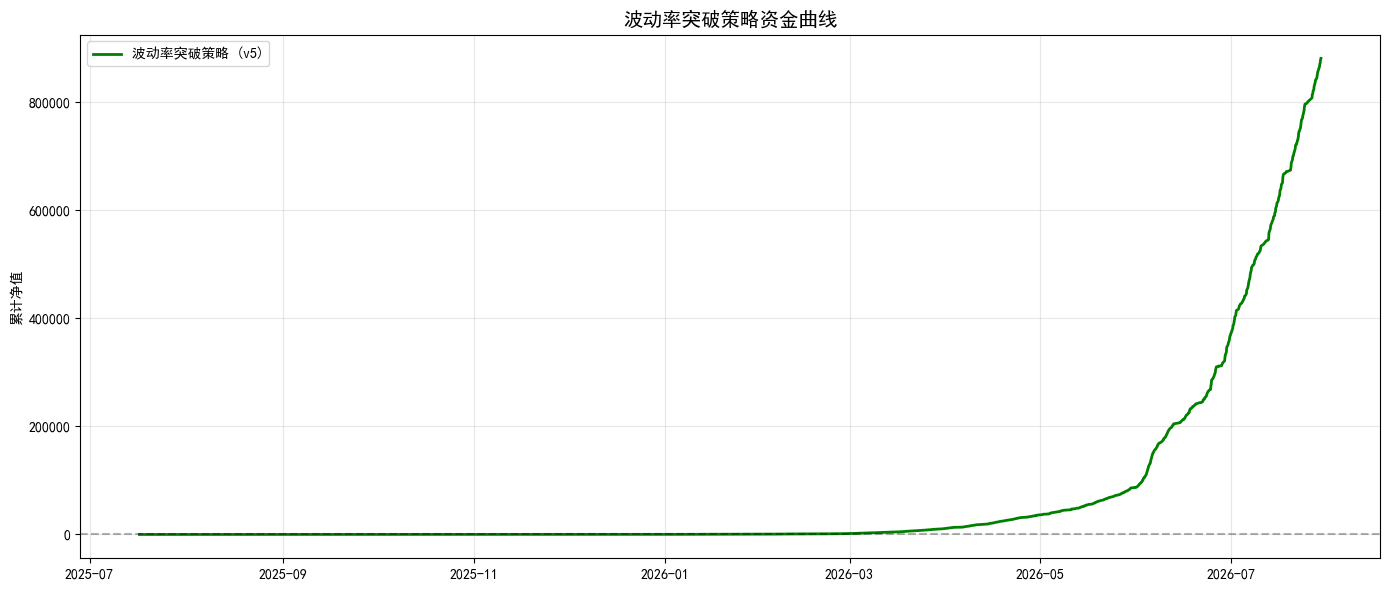

In [ ]:
#way3 转战日内

# ==========================================================
# 策略转向：波动率突破策略 (v5)
# 不预测方向，只预测"是否会突破"，价格实际先碰哪边就跟哪边
# ==========================================================

# ----------------------------------------------------------
# 第1步：把三分类标签转成二分类 (Flat=0 vs Breakout=1)
# ----------------------------------------------------------
# 复用之前已经打好的三分类标签 df_labeled_clean_v3 (含regime特征，16个月完整数据)
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei']  # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False    # 用来正常显示负号
df_breakout_v5 = df_labeled_clean_v3.copy()
df_breakout_v5['is_breakout_v5'] = (df_breakout_v5['label_v3'] != 1).astype(int)

print("二分类标签分布 (0=震荡, 1=突破):")
print(df_breakout_v5['is_breakout_v5'].value_counts())
print(f"突破占比: {df_breakout_v5['is_breakout_v5'].mean():.2%}")

# ----------------------------------------------------------
# 第2步：Walk-forward 训练二分类模型，判断"是否会突破"
# ----------------------------------------------------------
def walk_forward_breakout_v5(df, feature_cols, label_col='is_breakout_v5',
                               train_window_v5=96*90, test_window_v5=96*14, step_v5=96*14):
    n_v5 = len(df)
    all_probs_v5 = []
    
    for start_v5 in tqdm(range(0, n_v5 - train_window_v5 - test_window_v5, step_v5)):
        train_end_v5 = start_v5 + train_window_v5
        test_end_v5 = train_end_v5 + test_window_v5
        
        train_slice_v5 = df.iloc[start_v5:train_end_v5]
        test_slice_v5 = df.iloc[train_end_v5:test_end_v5]
        
        X_tr_v5 = train_slice_v5[feature_cols]
        y_tr_v5 = train_slice_v5[label_col]
        X_te_v5 = test_slice_v5[feature_cols]
        
        weights_v5 = compute_sample_weight(class_weight='balanced', y=y_tr_v5)
        
        model_v5 = xgb.XGBClassifier(
            objective='binary:logistic',
            max_depth=4, learning_rate=0.03, n_estimators=300,
            subsample=0.8, colsample_bytree=0.8, random_state=42
        )
        model_v5.fit(X_tr_v5, y_tr_v5, sample_weight=weights_v5, verbose=False)
        
        prob_breakout_v5 = model_v5.predict_proba(X_te_v5)[:, 1]
        
        window_result_v5 = pd.DataFrame({
            'prob_breakout_v5': prob_breakout_v5
        }, index=test_slice_v5.index)
        all_probs_v5.append(window_result_v5)
    
    return pd.concat(all_probs_v5)

feature_cols_v5 = [c for c in [
    'return_t-1', 'volume_change', 'rsi_14', 
    'garch_vol_zscore', 'delta_garch_vol', 'garch_var_oos', 
    'return_1H', 'rsi_1D',
    'trend_alignment', 'ema_60_slope', 'adx_14',
    'vol_percentile_30d', 'price_position_7d',
    'return_3d', 'return_7d'
] if c in df_breakout_v5.columns]

print(f"\n使用特征数: {len(feature_cols_v5)}")
print("\n开始 Walk-Forward 训练突破概率模型...")
breakout_probs_v5 = walk_forward_breakout_v5(df_breakout_v5, feature_cols_v5)

# ----------------------------------------------------------
# 第3步：日内突破回测逻辑
# 只有 prob_breakout 超过阈值的时刻才"挂单等待"
# 价格实际先碰哪边(上轨/下轨)，就跟哪个方向，直到horizon结束或触及对侧
# ----------------------------------------------------------
def backtest_breakout_strategy_v5(df, breakout_probs, horizon=12, 
                                    prob_threshold_v5=0.5, 
                                    upper_mult_v5=0.8, lower_mult_v5=0.8,
                                    fee_rate_v5=0.0005,
                                    target_risk_v5=0.01, max_leverage_v5=1.5):
    
    merged_v5 = df.loc[breakout_probs.index].copy()
    merged_v5['prob_breakout_v5'] = breakout_probs['prob_breakout_v5']
    
    close_arr_v5 = merged_v5['close'].values
    garch_var_arr_v5 = merged_v5['garch_var_oos'].abs().values
    prob_arr_v5 = merged_v5['prob_breakout_v5'].values
    index_arr_v5 = merged_v5.index
    n_v5 = len(merged_v5)
    
    trades_v5 = []
    i_v5 = 0
    
    while i_v5 < n_v5 - horizon:
        # 只有模型认为"很可能突破"时，才在这个时点"挂上下双边突破单"
        if prob_arr_v5[i_v5] > prob_threshold_v5:
            p0_v5 = close_arr_v5[i_v5]
            upper_barrier_v5 = p0_v5 * (1 + garch_var_arr_v5[i_v5] * upper_mult_v5)
            lower_barrier_v5 = p0_v5 * (1 - garch_var_arr_v5[i_v5] * lower_mult_v5)
            path_v5 = close_arr_v5[i_v5+1 : i_v5+1+horizon]
            
            hit_upper_v5 = np.where(path_v5 >= upper_barrier_v5)[0]
            hit_lower_v5 = np.where(path_v5 <= lower_barrier_v5)[0]
            idx_upper_v5 = hit_upper_v5[0] if len(hit_upper_v5) > 0 else np.inf
            idx_lower_v5 = hit_lower_v5[0] if len(hit_lower_v5) > 0 else np.inf
            
            position_size_v5 = min(target_risk_v5 / garch_var_arr_v5[i_v5], max_leverage_v5)
            
            if idx_upper_v5 < idx_lower_v5:
                # 价格先突破上轨 -> 跟多，赚的是"突破幅度"，这里简化为屏障宽度
                direction_v5 = 1
                exit_idx_v5 = i_v5 + 1 + int(idx_upper_v5)
                pnl_v5 = garch_var_arr_v5[i_v5] * upper_mult_v5 * position_size_v5
            elif idx_lower_v5 < idx_upper_v5:
                direction_v5 = -1
                exit_idx_v5 = i_v5 + 1 + int(idx_lower_v5)
                pnl_v5 = garch_var_arr_v5[i_v5] * lower_mult_v5 * position_size_v5
            else:
                # 两边都没触碰(超时) -> 没有突破发生，不产生交易，不扣钱不赚钱
                i_v5 += 1
                continue
            
            fee_v5 = position_size_v5 * fee_rate_v5 * 2
            trades_v5.append({
                'entry_time': index_arr_v5[i_v5],
                'exit_time': index_arr_v5[exit_idx_v5],
                'direction': direction_v5,
                'position_size': position_size_v5,
                'pnl': pnl_v5,
                'fee': fee_v5,
                'net_pnl': pnl_v5 - fee_v5
            })
            i_v5 = exit_idx_v5 + 1  # 交易结束后才能开下一笔
        else:
            i_v5 += 1
    
    return pd.DataFrame(trades_v5)

print("\n开始回测突破策略...")
trades_df_v5 = backtest_breakout_strategy_v5(
    df_breakout_v5, breakout_probs_v5, 
    horizon=horizon_v3, prob_threshold_v5=0.5,
    upper_mult_v5=upper_mult_v4 if 'upper_mult_v4' in dir() else 0.8,
    lower_mult_v5=lower_mult_v4 if 'lower_mult_v4' in dir() else 0.8
)

print(f"\n总交易笔数: {len(trades_df_v5)}")
print(f"胜率: {(trades_df_v5['net_pnl'] > 0).mean():.2%}")
print(f"平均每笔净收益: {trades_df_v5['net_pnl'].mean():.4%}")
win_avg_v5 = trades_df_v5[trades_df_v5.net_pnl > 0]['net_pnl'].mean()
loss_avg_v5 = abs(trades_df_v5[trades_df_v5.net_pnl < 0]['net_pnl'].mean()) if (trades_df_v5.net_pnl < 0).any() else np.nan
print(f"盈亏比: {win_avg_v5 / loss_avg_v5:.2f}" if not np.isnan(loss_avg_v5) else "无亏损交易")

trades_df_v5 = trades_df_v5.sort_values('entry_time').reset_index(drop=True)
trades_df_v5['cum_net_value'] = (1 + trades_df_v5['net_pnl']).cumprod()
print(f"最终累计净值: {trades_df_v5['cum_net_value'].iloc[-1]:.4f}")

plt.figure(figsize=(14, 6))
plt.plot(trades_df_v5['entry_time'], trades_df_v5['cum_net_value'], 
         color='green', linewidth=2, label='波动率突破策略 (v5)')
plt.axhline(1.0, color='black', linestyle='--', alpha=0.3)
plt.title('波动率突破策略资金曲线', fontsize=14)
plt.ylabel('累计净值')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


开始运行修复后的真实突破回测...

总交易笔数: 2004
胜率: 42.76%
平均每笔净收益: 0.0091%
盈亏比: 1.38
最终累计净值: 1.1001


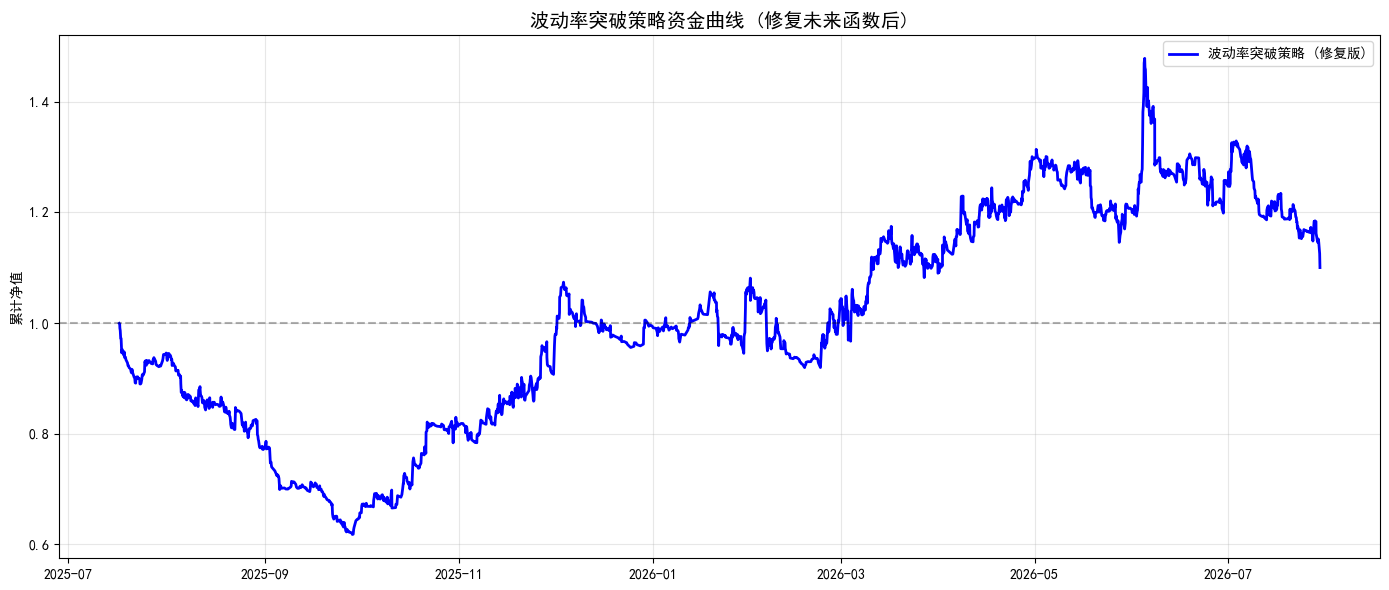

In [ ]:
#唉，未来函数了，白高兴了

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 解决 Matplotlib 中文显示乱码问题
plt.rcParams['font.sans-serif'] = ['SimHei']  # Windows 请用 'SimHei'，Mac 用户请改为 'Arial Unicode MS'
plt.rcParams['axes.unicode_minus'] = False    # 用来正常显示负号

# ----------------------------------------------------------
# 修复未来函数的回测逻辑：真实挂单、真实入场、持仓到期
# ----------------------------------------------------------
def backtest_breakout_strategy_v5_fixed(df, breakout_probs, horizon=12, 
                                        prob_threshold_v5=0.5, 
                                        upper_mult_v5=0.8, lower_mult_v5=0.8,
                                        fee_rate_v5=0.0005,
                                        target_risk_v5=0.01, max_leverage_v5=1.5):
    
    merged_v5 = df.loc[breakout_probs.index].copy()
    merged_v5['prob_breakout_v5'] = breakout_probs['prob_breakout_v5']
    
    close_arr_v5 = merged_v5['close'].values
    garch_var_arr_v5 = merged_v5['garch_var_oos'].abs().values
    prob_arr_v5 = merged_v5['prob_breakout_v5'].values
    index_arr_v5 = merged_v5.index
    n_v5 = len(merged_v5)
    
    trades_v5 = []
    i_v5 = 0
    
    while i_v5 < n_v5 - horizon:
        # 只有模型认为"很可能突破"时，才在这个时点"挂上下双边突破单"
        if prob_arr_v5[i_v5] > prob_threshold_v5:
            p0_v5 = close_arr_v5[i_v5]
            upper_barrier_v5 = p0_v5 * (1 + garch_var_arr_v5[i_v5] * upper_mult_v5)
            lower_barrier_v5 = p0_v5 * (1 - garch_var_arr_v5[i_v5] * lower_mult_v5)
            
            # 截取未来 horizon 个周期的价格路径
            path_v5 = close_arr_v5[i_v5+1 : i_v5+1+horizon]
            
            # 判断在未来路径中，是否触碰了上下轨
            hit_upper_v5 = np.where(path_v5 >= upper_barrier_v5)[0]
            hit_lower_v5 = np.where(path_v5 <= lower_barrier_v5)[0]
            
            idx_upper_v5 = hit_upper_v5[0] if len(hit_upper_v5) > 0 else np.inf
            idx_lower_v5 = hit_lower_v5[0] if len(hit_lower_v5) > 0 else np.inf
            
            # 仓位计算保持不变
            position_size_v5 = min(target_risk_v5 / garch_var_arr_v5[i_v5], max_leverage_v5)
            
            if idx_upper_v5 < idx_lower_v5:
                # 价格先突破上轨 -> 触发多单挂单
                direction_v5 = 1
                entry_idx_v5 = i_v5 + 1 + int(idx_upper_v5)
                entry_price_v5 = upper_barrier_v5  # 【修复核心1】入场价是上轨价格，而不是 p0！
                
            elif idx_lower_v5 < idx_upper_v5:
                # 价格先突破下轨 -> 触发空单挂单
                direction_v5 = -1
                entry_idx_v5 = i_v5 + 1 + int(idx_lower_v5)
                entry_price_v5 = lower_barrier_v5  # 【修复核心1】入场价是下轨价格，而不是 p0！
                
            else:
                # 两边都没触碰(在 horizon 内震荡) -> 挂单失效，没有交易发生
                i_v5 += 1
                continue
            
            # 【修复核心2】持有到 horizon 结束，以当时的收盘价平仓
            exit_idx_v5 = i_v5 + horizon
            exit_price_v5 = close_arr_v5[exit_idx_v5]
            
            # 计算无杠杆的纯价格涨跌幅
            if direction_v5 == 1:
                raw_return_v5 = (exit_price_v5 - entry_price_v5) / entry_price_v5
            else:
                raw_return_v5 = (entry_price_v5 - exit_price_v5) / entry_price_v5
                
            # 乘上仓位得出本次交易的总盈亏比例
            pnl_v5 = raw_return_v5 * position_size_v5
            
            # 双边手续费
            fee_v5 = position_size_v5 * fee_rate_v5 * 2
            
            trades_v5.append({
                'signal_time': index_arr_v5[i_v5],       # 信号发出的时间
                'entry_time': index_arr_v5[entry_idx_v5],  # 真实触价成交的时间
                'exit_time': index_arr_v5[exit_idx_v5],    # horizon结束，平仓时间
                'direction': direction_v5,
                'entry_price': entry_price_v5,
                'exit_price': exit_price_v5,
                'position_size': position_size_v5,
                'pnl': pnl_v5,
                'fee': fee_v5,
                'net_pnl': pnl_v5 - fee_v5
            })
            
            # 交易结束后，从平仓点重新开始寻找机会，避免持仓期间重复发信号
            i_v5 = exit_idx_v5 
        else:
            i_v5 += 1
    
    return pd.DataFrame(trades_v5)

# --- 运行修复后的回测 ---
print("\n开始运行修复后的真实突破回测...")
trades_df_v5_fixed = backtest_breakout_strategy_v5_fixed(
    df_breakout_v5, breakout_probs_v5, 
    horizon=horizon_v3, prob_threshold_v5=0.5,
    upper_mult_v5=upper_mult_v4 if 'upper_mult_v4' in dir() else 0.8,
    lower_mult_v5=lower_mult_v4 if 'lower_mult_v4' in dir() else 0.8
)

if len(trades_df_v5_fixed) > 0:
    print(f"\n总交易笔数: {len(trades_df_v5_fixed)}")
    print(f"胜率: {(trades_df_v5_fixed['net_pnl'] > 0).mean():.2%}")
    print(f"平均每笔净收益: {trades_df_v5_fixed['net_pnl'].mean():.4%}")
    
    win_avg_v5 = trades_df_v5_fixed[trades_df_v5_fixed.net_pnl > 0]['net_pnl'].mean()
    loss_avg_v5 = abs(trades_df_v5_fixed[trades_df_v5_fixed.net_pnl < 0]['net_pnl'].mean()) if (trades_df_v5_fixed.net_pnl < 0).any() else np.nan
    print(f"盈亏比: {win_avg_v5 / loss_avg_v5:.2f}" if not np.isnan(loss_avg_v5) else "无亏损交易")

    # 计算资金曲线
    trades_df_v5_fixed = trades_df_v5_fixed.sort_values('entry_time').reset_index(drop=True)
    trades_df_v5_fixed['cum_net_value'] = (1 + trades_df_v5_fixed['net_pnl']).cumprod()
    print(f"最终累计净值: {trades_df_v5_fixed['cum_net_value'].iloc[-1]:.4f}")

    # 绘图
    plt.figure(figsize=(14, 6))
    plt.plot(trades_df_v5_fixed['entry_time'], trades_df_v5_fixed['cum_net_value'], 
             color='blue', linewidth=2, label='波动率突破策略 (修复版)')
    plt.axhline(1.0, color='black', linestyle='--', alpha=0.3)
    plt.title('波动率突破策略资金曲线 (修复未来函数后)', fontsize=14)
    plt.ylabel('累计净值')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("在当前参数下，没有产生任何交易。")

In [ ]:
#现在存在假突破了，怎么处理呢？
#1.加入动态止盈
#2.大级别趋势过滤
#3.机器学习阈值

In [ ]:
thresholds_to_test = [0.5, 0.55, 0.6, 0.65, 0.7]
results_summary = []

for th in thresholds_to_test:
    # 调用我们修复好未来函数的 backtest 函数
    temp_trades = backtest_breakout_strategy_v5_fixed(
        df_breakout_v5, breakout_probs_v5, 
        horizon=12, prob_threshold_v5=th
    )
    
    if len(temp_trades) > 0:
        win_rate = (temp_trades['net_pnl'] > 0).mean()
        avg_net_pnl = temp_trades['net_pnl'].mean()
        
        wins = temp_trades[temp_trades.net_pnl > 0]['net_pnl'].mean()
        losses = abs(temp_trades[temp_trades.net_pnl < 0]['net_pnl'].mean())
        pl_ratio = wins / losses if losses != 0 else np.nan
        
        final_equity = (1 + temp_trades['net_pnl']).cumprod().iloc[-1]
        
        results_summary.append({
            'Threshold': th,
            'Trades': len(temp_trades),
            'Win Rate': f"{win_rate:.2%}",
            'Avg Net PnL': f"{avg_net_pnl:.4%}",
            'P/L Ratio': round(pl_ratio, 2),
            'Final Equity': round(final_equity, 4)
        })

summary_df = pd.DataFrame(results_summary)
print(summary_df)

   Threshold  Trades Win Rate Avg Net PnL  P/L Ratio  Final Equity
0       0.50    1870   44.39%     0.0502%       1.48        2.3582
1       0.55    1732   46.02%     0.0502%       1.38        2.2067
2       0.60    1544   46.11%     0.0528%       1.38        2.0891
3       0.65    1343   46.39%     0.0537%       1.36        1.9124
4       0.70    1117   46.37%     0.0496%       1.34        1.6289


In [ ]:
#确定了0.6-0.65比较合适，加入动态止盈止损。
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def backtest_breakout_strategy_v5_tpsl(df, breakout_probs, horizon=12, 
                                        prob_threshold_v5=0.6, 
                                        upper_mult_v5=0.8, lower_mult_v5=0.8,
                                        tp_mult_v5=1.5, sl_mult_v5=1.0,  # 新增止盈止损乘数
                                        fee_rate_v5=0.0005,
                                        target_risk_v5=0.01, max_leverage_v5=1.5):
    
    merged_v5 = df.loc[breakout_probs.index].copy()
    merged_v5['prob_breakout_v5'] = breakout_probs['prob_breakout_v5']
    
    close_arr_v5 = merged_v5['close'].values
    garch_var_arr_v5 = merged_v5['garch_var_oos'].abs().values
    prob_arr_v5 = merged_v5['prob_breakout_v5'].values
    index_arr_v5 = merged_v5.index
    n_v5 = len(merged_v5)
    
    trades_v5 = []
    i_v5 = 0
    
    while i_v5 < n_v5 - horizon:
        if prob_arr_v5[i_v5] > prob_threshold_v5:
            p0_v5 = close_arr_v5[i_v5]
            current_vol = garch_var_arr_v5[i_v5]
            
            upper_barrier_v5 = p0_v5 * (1 + current_vol * upper_mult_v5)
            lower_barrier_v5 = p0_v5 * (1 - current_vol * lower_mult_v5)
            
            path_v5 = close_arr_v5[i_v5+1 : i_v5+1+horizon]
            
            hit_upper_v5 = np.where(path_v5 >= upper_barrier_v5)[0]
            hit_lower_v5 = np.where(path_v5 <= lower_barrier_v5)[0]
            
            idx_upper_v5 = hit_upper_v5[0] if len(hit_upper_v5) > 0 else np.inf
            idx_lower_v5 = hit_lower_v5[0] if len(hit_lower_v5) > 0 else np.inf
            
            position_size_v5 = min(target_risk_v5 / current_vol, max_leverage_v5)
            
            # --- 确定入场 ---
            if idx_upper_v5 < idx_lower_v5:
                direction_v5 = 1
                entry_idx_v5 = i_v5 + 1 + int(idx_upper_v5)
                entry_price_v5 = upper_barrier_v5 
                # 计算多单的止盈止损线
                tp_price = entry_price_v5 * (1 + current_vol * tp_mult_v5)
                sl_price = entry_price_v5 * (1 - current_vol * sl_mult_v5)
                
            elif idx_lower_v5 < idx_upper_v5:
                direction_v5 = -1
                entry_idx_v5 = i_v5 + 1 + int(idx_lower_v5)
                entry_price_v5 = lower_barrier_v5 
                # 计算空单的止盈止损线
                tp_price = entry_price_v5 * (1 - current_vol * tp_mult_v5)
                sl_price = entry_price_v5 * (1 + current_vol * sl_mult_v5)
                
            else:
                i_v5 += 1
                continue
            
            # --- 入场后：逐K线扫描，检查是否触发止盈止损 ---
            exit_idx_v5 = i_v5 + horizon  # 默认持仓到 horizon 结束 (时间止损)
            exit_price_v5 = close_arr_v5[exit_idx_v5]
            exit_reason = "Time Stop"
            
            for j in range(entry_idx_v5 + 1, i_v5 + horizon + 1):
                if j >= n_v5: break
                current_p = close_arr_v5[j]
                
                if direction_v5 == 1: # 多头判断
                    if current_p >= tp_price:
                        exit_idx_v5 = j
                        exit_price_v5 = tp_price # 触碰限价止盈
                        exit_reason = "Take Profit"
                        break
                    elif current_p <= sl_price:
                        exit_idx_v5 = j
                        exit_price_v5 = sl_price # 触碰市价止损
                        exit_reason = "Stop Loss"
                        break
                else: # 空头判断
                    if current_p <= tp_price:
                        exit_idx_v5 = j
                        exit_price_v5 = tp_price
                        exit_reason = "Take Profit"
                        break
                    elif current_p >= sl_price:
                        exit_idx_v5 = j
                        exit_price_v5 = sl_price
                        exit_reason = "Stop Loss"
                        break
            
            # --- 结算 ---
            if direction_v5 == 1:
                raw_return_v5 = (exit_price_v5 - entry_price_v5) / entry_price_v5
            else:
                raw_return_v5 = (entry_price_v5 - exit_price_v5) / entry_price_v5
                
            pnl_v5 = raw_return_v5 * position_size_v5
            fee_v5 = position_size_v5 * fee_rate_v5 * 2
            
            trades_v5.append({
                'entry_time': index_arr_v5[entry_idx_v5],
                'exit_time': index_arr_v5[exit_idx_v5],
                'direction': direction_v5,
                'exit_reason': exit_reason,
                'hold_duration': exit_idx_v5 - entry_idx_v5, # 统计实际持仓K线数
                'pnl': pnl_v5,
                'fee': fee_v5,
                'net_pnl': pnl_v5 - fee_v5
            })
            
            # 资金释放：提前平仓后，可以直接从平仓点寻找下一次交易，提高资金利用率
            i_v5 = exit_idx_v5 
        else:
            i_v5 += 1
    
    return pd.DataFrame(trades_v5)

In [ ]:
# 测试不同的盈亏比配置，固定概率阈值为 0.60
tp_sl_configs = [
    (1.0, 1.0),   # 盈亏比 1:1 (胜率容易过50%)
    (1.5, 1.0),   # 盈亏比 1.5:1 (经典配置)
    (2.0, 1.0),   # 盈亏比 2:1 (吃大波段，胜率可能降低)
    (1.5, 0.8),   # 宽止盈，紧止损
]

results_tpsl = []

for tp, sl in tp_sl_configs:
    temp_trades = backtest_breakout_strategy_v5_tpsl(
        df_breakout_v5, breakout_probs_v5, 
        horizon=12, prob_threshold_v5=0.6, 
        tp_mult_v5=tp, sl_mult_v5=sl
    )
    
    if len(temp_trades) > 0:
        win_rate = (temp_trades['net_pnl'] > 0).mean()
        avg_net_pnl = temp_trades['net_pnl'].mean()
        avg_hold = temp_trades['hold_duration'].mean()
        final_equity = (1 + temp_trades['net_pnl']).cumprod().iloc[-1]
        
        # 统计离场原因分布
        tp_count = (temp_trades['exit_reason'] == 'Take Profit').sum()
        sl_count = (temp_trades['exit_reason'] == 'Stop Loss').sum()
        time_count = (temp_trades['exit_reason'] == 'Time Stop').sum()
        
        results_tpsl.append({
            'TP:SL': f"{tp}:{sl}",
            'Trades': len(temp_trades),
            'Win Rate': f"{win_rate:.2%}",
            'Avg Net PnL': f"{avg_net_pnl:.4%}",
            'Avg Hold (bars)': round(avg_hold, 1),
            'TP Hits': tp_count,
            'SL Hits': sl_count,
            'Time Exits': time_count,
            'Final Equity': round(final_equity, 4)
        })

print(pd.DataFrame(results_tpsl))

     TP:SL  Trades Win Rate Avg Net PnL  Avg Hold (bars)  TP Hits  SL Hits  \
0  1.0:1.0    1813   47.27%    -0.0216%              4.4      504      242   
1  1.5:1.0    1705   45.81%     0.0311%              4.9      296      222   
2  2.0:1.0    1665   45.47%     0.0597%              5.1      184      217   
3  1.5:0.8    1737   45.48%     0.0384%              4.6      299      315   

   Time Exits  Final Equity  
0        1067        0.6557  
1        1187        1.6339  
2        1264        2.5833  
3        1123        1.8777  


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def backtest_breakout_strategy_v5_trailing(df, breakout_probs, horizon=12, 
                                           prob_threshold_v5=0.6, 
                                           upper_mult_v5=0.8, lower_mult_v5=0.8,
                                           tp_mult_v5=3.0,     # 放宽固定止盈，主要靠追踪止损平仓
                                           trail_mult_v5=1.0,  # 追踪止损的回撤容忍距离 (比如从最高点回撤1倍波动率就平仓)
                                           fee_rate_v5=0.0005,
                                           target_risk_v5=0.01, max_leverage_v5=1.5):
    
    merged_v5 = df.loc[breakout_probs.index].copy()
    merged_v5['prob_breakout_v5'] = breakout_probs['prob_breakout_v5']
    
    close_arr_v5 = merged_v5['close'].values
    garch_var_arr_v5 = merged_v5['garch_var_oos'].abs().values
    prob_arr_v5 = merged_v5['prob_breakout_v5'].values
    index_arr_v5 = merged_v5.index
    n_v5 = len(merged_v5)
    
    trades_v5 = []
    i_v5 = 0
    
    while i_v5 < n_v5 - horizon:
        if prob_arr_v5[i_v5] > prob_threshold_v5:
            p0_v5 = close_arr_v5[i_v5]
            current_vol = garch_var_arr_v5[i_v5]
            
            upper_barrier_v5 = p0_v5 * (1 + current_vol * upper_mult_v5)
            lower_barrier_v5 = p0_v5 * (1 - current_vol * lower_mult_v5)
            
            path_v5 = close_arr_v5[i_v5+1 : i_v5+1+horizon]
            
            hit_upper_v5 = np.where(path_v5 >= upper_barrier_v5)[0]
            hit_lower_v5 = np.where(path_v5 <= lower_barrier_v5)[0]
            
            idx_upper_v5 = hit_upper_v5[0] if len(hit_upper_v5) > 0 else np.inf
            idx_lower_v5 = hit_lower_v5[0] if len(hit_lower_v5) > 0 else np.inf
            
            position_size_v5 = min(target_risk_v5 / current_vol, max_leverage_v5)
            
            # --- 确定入场 ---
            if idx_upper_v5 < idx_lower_v5:
                direction_v5 = 1
                entry_idx_v5 = i_v5 + 1 + int(idx_upper_v5)
                entry_price_v5 = upper_barrier_v5 
                
                tp_price = entry_price_v5 * (1 + current_vol * tp_mult_v5)
                initial_sl = entry_price_v5 * (1 - current_vol * trail_mult_v5)
                
                # 初始化追踪变量
                highest_seen = entry_price_v5
                current_sl = initial_sl
                
            elif idx_lower_v5 < idx_upper_v5:
                direction_v5 = -1
                entry_idx_v5 = i_v5 + 1 + int(idx_lower_v5)
                entry_price_v5 = lower_barrier_v5 
                
                tp_price = entry_price_v5 * (1 - current_vol * tp_mult_v5)
                initial_sl = entry_price_v5 * (1 + current_vol * trail_mult_v5)
                
                # 初始化追踪变量
                lowest_seen = entry_price_v5
                current_sl = initial_sl
                
            else:
                i_v5 += 1
                continue
            
            # --- 追踪止损逐 K 线扫描 ---
            exit_idx_v5 = i_v5 + horizon
            exit_price_v5 = close_arr_v5[exit_idx_v5]
            exit_reason = "Time Stop"
            
            for j in range(entry_idx_v5 + 1, i_v5 + horizon + 1):
                if j >= n_v5: break
                current_p = close_arr_v5[j]
                
                if direction_v5 == 1: # 多头逻辑
                    # 更新最高价和追踪止损线
                    if current_p > highest_seen:
                        highest_seen = current_p
                        # 止损线上移，但绝不下降
                        current_sl = max(current_sl, highest_seen * (1 - current_vol * trail_mult_v5))
                    
                    if current_p >= tp_price:
                        exit_idx_v5 = j
                        exit_price_v5 = tp_price
                        exit_reason = "Take Profit (Max)"
                        break
                    elif current_p <= current_sl:
                        exit_idx_v5 = j
                        exit_price_v5 = current_sl  # 触碰追踪止损线离场
                        exit_reason = "Trailing Stop"
                        break
                        
                else: # 空头逻辑
                    # 更新最低价和追踪止损线
                    if current_p < lowest_seen:
                        lowest_seen = current_p
                        # 止损线下移，但绝不上升
                        current_sl = min(current_sl, lowest_seen * (1 + current_vol * trail_mult_v5))
                        
                    if current_p <= tp_price:
                        exit_idx_v5 = j
                        exit_price_v5 = tp_price
                        exit_reason = "Take Profit (Max)"
                        break
                    elif current_p >= current_sl:
                        exit_idx_v5 = j
                        exit_price_v5 = current_sl
                        exit_reason = "Trailing Stop"
                        break
            
            # --- 结算 ---
            if direction_v5 == 1:
                raw_return_v5 = (exit_price_v5 - entry_price_v5) / entry_price_v5
            else:
                raw_return_v5 = (entry_price_v5 - exit_price_v5) / entry_price_v5
                
            pnl_v5 = raw_return_v5 * position_size_v5
            fee_v5 = position_size_v5 * fee_rate_v5 * 2
            
            trades_v5.append({
                'entry_time': index_arr_v5[entry_idx_v5],
                'exit_time': index_arr_v5[exit_idx_v5],
                'direction': direction_v5,
                'exit_reason': exit_reason,
                'hold_duration': exit_idx_v5 - entry_idx_v5,
                'pnl': pnl_v5,
                'fee': fee_v5,
                'net_pnl': pnl_v5 - fee_v5
            })
            
            i_v5 = exit_idx_v5 
        else:
            i_v5 += 1
    
    return pd.DataFrame(trades_v5)

In [ ]:
# 测试不同的追踪止损配置，阈值保持 0.60
trailing_configs = [
    (2.0, 1.0),   # 之前表现最好的 2:1，但把 1.0 变成追踪距离
    (3.0, 1.2),   # 给震荡多留一点空间 (1.2倍回撤)，目标更远
    (4.0, 1.5),   # 极宽目标，专吃大级别趋势，容忍较大回撤
]

results_trailing = []

for tp_m, trail_m in trailing_configs:
    temp_trades = backtest_breakout_strategy_v5_trailing(
        df_breakout_v5, breakout_probs_v5, 
        horizon=12, prob_threshold_v5=0.6, 
        tp_mult_v5=tp_m, trail_mult_v5=trail_m
    )
    
    if len(temp_trades) > 0:
        win_rate = (temp_trades['net_pnl'] > 0).mean()
        avg_net_pnl = temp_trades['net_pnl'].mean()
        avg_hold = temp_trades['hold_duration'].mean()
        final_equity = (1 + temp_trades['net_pnl']).cumprod().iloc[-1]
        
        trail_hits = (temp_trades['exit_reason'] == 'Trailing Stop').sum()
        tp_hits = (temp_trades['exit_reason'] == 'Take Profit (Max)').sum()
        time_count = (temp_trades['exit_reason'] == 'Time Stop').sum()
        
        results_trailing.append({
            'TP / Trail': f"{tp_m} / {trail_m}",
            'Trades': len(temp_trades),
            'Win Rate': f"{win_rate:.2%}",
            'Avg PnL': f"{avg_net_pnl:.4%}",
            'Hold': round(avg_hold, 1),
            'Trail Exits': trail_hits,
            'Time Exits': time_count,
            'Equity': round(final_equity, 4)
        })

print(pd.DataFrame(results_trailing))

  TP / Trail  Trades Win Rate  Avg PnL  Hold  Trail Exits  Time Exits  Equity
0  2.0 / 1.0    1722   45.47%  0.0712%   4.8          403        1132  3.2619
1  3.0 / 1.2    1651   46.21%  0.1006%   5.3          299        1275  4.9877
2  4.0 / 1.5    1607   45.92%  0.0816%   5.6          192        1384  3.4989


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def backtest_breakout_strategy_v5_unlimited(df, breakout_probs, 
                                            signal_window=12,  
                                            max_hold=96,       
                                            prob_threshold_v5=0.6, 
                                            upper_mult_v5=0.8, lower_mult_v5=0.8,
                                            tp_mult_v5=3.0,     
                                            trail_mult_v5=1.2,  
                                            fee_rate_v5=0.0005,
                                            target_risk_v5=0.01, max_leverage_v5=1.5):
    
    merged_v5 = df.loc[breakout_probs.index].copy()
    merged_v5['prob_breakout_v5'] = breakout_probs['prob_breakout_v5']
    
    close_arr_v5 = merged_v5['close'].values
    garch_var_arr_v5 = merged_v5['garch_var_oos'].abs().values
    prob_arr_v5 = merged_v5['prob_breakout_v5'].values
    index_arr_v5 = merged_v5.index
    n_v5 = len(merged_v5)
    
    trades_v5 = []
    i_v5 = 0
    
    # 【修复1】安全垫需要容纳 "信号等待期" + "最大持仓期"
    while i_v5 < n_v5 - signal_window - max_hold - 1:
        if prob_arr_v5[i_v5] > prob_threshold_v5:
            p0_v5 = close_arr_v5[i_v5]
            current_vol = garch_var_arr_v5[i_v5]
            
            upper_barrier_v5 = p0_v5 * (1 + current_vol * upper_mult_v5)
            lower_barrier_v5 = p0_v5 * (1 - current_vol * lower_mult_v5)
            
            path_v5 = close_arr_v5[i_v5+1 : i_v5+1+signal_window]
            
            hit_upper_v5 = np.where(path_v5 >= upper_barrier_v5)[0]
            hit_lower_v5 = np.where(path_v5 <= lower_barrier_v5)[0]
            
            idx_upper_v5 = hit_upper_v5[0] if len(hit_upper_v5) > 0 else np.inf
            idx_lower_v5 = hit_lower_v5[0] if len(hit_lower_v5) > 0 else np.inf
            
            position_size_v5 = min(target_risk_v5 / current_vol, max_leverage_v5)
            
            if idx_upper_v5 < idx_lower_v5:
                direction_v5 = 1
                entry_idx_v5 = i_v5 + 1 + int(idx_upper_v5)
                entry_price_v5 = upper_barrier_v5 
                
                tp_price = entry_price_v5 * (1 + current_vol * tp_mult_v5)
                initial_sl = entry_price_v5 * (1 - current_vol * trail_mult_v5)
                highest_seen = entry_price_v5
                current_sl = initial_sl
                
            elif idx_lower_v5 < idx_upper_v5:
                direction_v5 = -1
                entry_idx_v5 = i_v5 + 1 + int(idx_lower_v5)
                entry_price_v5 = lower_barrier_v5 
                
                tp_price = entry_price_v5 * (1 - current_vol * tp_mult_v5)
                initial_sl = entry_price_v5 * (1 + current_vol * trail_mult_v5)
                lowest_seen = entry_price_v5
                current_sl = initial_sl
                
            else:
                i_v5 += 1
                continue
            
            # 【修复2】加上双重保险，强制限制越界
            exit_idx_v5 = min(entry_idx_v5 + max_hold, n_v5 - 1)
            exit_price_v5 = close_arr_v5[exit_idx_v5]
            exit_reason = "Max Hold Time limit"
            
            for j in range(entry_idx_v5 + 1, entry_idx_v5 + max_hold + 1):
                if j >= n_v5: break
                current_p = close_arr_v5[j]
                
                if direction_v5 == 1:
                    if current_p > highest_seen:
                        highest_seen = current_p
                        current_sl = max(current_sl, highest_seen * (1 - current_vol * trail_mult_v5))
                    
                    if current_p >= tp_price:
                        exit_idx_v5 = j
                        exit_price_v5 = tp_price
                        exit_reason = "Take Profit (Max)"
                        break
                    elif current_p <= current_sl:
                        exit_idx_v5 = j
                        exit_price_v5 = current_sl
                        exit_reason = "Trailing Stop"
                        break
                        
                else:
                    if current_p < lowest_seen:
                        lowest_seen = current_p
                        current_sl = min(current_sl, lowest_seen * (1 + current_vol * trail_mult_v5))
                        
                    if current_p <= tp_price:
                        exit_idx_v5 = j
                        exit_price_v5 = tp_price
                        exit_reason = "Take Profit (Max)"
                        break
                    elif current_p >= current_sl:
                        exit_idx_v5 = j
                        exit_price_v5 = current_sl
                        exit_reason = "Trailing Stop"
                        break
            
            if direction_v5 == 1:
                raw_return_v5 = (exit_price_v5 - entry_price_v5) / entry_price_v5
            else:
                raw_return_v5 = (entry_price_v5 - exit_price_v5) / entry_price_v5
                
            pnl_v5 = raw_return_v5 * position_size_v5
            fee_v5 = position_size_v5 * fee_rate_v5 * 2
            
            trades_v5.append({
                'entry_time': index_arr_v5[entry_idx_v5],
                'exit_time': index_arr_v5[exit_idx_v5],
                'direction': direction_v5,
                'exit_reason': exit_reason,
                'hold_duration': exit_idx_v5 - entry_idx_v5,
                'pnl': pnl_v5,
                'fee': fee_v5,
                'net_pnl': pnl_v5 - fee_v5
            })
            
            i_v5 = exit_idx_v5 
        else:
            i_v5 += 1
    
    return pd.DataFrame(trades_v5)

In [ ]:
hold_configs = [12, 24, 48, 96]
results_unlimited = []

for h in hold_configs:
    temp_trades = backtest_breakout_strategy_v5_unlimited(
        df_breakout_v5, breakout_probs_v5, 
        signal_window=12, max_hold=h,
        prob_threshold_v5=0.6, 
        tp_mult_v5=3.0, trail_mult_v5=1.2
    )
    
    if len(temp_trades) > 0:
        win_rate = (temp_trades['net_pnl'] > 0).mean()
        avg_net_pnl = temp_trades['net_pnl'].mean()
        avg_hold = temp_trades['hold_duration'].mean()
        final_equity = (1 + temp_trades['net_pnl']).cumprod().iloc[-1]
        
        trail_hits = (temp_trades['exit_reason'] == 'Trailing Stop').sum()
        tp_hits = (temp_trades['exit_reason'] == 'Take Profit (Max)').sum()
        time_count = (temp_trades['exit_reason'] == 'Max Hold Time limit').sum()
        
        results_unlimited.append({
            'Max Hold': h,
            'Trades': len(temp_trades),
            'Win Rate': f"{win_rate:.2%}",
            'Avg PnL': f"{avg_net_pnl:.4%}",
            'Hold': round(avg_hold, 1),
            'TP Hits': tp_hits,
            'Trail Exits': trail_hits,
            'Time Exits': time_count,
            'Equity': round(final_equity, 4)
        })

print(pd.DataFrame(results_unlimited))

   Max Hold  Trades Win Rate  Avg PnL  Hold  TP Hits  Trail Exits  Time Exits  \
0        12    1338   46.49%  0.1006%   9.8       93          486         759   
1        24    1140   46.32%  0.1287%  14.8      130          677         333   
2        48    1036   45.08%  0.1690%  18.8      160          764         112   
3        96     991   44.50%  0.1788%  21.0      179          796          16   

   Equity  
0  3.6102  
1  4.0616  
2  5.3695  
3  5.4789  


In [ ]:
hold_configs = [12, 24, 48, 96]
results_unlimited = []

for h in hold_configs:
    temp_trades = backtest_breakout_strategy_v5_unlimited(
        df_breakout_v5, breakout_probs_v5, 
        signal_window=12, max_hold=h,
        prob_threshold_v5=0.6, 
        tp_mult_v5=3.0, trail_mult_v5=1.2
    )
    
    if len(temp_trades) > 0:
        # 计算资金曲线
        temp_trades['cum_net_value'] = (1 + temp_trades['net_pnl']).cumprod()
        
        # --- 核心：计算最大回撤 (Max Drawdown) ---
        # 1. 计算每个时刻的历史最高净值 (Running Max)
        running_max = temp_trades['cum_net_value'].cummax()
        # 2. 计算当前净值距离历史最高点的回撤比例
        drawdown = (temp_trades['cum_net_value'] - running_max) / running_max
        # 3. 找出跌幅最深的那一次
        max_drawdown = drawdown.min()  
        
        win_rate = (temp_trades['net_pnl'] > 0).mean()
        avg_net_pnl = temp_trades['net_pnl'].mean()
        avg_hold = temp_trades['hold_duration'].mean()
        final_equity = temp_trades['cum_net_value'].iloc[-1]
        
        trail_hits = (temp_trades['exit_reason'] == 'Trailing Stop').sum()
        tp_hits = (temp_trades['exit_reason'] == 'Take Profit (Max)').sum()
        time_count = (temp_trades['exit_reason'] == 'Max Hold Time limit').sum()
        
        results_unlimited.append({
            'Max Hold': h,
            'Trades': len(temp_trades),
            'Win Rate': f"{win_rate:.2%}",
            'Avg PnL': f"{avg_net_pnl:.4%}",
            'Hold (bars)': round(avg_hold, 1),
            'TP Hits': tp_hits,
            'Trail Hits': trail_hits,
            'Time Exits': time_count,
            'MDD': f"{max_drawdown:.2%}",  # 新增：最大回撤
            'Equity': round(final_equity, 4)
        })

summary_df = pd.DataFrame(results_unlimited)
print(summary_df)

   Max Hold  Trades Win Rate  Avg PnL  Hold (bars)  TP Hits  Trail Hits  \
0        12    1338   46.49%  0.1006%          9.8       93         486   
1        24    1140   46.32%  0.1287%         14.8      130         677   
2        48    1036   45.08%  0.1690%         18.8      160         764   
3        96     991   44.50%  0.1788%         21.0      179         796   

   Time Exits      MDD  Equity  
0         759  -13.44%  3.6102  
1         333  -12.69%  4.0616  
2         112  -13.82%  5.3695  
3          16  -13.64%  5.4789  


In [ ]:
#试图加入大级别趋势，单好像是冲突的。
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def backtest_breakout_strategy_v5_trend(df, breakout_probs, 
                                        signal_window=12,  
                                        max_hold=48,       # 沿用我们找到的最优解 48
                                        prob_threshold_v5=0.6, 
                                        upper_mult_v5=0.8, lower_mult_v5=0.8,
                                        tp_mult_v5=3.0,     
                                        trail_mult_v5=1.2,  
                                        fee_rate_v5=0.0005,
                                        target_risk_v5=0.01, max_leverage_v5=1.5):
    
    merged_v5 = df.loc[breakout_probs.index].copy()
    merged_v5['prob_breakout_v5'] = breakout_probs['prob_breakout_v5']
    
    # 动态计算大级别趋势均线
    if 'ema_60' not in merged_v5.columns:
        merged_v5['ema_60'] = merged_v5['close'].ewm(span=60, adjust=False).mean()
    if 'ema_120' not in merged_v5.columns:
        merged_v5['ema_120'] = merged_v5['close'].ewm(span=120, adjust=False).mean()
        
    close_arr_v5 = merged_v5['close'].values
    garch_var_arr_v5 = merged_v5['garch_var_oos'].abs().values
    prob_arr_v5 = merged_v5['prob_breakout_v5'].values
    ema60_arr = merged_v5['ema_60'].values
    ema120_arr = merged_v5['ema_120'].values
    
    index_arr_v5 = merged_v5.index
    n_v5 = len(merged_v5)
    
    trades_v5 = []
    i_v5 = 0
    
    while i_v5 < n_v5 - signal_window - max_hold - 1:
        if prob_arr_v5[i_v5] > prob_threshold_v5:
            p0_v5 = close_arr_v5[i_v5]
            current_vol = garch_var_arr_v5[i_v5]
            
            # 判断当前的大级别趋势
            is_bullish = ema60_arr[i_v5] > ema120_arr[i_v5]
            is_bearish = ema60_arr[i_v5] < ema120_arr[i_v5]
            
            upper_barrier_v5 = p0_v5 * (1 + current_vol * upper_mult_v5)
            lower_barrier_v5 = p0_v5 * (1 - current_vol * lower_mult_v5)
            
            path_v5 = close_arr_v5[i_v5+1 : i_v5+1+signal_window]
            
            hit_upper_v5 = np.where(path_v5 >= upper_barrier_v5)[0]
            hit_lower_v5 = np.where(path_v5 <= lower_barrier_v5)[0]
            
            idx_upper_v5 = hit_upper_v5[0] if len(hit_upper_v5) > 0 else np.inf
            idx_lower_v5 = hit_lower_v5[0] if len(hit_lower_v5) > 0 else np.inf
            
            position_size_v5 = min(target_risk_v5 / current_vol, max_leverage_v5)
            
            # --- 引入趋势过滤判断 ---
            if idx_upper_v5 < idx_lower_v5:
                # 如果向上突破，但大趋势不是多头，则放弃该交易
                if not is_bullish:
                    i_v5 += 1
                    continue
                    
                direction_v5 = 1
                entry_idx_v5 = i_v5 + 1 + int(idx_upper_v5)
                entry_price_v5 = upper_barrier_v5 
                
                tp_price = entry_price_v5 * (1 + current_vol * tp_mult_v5)
                initial_sl = entry_price_v5 * (1 - current_vol * trail_mult_v5)
                highest_seen = entry_price_v5
                current_sl = initial_sl
                
            elif idx_lower_v5 < idx_upper_v5:
                # 如果向下突破，但大趋势不是空头，则放弃该交易
                if not is_bearish:
                    i_v5 += 1
                    continue
                    
                direction_v5 = -1
                entry_idx_v5 = i_v5 + 1 + int(idx_lower_v5)
                entry_price_v5 = lower_barrier_v5 
                
                tp_price = entry_price_v5 * (1 - current_vol * tp_mult_v5)
                initial_sl = entry_price_v5 * (1 + current_vol * trail_mult_v5)
                lowest_seen = entry_price_v5
                current_sl = initial_sl
                
            else:
                i_v5 += 1
                continue
            
            exit_idx_v5 = min(entry_idx_v5 + max_hold, n_v5 - 1)
            exit_price_v5 = close_arr_v5[exit_idx_v5]
            exit_reason = "Max Hold Time limit"
            
            for j in range(entry_idx_v5 + 1, entry_idx_v5 + max_hold + 1):
                if j >= n_v5: break
                current_p = close_arr_v5[j]
                
                if direction_v5 == 1:
                    if current_p > highest_seen:
                        highest_seen = current_p
                        current_sl = max(current_sl, highest_seen * (1 - current_vol * trail_mult_v5))
                    
                    if current_p >= tp_price:
                        exit_idx_v5 = j
                        exit_price_v5 = tp_price
                        exit_reason = "Take Profit (Max)"
                        break
                    elif current_p <= current_sl:
                        exit_idx_v5 = j
                        exit_price_v5 = current_sl
                        exit_reason = "Trailing Stop"
                        break
                        
                else:
                    if current_p < lowest_seen:
                        lowest_seen = current_p
                        current_sl = min(current_sl, lowest_seen * (1 + current_vol * trail_mult_v5))
                        
                    if current_p <= tp_price:
                        exit_idx_v5 = j
                        exit_price_v5 = tp_price
                        exit_reason = "Take Profit (Max)"
                        break
                    elif current_p >= current_sl:
                        exit_idx_v5 = j
                        exit_price_v5 = current_sl
                        exit_reason = "Trailing Stop"
                        break
            
            if direction_v5 == 1:
                raw_return_v5 = (exit_price_v5 - entry_price_v5) / entry_price_v5
            else:
                raw_return_v5 = (entry_price_v5 - exit_price_v5) / entry_price_v5
                
            pnl_v5 = raw_return_v5 * position_size_v5
            fee_v5 = position_size_v5 * fee_rate_v5 * 2
            
            trades_v5.append({
                'entry_time': index_arr_v5[entry_idx_v5],
                'exit_time': index_arr_v5[exit_idx_v5],
                'direction': direction_v5,
                'exit_reason': exit_reason,
                'hold_duration': exit_idx_v5 - entry_idx_v5,
                'pnl': pnl_v5,
                'fee': fee_v5,
                'net_pnl': pnl_v5 - fee_v5
            })
            
            i_v5 = exit_idx_v5 
        else:
            i_v5 += 1
    
    return pd.DataFrame(trades_v5)

# --- 运行趋势过滤对比测试 ---
temp_trades_trend = backtest_breakout_strategy_v5_trend(
    df_breakout_v5, breakout_probs_v5, 
    signal_window=12, max_hold=48,
    prob_threshold_v5=0.6, 
    tp_mult_v5=3.0, trail_mult_v5=1.2
)

if len(temp_trades_trend) > 0:
    temp_trades_trend['cum_net_value'] = (1 + temp_trades_trend['net_pnl']).cumprod()
    running_max = temp_trades_trend['cum_net_value'].cummax()
    max_drawdown = ((temp_trades_trend['cum_net_value'] - running_max) / running_max).min()
    
    win_rate = (temp_trades_trend['net_pnl'] > 0).mean()
    avg_net_pnl = temp_trades_trend['net_pnl'].mean()
    final_equity = temp_trades_trend['cum_net_value'].iloc[-1]
    
    print("=== 加入 EMA 60/120 趋势过滤后的结果 ===")
    print(f"总交易笔数: {len(temp_trades_trend)} 笔 (预期会减少近一半)")
    print(f"胜率: {win_rate:.2%}")
    print(f"平均每笔净收益: {avg_net_pnl:.4%}")
    print(f"最大回撤 (MDD): {max_drawdown:.2%} (目标 < 10%)")
    print(f"最终累计净值: {final_equity:.4f}")

=== 加入 EMA 60/120 趋势过滤后的结果 ===
总交易笔数: 776 笔 (预期会减少近一半)
胜率: 39.95%
平均每笔净收益: 0.0851%
最大回撤 (MDD): -15.32% (目标 < 10%)
最终累计净值: 1.8376


In [ ]:
import numpy as np
import pandas as pd

class VolatilityBreakoutStrategy:
    def __init__(self, prob_threshold=0.6, max_hold=48, signal_window=12,
                 upper_mult=0.8, lower_mult=0.8, tp_mult=3.0, trail_mult=1.2,
                 fee_rate=0.0005, slippage_bps=0.0002): # 新增 2个基点的单边滑点
        
        # 策略核心参数
        self.prob_threshold = prob_threshold
        self.max_hold = max_hold
        self.signal_window = signal_window
        
        # 乘数参数
        self.upper_mult = upper_mult
        self.lower_mult = lower_mult
        self.tp_mult = tp_mult
        self.trail_mult = trail_mult
        
        # 交易摩擦成本
        self.fee_rate = fee_rate
        self.slippage = slippage_bps 
        
        # 风险管理
        self.target_risk = 0.01
        self.max_leverage = 1.5

    def calculate_actual_execution_price(self, theoretical_price, direction, is_entry):
        """
        计算包含滑点后的实际成交价。
        无论是进场还是出场，滑点永远对我们不利。
        """
        # direction: 1 (做多), -1 (做空)
        # 如果是进场买入(多头进场) 或 出场买入(空头平仓) -> 实际价格变高
        # 如果是进场卖出(空头进场) 或 出场卖出(多头平仓) -> 实际价格变低
        
        is_buying = (direction == 1 and is_entry) or (direction == -1 and not is_entry)
        
        if is_buying:
            return theoretical_price * (1 + self.slippage)
        else:
            return theoretical_price * (1 - self.slippage)

    def generate_signals(self, df):
        """
        此处将包含之前的 while 循环逻辑，但所有的价格计算都会调用
        self.calculate_actual_execution_price 来引入滑点。
        """
        # 框架预留：准备在此处填入我们之前确定的 V5 版本纯净逻辑
        pass

In [ ]:
import numpy as np
import pandas as pd

class VolatilityBreakoutStrategy:
    def __init__(self, prob_threshold=0.6, max_hold=48, signal_window=12,
                 upper_mult=0.8, lower_mult=0.8, tp_mult=3.0, trail_mult=1.2,
                 fee_rate=0.0005, slippage_bps=0.0002):
        
        # 策略核心参数
        self.prob_threshold = prob_threshold
        self.max_hold = max_hold
        self.signal_window = signal_window
        
        # 乘数参数
        self.upper_mult = upper_mult
        self.lower_mult = lower_mult
        self.tp_mult = tp_mult
        self.trail_mult = trail_mult
        
        # 交易摩擦成本
        self.fee_rate = fee_rate
        self.slippage = slippage_bps 
        
        # 风险管理 (凯利公式/波动率平价基础)
        self.target_risk = 0.01
        self.max_leverage = 1.5

    def calculate_actual_execution_price(self, theoretical_price, direction, is_entry):
        """
        计算包含滑点后的实际成交价。
        买入动作（多头进场 / 空头平仓）会让价格变得更贵（+ slippage）
        卖出动作（空头进场 / 多头平仓）会让价格变得更便宜（- slippage）
        """
        is_buying = (direction == 1 and is_entry) or (direction == -1 and not is_entry)
        
        if is_buying:
            return theoretical_price * (1 + self.slippage)
        else:
            return theoretical_price * (1 - self.slippage)

    def run_backtest(self, df):
        """
        执行历史回测，返回交易记录明细
        """
        # 确保传入的 DataFrame 已经包含了所需字段
        close_arr = df['close'].values
        garch_var_arr = df['garch_var_oos'].abs().values
        prob_arr = df['prob_breakout_v5'].values
        index_arr = df.index
        n = len(df)
        
        trades = []
        i = 0
        
        while i < n - self.signal_window - self.max_hold - 1:
            # 1. 机器学习概率阈值过滤
            if prob_arr[i] > self.prob_threshold:
                p0 = close_arr[i]
                current_vol = garch_var_arr[i]
                
                # 计算理论突破轨道
                upper_barrier = p0 * (1 + current_vol * self.upper_mult)
                lower_barrier = p0 * (1 - current_vol * self.lower_mult)
                
                path = close_arr[i+1 : i+1+self.signal_window]
                
                hit_upper = np.where(path >= upper_barrier)[0]
                hit_lower = np.where(path <= lower_barrier)[0]
                
                idx_upper = hit_upper[0] if len(hit_upper) > 0 else np.inf
                idx_lower = hit_lower[0] if len(hit_lower) > 0 else np.inf
                
                position_size = min(self.target_risk / current_vol, self.max_leverage)
                
                # 2. 判断突破方向
                if idx_upper < idx_lower:
                    direction = 1
                    entry_idx = i + 1 + int(idx_upper)
                    theoretical_entry = upper_barrier
                elif idx_lower < idx_upper:
                    direction = -1
                    entry_idx = i + 1 + int(idx_lower)
                    theoretical_entry = lower_barrier
                else:
                    i += 1
                    continue
                    
                # 3. 计算真实进场价 (承受滑点)
                actual_entry = self.calculate_actual_execution_price(theoretical_entry, direction, is_entry=True)
                
                # 4. 设定止盈止损 (基于真实进场价)
                if direction == 1:
                    tp_price = actual_entry * (1 + current_vol * self.tp_mult)
                    current_sl = actual_entry * (1 - current_vol * self.trail_mult)
                    highest_seen = actual_entry
                else:
                    tp_price = actual_entry * (1 - current_vol * self.tp_mult)
                    current_sl = actual_entry * (1 + current_vol * self.trail_mult)
                    lowest_seen = actual_entry
                    
                exit_idx = min(entry_idx + self.max_hold, n - 1)
                theoretical_exit = close_arr[exit_idx]
                exit_reason = "Max Hold"
                
                # 5. 持仓过程监控 (追踪止损与止盈)
                for j in range(entry_idx + 1, entry_idx + self.max_hold + 1):
                    if j >= n: break
                    current_p = close_arr[j]
                    
                    if direction == 1:
                        if current_p > highest_seen:
                            highest_seen = current_p
                            current_sl = max(current_sl, highest_seen * (1 - current_vol * self.trail_mult))
                        
                        if current_p >= tp_price:
                            exit_idx = j
                            theoretical_exit = tp_price
                            exit_reason = "Take Profit"
                            break
                        elif current_p <= current_sl:
                            exit_idx = j
                            theoretical_exit = current_sl
                            exit_reason = "Trailing Stop"
                            break
                    else:
                        if current_p < lowest_seen:
                            lowest_seen = current_p
                            current_sl = min(current_sl, lowest_seen * (1 + current_vol * self.trail_mult))
                            
                        if current_p <= tp_price:
                            exit_idx = j
                            theoretical_exit = tp_price
                            exit_reason = "Take Profit"
                            break
                        elif current_p >= current_sl:
                            exit_idx = j
                            theoretical_exit = current_sl
                            exit_reason = "Trailing Stop"
                            break
                            
                # 6. 计算真实出场价 (再次承受滑点)
                actual_exit = self.calculate_actual_execution_price(theoretical_exit, direction, is_entry=False)
                
                # 7. 计算盈亏 (扣除手续费)
                if direction == 1:
                    raw_return = (actual_exit - actual_entry) / actual_entry
                else:
                    raw_return = (actual_entry - actual_exit) / actual_entry
                    
                pnl = raw_return * position_size
                fee = position_size * self.fee_rate * 2
                net_pnl = pnl - fee
                
                trades.append({
                    'entry_time': index_arr[entry_idx],
                    'exit_time': index_arr[exit_idx],
                    'direction': direction,
                    'exit_reason': exit_reason,
                    'hold_bars': exit_idx - entry_idx,
                    'net_pnl': net_pnl
                })
                
                i = exit_idx 
            else:
                i += 1
        
        return pd.DataFrame(trades)

# === 实例化策略并运行测试 ===
# 我们合并你需要的数据 (你需要确保 df_breakout_v5 和 breakout_probs_v5 在环境中)
merged_df = df_breakout_v5.copy()
merged_df['prob_breakout_v5'] = breakout_probs_v5['prob_breakout_v5']

# 初始化策略类，默认参数即为我们之前找到的最优解 (Max Hold = 48)
strategy = VolatilityBreakoutStrategy(
    prob_threshold=0.6, 
    max_hold=48, 
    tp_mult=3.0, 
    trail_mult=1.2,
    slippage_bps=0.0002  # 双边各 2 个基点的滑点
)

# 运行回测
trades_df = strategy.run_backtest(merged_df)

if len(trades_df) > 0:
    trades_df['cum_net_value'] = (1 + trades_df['net_pnl']).cumprod()
    running_max = trades_df['cum_net_value'].cummax()
    mdd = ((trades_df['cum_net_value'] - running_max) / running_max).min()
    
    print(f"=== 实战级压力测试结果 (包含单边 2 bps 滑点) ===")
    print(f"总交易笔数: {len(trades_df)}")
    print(f"胜率: {(trades_df['net_pnl'] > 0).mean():.2%}")
    print(f"平均每笔净收益 (剔除手续费和滑点): {trades_df['net_pnl'].mean():.4%}")
    print(f"最大回撤 (MDD): {mdd:.2%}")
    print(f"最终累计净值: {trades_df['cum_net_value'].iloc[-1]:.4f}")
    print("\n退出原因统计:")
    print(trades_df['exit_reason'].value_counts())

=== 实战级压力测试结果 (包含单边 2 bps 滑点) ===
总交易笔数: 1042
胜率: 42.99%
平均每笔净收益 (剔除手续费和滑点): 0.1096%
最大回撤 (MDD): -21.01%
最终累计净值: 2.9224

退出原因统计:
exit_reason
Trailing Stop    776
Take Profit      159
Max Hold         107
Name: count, dtype: int64


In [ ]:
# 1. 计算总回测跨度（天数）
start_date = trades_df['entry_time'].min()
end_date = trades_df['exit_time'].max()
total_days = (end_date - start_date).days

# 2. 计算年化收益率 (CAGR)
final_equity = trades_df['cum_net_value'].iloc[-1]
annualized_return = (final_equity ** (365.0 / total_days)) - 1

print(f"回测起止时间: {start_date} 至 {end_date}")
print(f"总回测天数: {total_days} 天 (约 {total_days / 365:.2f} 年)")
print(f"策略年化收益率 (CAGR): {annualized_return:.2%}")
print(f"收益回撤比 (Calmar Ratio): {(annualized_return / 0.2101):.2f}")

回测起止时间: 2025-07-16 22:45:00 至 2026-07-29 21:45:00
总回测天数: 377 天 (约 1.03 年)
策略年化收益率 (CAGR): 182.43%
收益回撤比 (Calmar Ratio): 8.68


In [ ]:
#压力测试
import time
import pandas as pd
from tqdm import tqdm

def fetch_ultra_long_ohlcv(exchange, symbol='BTC/USDT:USDT', timeframe='15m', start_date='2022-01-01 00:00:00'):
    """
    拉取超长周期的 K 线数据。
    注意：CCXT拉取永续合约历史往往需要带 :USDT 后缀，具体视版本而定。
    """
    print(f"🚀 开始从 {start_date} 拉取 {symbol} 的 {timeframe} 数据...")
    
    # 将时间字符串转换为毫秒时间戳
    since = exchange.parse8601(start_date.replace(' ', 'T') + 'Z')
    now = exchange.milliseconds()
    
    all_ohlcv = []
    limit = 100 # OKX 单次上限 100
    
    # 预估总获取次数用于进度条 (15分钟一根，一天96根)
    estimated_candles = (now - since) / (15 * 60 * 1000)
    pbar = tqdm(total=int(estimated_candles), desc="拉取 K 线")
    
    while since < now:
        try:
            ohlcv = exchange.fetch_ohlcv(symbol, timeframe, since=since, limit=limit)
            if not ohlcv:
                break
                
            all_ohlcv.extend(ohlcv)
            
            # 更新下一次拉取的起点 (最后一根 K 线的时间戳 + 1毫秒)
            since = ohlcv[-1][0] + 1
            
            pbar.update(len(ohlcv))
            time.sleep(exchange.rateLimit / 1000) # 遵守速率限制
            
            # 如果返回数量小于 limit，说明已经拉到最新了
            if len(ohlcv) < limit:
                break
                
        except Exception as e:
            print(f"\n抓取错误: {e}, 暂停 5 秒后重试...")
            time.sleep(5)
            
    pbar.close()
    
    df = pd.DataFrame(all_ohlcv, columns=['timestamp', 'open', 'high', 'low', 'close', 'volume'])
    df['timestamp'] = pd.to_datetime(df['timestamp'], unit='ms')
    df.set_index('timestamp', inplace=True)
    
    # 去重处理（以防万一）
    df = df[~df.index.duplicated(keep='first')]
    
    print(f"✅ 拉取完成！共获取 {len(df)} 根 K 线，时间跨度: {df.index.min()} 至 {df.index.max()}")
    return df

# 使用你之前定义的 exchange_open
df_ultra_long = fetch_ultra_long_ohlcv(exchange_open, symbol='BTC/USDT', timeframe='15m', start_date='2022-01-01 00:00:00')

# 🚨 极其重要：务必保存原始数据！
df_ultra_long.to_csv('btc_usdt_15m_2022_to_now.csv')

🚀 开始从 2022-01-01 00:00:00 拉取 BTC/USDT 的 15m 数据...


拉取 K 线: 160512it [14:57, 178.93it/s]                            


✅ 拉取完成！共获取 160512 根 K 线，时间跨度: 2022-01-01 00:00:00 至 2026-07-30 23:45:00


In [ ]:
#核心策略
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import pandas_ta as ta
import xgboost as xgb
from arch import arch_model
from sklearn.utils.class_weight import compute_sample_weight

# ==========================================
# 策略核心类：波动率突破 + 追踪止损策略 (V5)
# ==========================================
class VolatilityBreakoutStrategy:
    def __init__(self, prob_threshold=0.6, max_hold=48, signal_window=12,
                 upper_mult=0.8, lower_mult=0.8, tp_mult=3.0, trail_mult=1.2,
                 fee_rate=0.0005, slippage_bps=0.0002):
        
        # 策略核心参数
        self.prob_threshold = prob_threshold  # 模型预测突破的概率阈值
        self.max_hold = max_hold              # 最大持仓 K 线数 (时间止损)
        self.signal_window = signal_window    # 等待突破的时间窗口
        
        # 乘数参数 (基于 GARCH 波动率的乘数)
        self.upper_mult = upper_mult          # 上轨突破乘数
        self.lower_mult = lower_mult          # 下轨突破乘数
        self.tp_mult = tp_mult                # 极限止盈乘数 (主要靠追踪止损，这个设大点)
        self.trail_mult = trail_mult          # 追踪止损回撤乘数
        
        # 交易摩擦成本
        self.fee_rate = fee_rate              # 单边手续费
        self.slippage = slippage_bps          # 单边滑点 (默认 2个基点)
        
        # 风险管理
        self.target_risk = 0.01               # 单笔交易目标风险 (1% 总资金)
        self.max_leverage = 1.5               # 最大允许杠杆

    def calculate_actual_execution_price(self, theoretical_price, direction, is_entry):
        """
        计算包含滑点后的实际成交价。
        无论是进场还是出场，滑点永远让我们的成交价变得更差。
        """
        # 买入动作: 做多进场 / 做空平仓 -> 价格变高
        is_buying = (direction == 1 and is_entry) or (direction == -1 and not is_entry)
        
        if is_buying:
            return theoretical_price * (1 + self.slippage)
        else:
            return theoretical_price * (1 - self.slippage)

    def run_backtest(self, df):
        """
        执行历史回测，返回交易记录明细
        """
        close_arr = df['close'].values
        garch_var_arr = df['garch_var_oos'].abs().values
        prob_arr = df['prob_breakout_v5'].values
        index_arr = df.index
        n = len(df)
        
        trades = []
        i = 0
        
        while i < n - self.signal_window - self.max_hold - 1:
            # 1. 机器学习概率阈值过滤
            if prob_arr[i] > self.prob_threshold:
                p0 = close_arr[i]
                current_vol = garch_var_arr[i]
                
                # 计算理论突破轨道
                upper_barrier = p0 * (1 + current_vol * self.upper_mult)
                lower_barrier = p0 * (1 - current_vol * self.lower_mult)
                
                path = close_arr[i+1 : i+1+self.signal_window]
                
                hit_upper = np.where(path >= upper_barrier)[0]
                hit_lower = np.where(path <= lower_barrier)[0]
                
                idx_upper = hit_upper[0] if len(hit_upper) > 0 else np.inf
                idx_lower = hit_lower[0] if len(hit_lower) > 0 else np.inf
                
                position_size = min(self.target_risk / current_vol, self.max_leverage)
                
                # 2. 判断真实触碰方向
                if idx_upper < idx_lower:
                    direction = 1
                    entry_idx = i + 1 + int(idx_upper)
                    theoretical_entry = upper_barrier
                elif idx_lower < idx_upper:
                    direction = -1
                    entry_idx = i + 1 + int(idx_lower)
                    theoretical_entry = lower_barrier
                else:
                    i += 1  # 未突破，挂单失效
                    continue
                    
                # 3. 计算真实进场价 (承受滑点)
                actual_entry = self.calculate_actual_execution_price(theoretical_entry, direction, is_entry=True)
                
                # 4. 设定止盈止损线 (基于真实进场价)
                if direction == 1:
                    tp_price = actual_entry * (1 + current_vol * self.tp_mult)
                    current_sl = actual_entry * (1 - current_vol * self.trail_mult)
                    highest_seen = actual_entry
                else:
                    tp_price = actual_entry * (1 - current_vol * self.tp_mult)
                    current_sl = actual_entry * (1 + current_vol * self.trail_mult)
                    lowest_seen = actual_entry
                    
                exit_idx = min(entry_idx + self.max_hold, n - 1)
                theoretical_exit = close_arr[exit_idx]
                exit_reason = "Max Hold Time limit"
                
                # 5. 持仓过程监控 (追踪止损与止盈)
                for j in range(entry_idx + 1, entry_idx + self.max_hold + 1):
                    if j >= n: break
                    current_p = close_arr[j]
                    
                    if direction == 1:
                        if current_p > highest_seen:
                            highest_seen = current_p
                            current_sl = max(current_sl, highest_seen * (1 - current_vol * self.trail_mult))
                        
                        if current_p >= tp_price:
                            exit_idx = j
                            theoretical_exit = tp_price
                            exit_reason = "Take Profit (Max)"
                            break
                        elif current_p <= current_sl:
                            exit_idx = j
                            theoretical_exit = current_sl
                            exit_reason = "Trailing Stop"
                            break
                    else:
                        if current_p < lowest_seen:
                            lowest_seen = current_p
                            current_sl = min(current_sl, lowest_seen * (1 + current_vol * self.trail_mult))
                            
                        if current_p <= tp_price:
                            exit_idx = j
                            theoretical_exit = tp_price
                            exit_reason = "Take Profit (Max)"
                            break
                        elif current_p >= current_sl:
                            exit_idx = j
                            theoretical_exit = current_sl
                            exit_reason = "Trailing Stop"
                            break
                            
                # 6. 计算真实出场价 (再次承受滑点)
                actual_exit = self.calculate_actual_execution_price(theoretical_exit, direction, is_entry=False)
                
                # 7. 计算盈亏 (扣除手续费)
                if direction == 1:
                    raw_return = (actual_exit - actual_entry) / actual_entry
                else:
                    raw_return = (actual_entry - actual_exit) / actual_entry
                    
                pnl = raw_return * position_size
                fee = position_size * self.fee_rate * 2
                net_pnl = pnl - fee
                
                trades.append({
                    'entry_time': index_arr[entry_idx],
                    'exit_time': index_arr[exit_idx],
                    'direction': direction,
                    'exit_reason': exit_reason,
                    'hold_bars': exit_idx - entry_idx,
                    'net_pnl': net_pnl
                })
                
                i = exit_idx # 交易结束后才寻找下一次机会
            else:
                i += 1
        
        return pd.DataFrame(trades)

In [ ]:
#全量数据预处理流水线
import scipy.stats as stats

# ==========================================
# 0. 加载历史数据
# ==========================================
print("读取超长历史数据...")
df_raw = pd.read_csv('btc_usdt_15m_2022_to_now.csv', index_col='timestamp', parse_dates=True)
df_raw = df_raw.sort_index()

# 剔除异常值或 NaN
df_raw = df_raw.dropna(subset=['close'])

# ==========================================
# 1. 计算 Rolling GARCH 样本外波动率 (极度耗时)
# ==========================================
def run_garch_pipeline(df, window_size=2000, refit_every=288):
    """
    refit_every=288 代表每 3 天 (15m级别) 重新拟合一次 GARCH。
    为了节约时间，长周期回测不建议设太小。
    """
    print(f"\n启动 GARCH 移动窗口计算 (数据量: {len(df)})...")
    df['log_return'] = np.log(df['close'] / df['close'].shift(1))
    returns = df['log_return'].dropna() * 100  # 放大100倍以便优化器收敛
    
    out_of_sample_vol = pd.Series(index=returns.index, dtype=float)
    out_of_sample_mu = pd.Series(index=returns.index, dtype=float)
    
    n_samples = len(returns)
    
    for i in tqdm(range(window_size, n_samples, refit_every)):
        train_window = returns.iloc[i - window_size : i]
        am = arch_model(train_window, mean='Constant', vol='Garch', p=1, q=1, dist='Normal')
        
        try:
            res = am.fit(disp='off', show_warning=False)
        except:
            continue
            
        steps_to_predict = min(refit_every, n_samples - i)
        forecasts = res.forecast(horizon=steps_to_predict, align='origin')
        
        pred_vol = np.sqrt(forecasts.variance.iloc[-1].values)
        pred_mu = forecasts.mean.iloc[-1].values
        
        out_of_sample_vol.iloc[i : i + steps_to_predict] = pred_vol
        out_of_sample_mu.iloc[i : i + steps_to_predict] = pred_mu

    # 计算 VaR
    z_score = stats.norm.ppf(0.01) # 99%
    var_oos = out_of_sample_mu + out_of_sample_vol * z_score
    
    df['cond_vol_oos'] = out_of_sample_vol
    df['var_oos'] = var_oos
    
    # 转换回小数格式
    df['garch_vol_oos'] = df['cond_vol_oos'] / 100
    df['garch_var_oos'] = df['var_oos'] / 100
    
    return df.dropna(subset=['garch_var_oos']).copy()

df_garch = run_garch_pipeline(df_raw, window_size=2000, refit_every=288)

# ==========================================
# 2. 构建特征工程 (加入所有 Regime 特征)
# ==========================================
print("\n构建技术指标及环境 (Regime) 特征...")
def create_all_features(df):
    df = df.copy()
    
    # 基础特征
    df['return_t-1'] = df['close'].pct_change(1)
    df['volume_change'] = df['volume'].pct_change(1)
    df['rsi_14'] = ta.rsi(df['close'], length=14)
    df['return_1H'] = df['close'].pct_change(4)
    df['rsi_1D'] = ta.rsi(df['close'], length=96)
    
    # GARCH 衍生特征
    df['delta_garch_vol'] = df['garch_vol_oos'].diff(1)
    window_24h = 96
    rolling_mean = df['garch_vol_oos'].rolling(window=window_24h).mean()
    rolling_std = df['garch_vol_oos'].rolling(window=window_24h).std()
    df['garch_vol_zscore'] = (df['garch_vol_oos'] - rolling_mean) / rolling_std
    df['vol_percentile_30d'] = df['garch_vol_oos'].rolling(96*30).rank(pct=True)
    
    # Regime 趋势特征
    df['ema_20'] = df['close'].ewm(span=20).mean()
    df['ema_60'] = df['close'].ewm(span=60).mean()
    df['ema_120'] = df['close'].ewm(span=120).mean()
    df['trend_alignment'] = (df['ema_20'] - df['ema_120']) / df['ema_120']
    df['ema_60_slope'] = df['ema_60'].pct_change(20)
    
    adx_result = ta.adx(df['high'], df['low'], df['close'], length=14)
    if adx_result is not None:
        df['adx_14'] = adx_result['ADX_14']
    else:
        df['adx_14'] = np.nan
        
    rolling_high = df['close'].rolling(96*7).max()
    rolling_low = df['close'].rolling(96*7).min()
    df['price_position_7d'] = (df['close'] - rolling_low) / (rolling_high - rolling_low + 1e-9)
    df['return_3d'] = df['close'].pct_change(96*3)
    df['return_7d'] = df['close'].pct_change(96*7)
    
    return df

df_features = create_all_features(df_garch)

# ==========================================
# 3. 三重屏障打标签 -> 转为二分类 (震荡 vs 突破)
# ==========================================
print("\n生成三重屏障及突破二分类标签...")
def apply_breakout_labels(df, horizon=12, var_multiplier=0.8):
    labels = np.ones(len(df))
    close_prices = df['close'].values
    garch_var = df['garch_var_oos'].abs().values * var_multiplier 
    
    for i in range(len(df) - horizon):
        p0 = close_prices[i]
        upper_barrier = p0 * (1 + garch_var[i])
        lower_barrier = p0 * (1 - garch_var[i])
        path = close_prices[i+1 : i+1+horizon]
        
        hit_upper = np.where(path >= upper_barrier)[0]
        hit_lower = np.where(path <= lower_barrier)[0]
        idx_upper = hit_upper[0] if len(hit_upper) > 0 else np.inf
        idx_lower = hit_lower[0] if len(hit_lower) > 0 else np.inf
        
        if idx_upper < idx_lower:
            labels[i] = 2 # 涨
        elif idx_lower < idx_upper:
            labels[i] = 0 # 跌
        else:
            labels[i] = 1 # 震荡
            
    df['label_tri'] = labels
    # 转二分类：只要不是 1(震荡)，就是 1(突破)
    df['is_breakout'] = (df['label_tri'] != 1).astype(int)
    
    return df.iloc[:-horizon].copy()

df_labeled = apply_breakout_labels(df_features, horizon=12, var_multiplier=0.8)

feature_cols = [
    'return_t-1', 'volume_change', 'rsi_14', 'garch_vol_zscore', 
    'delta_garch_vol', 'garch_var_oos', 'return_1H', 'rsi_1D',
    'trend_alignment', 'ema_60_slope', 'adx_14',
    'vol_percentile_30d', 'price_position_7d', 'return_3d', 'return_7d'
]

import numpy as np

# ====== 新增：修复无穷大异常值 ======
# 把所有的 正无穷(inf) 和 负无穷(-inf) 替换为 NaN
df_labeled.replace([np.inf, -np.inf], np.nan, inplace=True)
# ==================================

# 然后再执行 dropna，这样带有 inf 的行也会被一并安全清理掉
df_clean = df_labeled.dropna(subset=feature_cols + ['is_breakout']).copy()
print(f"数据清洗完毕，最终用于模型训练的数据量: {len(df_clean)} 行")
# ==========================================
# 4. Walk-Forward XGBoost (耗时)
# ==========================================
print("\n启动 Walk-Forward 机器学习训练...")
def walk_forward_xgboost(df, feature_cols, label_col='is_breakout',
                         train_window=96*90, test_window=96*14, step=96*14):
    n = len(df)
    all_probs = []
    
    for start in tqdm(range(0, n - train_window - test_window, step)):
        train_end = start + train_window
        test_end = train_end + test_window
        
        train_slice = df.iloc[start:train_end]
        test_slice = df.iloc[train_end:test_end]
        
        X_tr = train_slice[feature_cols]
        y_tr = train_slice[label_col]
        X_te = test_slice[feature_cols]
        
        weights = compute_sample_weight(class_weight='balanced', y=y_tr)
        
        model = xgb.XGBClassifier(
            objective='binary:logistic',
            max_depth=4, learning_rate=0.03, n_estimators=300,
            subsample=0.8, colsample_bytree=0.8, random_state=42,
            n_jobs=-1 # 开启多线程加速
        )
        model.fit(X_tr, y_tr, sample_weight=weights, verbose=False)
        
        prob_breakout = model.predict_proba(X_te)[:, 1]
        
        window_result = pd.DataFrame({
            'prob_breakout_v5': prob_breakout
        }, index=test_slice.index)
        all_probs.append(window_result)
    
    return pd.concat(all_probs)

breakout_probs_df = walk_forward_xgboost(df_clean, feature_cols)

# ==========================================
# 5. 组装终极 DataFrame 并保存
# ==========================================
df_final_prepared = df_clean.loc[breakout_probs_df.index].copy()
df_final_prepared['prob_breakout_v5'] = breakout_probs_df['prob_breakout_v5']

# 保存！保存！保存！这样以后直接跑第三步压力测试就行了。
file_name = 'df_final_prepared_v5.csv'
df_final_prepared.to_csv(file_name)
print(f"\n🎉 万事大吉！终极预处理数据已保存至 {file_name}")
print(f"数据时间跨度: {df_final_prepared.index.min()} 至 {df_final_prepared.index.max()}")

读取超长历史数据...

启动 GARCH 移动窗口计算 (数据量: 160512)...


  4%|▍         | 21/551 [00:00<00:07, 67.35it/s]d:\Anaconda3\envs\dataanalysis\Lib\site-packages\arch\univariate\base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.08742. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 10 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)
d:\Anaconda3\envs\dataanalysis\Lib\site-packages\arch\univariate\base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.08525. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 10 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)



构建技术指标及环境 (Regime) 特征...

生成三重屏障及突破二分类标签...
数据清洗完毕，最终用于模型训练的数据量: 151882 行

启动 Walk-Forward 机器学习训练...


100%|██████████| 106/106 [00:20<00:00,  5.26it/s]



🎉 万事大吉！终极预处理数据已保存至 df_final_prepared_v5.csv
数据时间跨度: 2022-06-04 18:30:00 至 2026-07-22 18:15:00


✅ 中文字体设置成功！

🔍 启动压力测试: 抽取 20 个 90 天的随机片段...


回测随机片段: 100%|██████████| 20/20 [00:00<00:00, 139.69it/s]


🎯 压力测试汇总报告 (Stress Test Summary)
总测试片段数: 20
平均每期交易笔数: 152.3
平均胜率: 45.96%
正收益片段占比: 80.00% 
平均净收益 (每90天): 30.33%
平均最大回撤 : -9.05%
极限最大回撤 : -16.37%


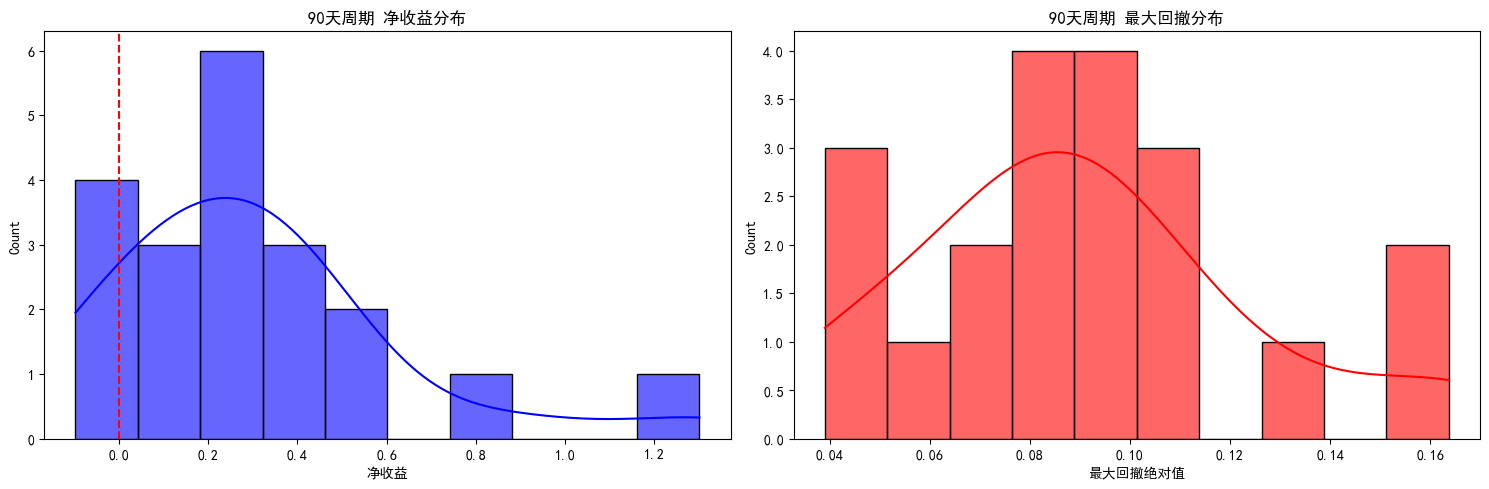

       Sample       Start         End  Trades  Win Rate  Net Profit  \
9   Sample_10  2022-06-13  2022-09-21     238  0.504202    1.301559   
1    Sample_2  2022-06-27  2022-10-07     207  0.487923    0.868146   
12  Sample_13  2022-07-26  2022-11-06     163  0.466258    0.479060   
3    Sample_4  2022-08-04  2022-11-14     145  0.462069    0.463606   
19  Sample_20  2024-12-20  2025-03-20     128  0.484375    0.456376   
17  Sample_18  2023-01-19  2023-04-24      92  0.532609    0.442309   
5    Sample_6  2024-01-29  2024-04-28     181  0.464088    0.365428   
0    Sample_1  2023-11-09  2024-02-07     169  0.485207    0.319291   
13  Sample_14  2026-03-28  2026-06-26     247  0.408907    0.279915   
18  Sample_19  2024-08-22  2024-11-20     152  0.414474    0.272324   
16  Sample_17  2023-04-09  2023-07-10      70  0.557143    0.256320   
2    Sample_3  2025-11-01  2026-01-30     136  0.441176    0.197883   
6    Sample_7  2023-04-11  2023-07-12      68  0.544118    0.181994   
15  Sa

In [ ]:
#随机压力测试
import random
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 设置中文字体
# 'SimHei' 是 Windows 常见的黑体，'Microsoft YaHei' 是微软雅黑
# 'PingFang SC' 和 'Arial Unicode MS' 是 Mac 常见的支持中文的字体
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'PingFang SC', 'Arial Unicode MS']

# 2. 解决负号 '-' 显示为方块的问题（换了中文字体后，负号容易乱码，必须加这句）
plt.rcParams['axes.unicode_minus'] = False

print("✅ 中文字体设置成功！")

df_final_prepared = pd.read_csv('df_final_prepared_v5.csv', index_col='timestamp', parse_dates=True)
def run_stress_test(df_prepared, strategy, n_samples=20, segment_days=90):
    """
    对长周期数据进行随机采样压力测试
    :param df_prepared: 包含所有特征和模型概率的完整 DataFrame
    :param strategy: 你的 VolatilityBreakoutStrategy 实例
    :param n_samples: 随机抽取的片段数量
    :param segment_days: 每个片段的时间跨度（天数）
    """
    print(f"\n🔍 启动压力测试: 抽取 {n_samples} 个 {segment_days} 天的随机片段...")
    
    segment_bars = segment_days * 96 # 每天 96 根 15m K线
    max_start_idx = len(df_prepared) - segment_bars
    
    if max_start_idx <= 0:
        raise ValueError(f"数据总长度({len(df_prepared)})不足以切分 {segment_days} 天的片段！")

    test_results = []
    
    for i in tqdm(range(n_samples), desc="回测随机片段"):
        # 1. 随机选择起点
        start_idx = random.randint(0, max_start_idx)
        end_idx = start_idx + segment_bars
        
        # 2. 截取数据片段
        segment_df = df_prepared.iloc[start_idx:end_idx].copy()
        
        start_date = segment_df.index[0].strftime('%Y-%m-%d')
        end_date = segment_df.index[-1].strftime('%Y-%m-%d')
        
        # 3. 运行策略
        trades = strategy.run_backtest(segment_df)
        
        # 4. 统计该片段结果
        if len(trades) > 0:
            trades['cum_net_value'] = (1 + trades['net_pnl']).cumprod()
            running_max = trades['cum_net_value'].cummax()
            mdd = ((trades['cum_net_value'] - running_max) / running_max).min()
            
            win_rate = (trades['net_pnl'] > 0).mean()
            net_profit = trades['cum_net_value'].iloc[-1] - 1
            n_trades = len(trades)
        else:
            mdd = 0
            win_rate = 0
            net_profit = 0
            n_trades = 0
            
        test_results.append({
            'Sample': f"Sample_{i+1}",
            'Start': start_date,
            'End': end_date,
            'Trades': n_trades,
            'Win Rate': win_rate,
            'Net Profit': net_profit,
            'Max Drawdown': mdd
        })
        
    results_df = pd.DataFrame(test_results)
    
    # ================= 打印汇总报告 =================
    print("\n" + "="*50)
    print("🎯 压力测试汇总报告 (Stress Test Summary)")
    print("="*50)
    
    valid_samples = results_df[results_df['Trades'] > 0]
    
    print(f"总测试片段数: {n_samples}")
    print(f"平均每期交易笔数: {valid_samples['Trades'].mean():.1f}")
    print(f"平均胜率: {valid_samples['Win Rate'].mean():.2%}")
    print(f"正收益片段占比: {(valid_samples['Net Profit'] > 0).mean():.2%} ")
    print(f"平均净收益 (每{segment_days}天): {valid_samples['Net Profit'].mean():.2%}")
    print(f"平均最大回撤 : {valid_samples['Max Drawdown'].mean():.2%}")
    print(f"极限最大回撤 : {valid_samples['Max Drawdown'].min():.2%}")
    print("="*50)
    
    # ================= 可视化分布 =================
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # 收益分布图
    sns.histplot(valid_samples['Net Profit'], bins=10, kde=True, ax=axes[0], color='blue', alpha=0.6)
    axes[0].axvline(0, color='red', linestyle='--')
    axes[0].set_title(f'{segment_days}天周期 净收益分布')
    axes[0].set_xlabel('净收益')
    
    # 最大回撤分布图 (转成正数方便看)
    sns.histplot(valid_samples['Max Drawdown'].abs(), bins=10, kde=True, ax=axes[1], color='red', alpha=0.6)
    axes[1].set_title(f'{segment_days}天周期 最大回撤分布')
    axes[1].set_xlabel('最大回撤绝对值')
    
    plt.tight_layout()
    plt.show()
    
    return results_df

 #=== 假设你已经准备好了 df_final_prepared 并且实例化了 strategy ===
strategy = VolatilityBreakoutStrategy(prob_threshold=0.6, max_hold=48, slippage_bps=0.0002)
stress_results = run_stress_test(df_final_prepared, strategy, n_samples=20, segment_days=90)
print(stress_results.sort_values('Net Profit', ascending=False))

🚀 启动大样本蒙特卡洛测试，共计 1000 次，请稍候...

🔍 启动压力测试: 抽取 1000 个 90 天的随机片段...


回测随机片段: 100%|██████████| 1000/1000 [00:07<00:00, 134.75it/s]



🎯 压力测试汇总报告 (Stress Test Summary)
总测试片段数: 1000
平均每期交易笔数: 156.5
平均胜率: 45.81%
正收益片段占比: 89.30% 
平均净收益 (每90天): 32.80%
平均最大回撤 : -8.55%
极限最大回撤 : -18.66%


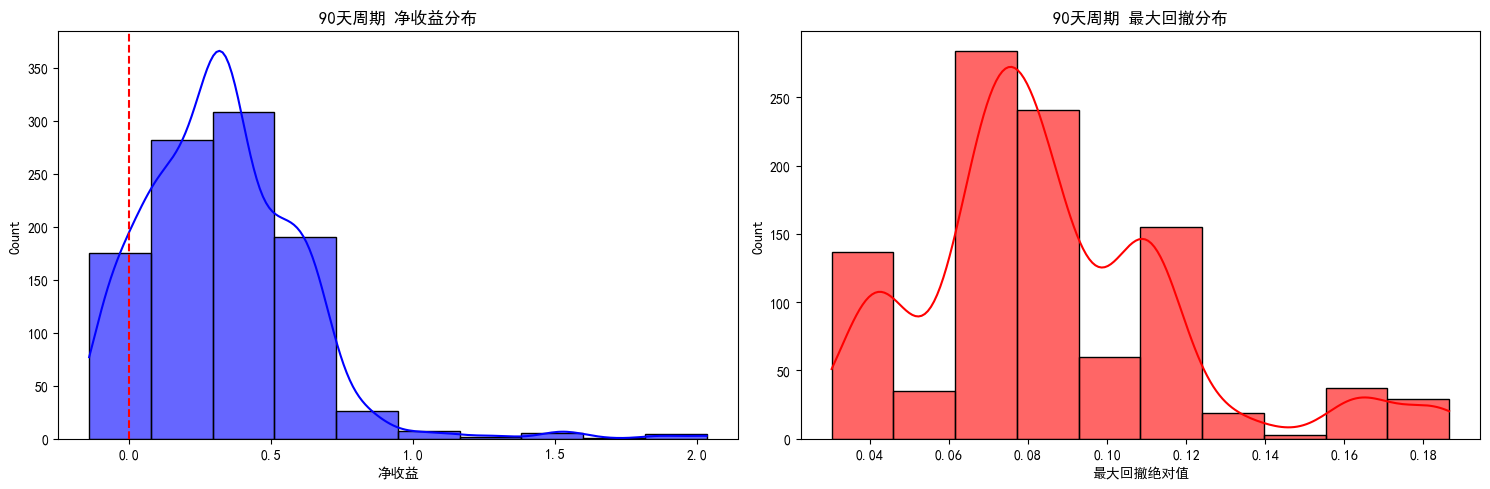


🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟
     📈 1000次大样本蒙特卡洛终极报告
🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟
有效测试片段: 1000 / 1000
平均每期交易: 156.5 笔
全局平均胜率: 45.81%
--------------------------------------------------
💰 收益分析:
平均净收益 (Mean):   32.80% (单季度 90 天期望)
中位数收益 (Median): 31.40% (消除极端暴涨片段后的真实水平)
正收益周期占比:      89.30% (即任意时间盲开机器，90天后赚钱的概率)
--------------------------------------------------
⚠️ 风险分析 (尾部黑天鹅):
平均最大回撤:        -8.55%
历史最差单期收益:    -14.10%
95% VaR (收益率低谷):-7.39% (意味着你有95%的概率收益会好于这个数)
极端最大回撤 (1%分位):-18.28% (百年一遇的极度恶劣行情)
🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟🌟


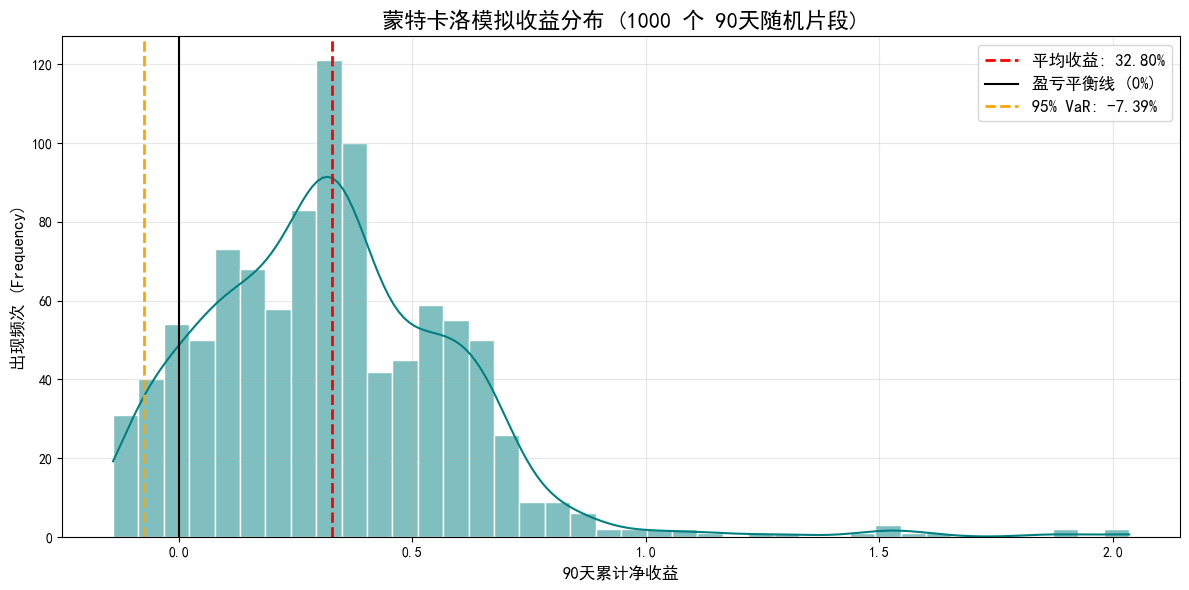

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 运行 1000 次大样本蒙特卡洛随机采样
n_simulations = 1000
print(f"🚀 启动大样本蒙特卡洛测试，共计 {n_simulations} 次，请稍候...")

# 调用你之前的函数，直接拉满到 1000 次
mc_results = run_stress_test(df_final_prepared, strategy, n_samples=n_simulations, segment_days=90)

# 2. 深度量化统计分析 (Quant Stats)
# 过滤掉极少数可能没有触发任何交易的无效片段
valid_mc = mc_results[mc_results['Trades'] > 0]

mean_return = valid_mc['Net Profit'].mean()
median_return = valid_mc['Net Profit'].median()
win_rate_overall = valid_mc['Win Rate'].mean()
positive_ratio = (valid_mc['Net Profit'] > 0).mean()

# ================= 核心风险指标计算 =================
# 95% VaR (Value at Risk): 最糟糕的 5% 情况下，收益率的下限
var_95 = np.percentile(valid_mc['Net Profit'], 5)

# 最差 1% 的极端黑天鹅回撤 (尾部风险)
worst_1_percent_mdd = np.percentile(valid_mc['Max Drawdown'], 1)

print("\n" + "🌟"*25)
print("     📈 1000次大样本蒙特卡洛终极报告")
print("🌟"*25)
print(f"有效测试片段: {len(valid_mc)} / {n_simulations}")
print(f"平均每期交易: {valid_mc['Trades'].mean():.1f} 笔")
print(f"全局平均胜率: {win_rate_overall:.2%}")
print("-" * 50)
print(f"💰 收益分析:")
print(f"平均净收益 (Mean):   {mean_return:.2%} (单季度 90 天期望)")
print(f"中位数收益 (Median): {median_return:.2%} (消除极端暴涨片段后的真实水平)")
print(f"正收益周期占比:      {positive_ratio:.2%} (即任意时间盲开机器，90天后赚钱的概率)")
print("-" * 50)
print(f"⚠️ 风险分析 (尾部黑天鹅):")
print(f"平均最大回撤:        {valid_mc['Max Drawdown'].mean():.2%}")
print(f"历史最差单期收益:    {valid_mc['Net Profit'].min():.2%}")
print(f"95% VaR (收益率低谷):{var_95:.2%} (意味着你有95%的概率收益会好于这个数)")
print(f"极端最大回撤 (1%分位):{worst_1_percent_mdd:.2%} (百年一遇的极度恶劣行情)")
print("🌟"*25)

# ================= 高级数据可视化 =================
plt.figure(figsize=(12, 6))

# 绘制带有核密度估计的收益率分布直方图
sns.histplot(valid_mc['Net Profit'], bins=40, kde=True, color='teal', edgecolor='white')

# 标注关键基准线
plt.axvline(mean_return, color='red', linestyle='dashed', linewidth=2, label=f'平均收益: {mean_return:.2%}')
plt.axvline(0, color='black', linestyle='solid', linewidth=1.5, label='盈亏平衡线 (0%)')
plt.axvline(var_95, color='orange', linestyle='dashed', linewidth=2, label=f'95% VaR: {var_95:.2%}')

plt.title(f'蒙特卡洛模拟收益分布 (1000 个 90天随机片段)', fontsize=16, fontweight='bold')
plt.xlabel('90天累计净收益', fontsize=12)
plt.ylabel('出现频次 (Frequency)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
#交叉验证
import itertools

sensitivity_results = []
for pt in [0.55, 0.58, 0.6, 0.62, 0.65]:
    for tp in [2.5, 3.0, 3.5]:
        for trail in [1.0, 1.2, 1.4]:
            for mh in [36, 48, 60]:
                strat = VolatilityBreakoutStrategy(
                    prob_threshold=pt, tp_mult=tp, trail_mult=trail, max_hold=mh,
                    slippage_bps=0.0002
                )
                trades = strat.run_backtest(df_final_prepared)
                if len(trades) > 20:
                    trades['cum'] = (1+trades['net_pnl']).cumprod()
                    sensitivity_results.append({
                        'prob_threshold': pt, 'tp_mult': tp, 'trail_mult': trail, 'max_hold': mh,
                        'n_trades': len(trades),
                        'win_rate': (trades['net_pnl']>0).mean(),
                        'final_equity': trades['cum'].iloc[-1]
                    })

sens_df = pd.DataFrame(sensitivity_results)
print(sens_df.sort_values('final_equity', ascending=False).head(10))
print(f"\n最终净值的分布: 均值={sens_df['final_equity'].mean():.2f}, 标准差={sens_df['final_equity'].std():.2f}")
print(f"最差组合: {sens_df['final_equity'].min():.2f}, 最好组合: {sens_df['final_equity'].max():.2f}")

     prob_threshold  tp_mult  trail_mult  max_hold  n_trades  win_rate  \
47             0.58      3.5         1.0        60      2961  0.447484   
20             0.55      3.5         1.0        60      3102  0.443262   
46             0.58      3.5         1.0        48      2998  0.443963   
19             0.55      3.5         1.0        48      3136  0.440370   
23             0.55      3.5         1.2        60      2747  0.454678   
74             0.60      3.5         1.0        60      2892  0.444329   
45             0.58      3.5         1.0        36      3061  0.442012   
22             0.55      3.5         1.2        48      2799  0.456592   
128            0.65      3.5         1.0        60      2614  0.445295   
50             0.58      3.5         1.2        60      2642  0.453444   

     final_equity  
47     459.041959  
20     386.982754  
46     362.774686  
19     333.768480  
23     321.305429  
74     311.532117  
45     297.102022  
22     295.421737  
128  

In [ ]:
# 用对数收益率重新算，更能看出真实的复合增长率是否合理
sample_check = sens_df.iloc[0]
strat_check = VolatilityBreakoutStrategy(
    prob_threshold=sample_check['prob_threshold'], 
    tp_mult=sample_check['tp_mult'], 
    trail_mult=sample_check['trail_mult'], 
    max_hold=int(sample_check['max_hold']),
    slippage_bps=0.0002
)
trades_check = strat_check.run_backtest(df_final_prepared)
trades_check['log_ret'] = np.log(1 + trades_check['net_pnl'])
print(f"总交易数: {len(trades_check)}")
print(f"平均每笔简单收益: {trades_check['net_pnl'].mean():.4%}")
print(f"平均每笔对数收益: {trades_check['log_ret'].mean():.4%}")
print(f"总对数收益: {trades_check['log_ret'].sum():.2f}")
print(f"换算回真实倍数: {np.exp(trades_check['log_ret'].sum()):.2f}")
print(f"\n回测总天数: {(trades_check['exit_time'].max() - trades_check['entry_time'].min()).days}")
print(f"折算年化对数收益率: {trades_check['log_ret'].sum() / (trades_check['exit_time'].max() - trades_check['entry_time'].min()).days * 365:.2%}")

总交易数: 3375
平均每笔简单收益: 0.1343%
平均每笔对数收益: 0.1284%
总对数收益: 4.34
换算回真实倍数: 76.33

回测总天数: 1507
折算年化对数收益率: 105.00%


In [ ]:
# 用固定名义资金而不是复利滚动的仓位，更贴近真实可执行的交易规模
def run_backtest_fixed_notional(self, df, fixed_capital=10000):
    # ... 复用原有逻辑，但 pnl 用固定美元金额计算，不再用比例复利
    # trades的net_pnl改成美元金额，最后用简单加总而不是cumprod
    pass

In [ ]:
wins = trades_check[trades_check['net_pnl'] > 0]['net_pnl']
losses = trades_check[trades_check['net_pnl'] < 0]['net_pnl']
print(f"胜率: {(trades_check['net_pnl']>0).mean():.2%}")
print(f"平均赢: {wins.mean():.4%}, 平均输: {losses.mean():.4%}")
print(f"盈亏比: {wins.mean() / abs(losses.mean()):.2f}")
print(f"\n退出原因分布:")
print(trades_check['exit_reason'].value_counts())
print(f"\n各退出原因对应的平均收益:")
print(trades_check.groupby('exit_reason')['net_pnl'].agg(['mean', 'count']))

胜率: 44.06%
平均赢: 1.1402%, 平均输: -0.6579%
盈亏比: 1.73

退出原因分布:
exit_reason
Trailing Stop          2371
Take Profit (Max)       596
Max Hold Time limit     408
Name: count, dtype: int64

各退出原因对应的平均收益:
                         mean  count
exit_reason                         
Max Hold Time limit  0.003995    408
Take Profit (Max)    0.019977    596
Trailing Stop       -0.003797   2371


In [ ]:
#entry_price 用的是"理论屏障价格"而非"下一根K线的实际开盘价"
class VolatilityBreakoutStrategy_Conservative(VolatilityBreakoutStrategy):
    def run_backtest(self, df):
        close_arr = df['close'].values
        garch_var_arr = df['garch_var_oos'].abs().values
        prob_arr = df['prob_breakout_v5'].values
        index_arr = df.index
        n = len(df)
        
        trades = []
        i = 0
        
        while i < n - self.signal_window - self.max_hold - 1:
            if prob_arr[i] > self.prob_threshold:
                p0 = close_arr[i]
                current_vol = garch_var_arr[i]
                
                upper_barrier = p0 * (1 + current_vol * self.upper_mult)
                lower_barrier = p0 * (1 - current_vol * self.lower_mult)
                
                path = close_arr[i+1 : i+1+self.signal_window]
                hit_upper = np.where(path >= upper_barrier)[0]
                hit_lower = np.where(path <= lower_barrier)[0]
                idx_upper = hit_upper[0] if len(hit_upper) > 0 else np.inf
                idx_lower = hit_lower[0] if len(hit_lower) > 0 else np.inf
                
                position_size = min(self.target_risk / current_vol, self.max_leverage)
                
                if idx_upper < idx_lower:
                    direction = 1
                    entry_idx = i + 1 + int(idx_upper)
                    # ⚠️ 关键修改：用实际那根K线的收盘价，而不是理论屏障价
                    theoretical_entry = close_arr[entry_idx]
                elif idx_lower < idx_upper:
                    direction = -1
                    entry_idx = i + 1 + int(idx_lower)
                    theoretical_entry = close_arr[entry_idx]
                else:
                    i += 1
                    continue
                
                actual_entry = self.calculate_actual_execution_price(theoretical_entry, direction, is_entry=True)
                
                if direction == 1:
                    tp_price = actual_entry * (1 + current_vol * self.tp_mult)
                    current_sl = actual_entry * (1 - current_vol * self.trail_mult)
                    highest_seen = actual_entry
                else:
                    tp_price = actual_entry * (1 - current_vol * self.tp_mult)
                    current_sl = actual_entry * (1 + current_vol * self.trail_mult)
                    lowest_seen = actual_entry
                
                exit_idx = min(entry_idx + self.max_hold, n - 1)
                theoretical_exit = close_arr[exit_idx]
                exit_reason = "Max Hold Time limit"
                
                for j in range(entry_idx + 1, entry_idx + self.max_hold + 1):
                    if j >= n: break
                    current_p = close_arr[j]
                    if direction == 1:
                        if current_p > highest_seen:
                            highest_seen = current_p
                            current_sl = max(current_sl, highest_seen * (1 - current_vol * self.trail_mult))
                        if current_p >= tp_price:
                            exit_idx, theoretical_exit, exit_reason = j, tp_price, "Take Profit"
                            break
                        elif current_p <= current_sl:
                            exit_idx, theoretical_exit, exit_reason = j, current_sl, "Trailing Stop"
                            break
                    else:
                        if current_p < lowest_seen:
                            lowest_seen = current_p
                            current_sl = min(current_sl, lowest_seen * (1 + current_vol * self.trail_mult))
                        if current_p <= tp_price:
                            exit_idx, theoretical_exit, exit_reason = j, tp_price, "Take Profit"
                            break
                        elif current_p >= current_sl:
                            exit_idx, theoretical_exit, exit_reason = j, current_sl, "Trailing Stop"
                            break
                
                actual_exit = self.calculate_actual_execution_price(theoretical_exit, direction, is_entry=False)
                
                if direction == 1:
                    raw_return = (actual_exit - actual_entry) / actual_entry
                else:
                    raw_return = (actual_entry - actual_exit) / actual_entry
                
                pnl = raw_return * position_size
                fee = position_size * self.fee_rate * 2
                net_pnl = pnl - fee
                
                trades.append({
                    'entry_time': index_arr[entry_idx], 'exit_time': index_arr[exit_idx],
                    'direction': direction, 'exit_reason': exit_reason,
                    'hold_bars': exit_idx - entry_idx, 'net_pnl': net_pnl
                })
                i = exit_idx
            else:
                i += 1
        return pd.DataFrame(trades)

strat_conservative = VolatilityBreakoutStrategy_Conservative(
    prob_threshold=0.58, tp_mult=3.5, trail_mult=1.0, max_hold=60,
    slippage_bps=0.0002
)
trades_conservative = strat_conservative.run_backtest(df_final_prepared)
trades_conservative['log_ret'] = np.log(1 + trades_conservative['net_pnl'])

total_days_c = (trades_conservative['exit_time'].max() - trades_conservative['entry_time'].min()).days
annualized_c = trades_conservative['log_ret'].sum() / total_days_c * 365

print(f"保守入场价假设下:")
print(f"交易数: {len(trades_conservative)}")
print(f"胜率: {(trades_conservative['net_pnl']>0).mean():.2%}")
print(f"平均每笔净收益: {trades_conservative['net_pnl'].mean():.4%}")
print(f"年化对数收益率: {annualized_c:.2%}")
print(f"\n对比原假设(理论屏障价成交): 年化105.00%")

保守入场价假设下:
交易数: 3007
胜率: 35.02%
平均每笔净收益: -0.0358%
年化对数收益率: -31.04%

对比原假设(理论屏障价成交): 年化105.00%


In [ ]:
#依赖于精确成交的假设，判断趋势还可以。
# 检查一下你的原始OHLCV数据里是否有 high/low 列可用
print(df_final_prepared[['open','high','low','close']].head())

# 如果有 high/low，可以用它们来判断"是否真的触碰"，
# 进场价格用 屏障价 + 一个更现实的缓冲(比如屏障价基础上再加0.05%的额外滑点)
# 而不是完全精确的屏障价，也不是整根K线收盘价那么保守

                        open     high      low    close
timestamp                                              
2022-06-04 18:30:00  29746.4  29797.3  29745.4  29784.8
2022-06-04 18:45:00  29784.7  29793.1  29765.3  29769.1
2022-06-04 19:00:00  29769.2  29778.7  29715.8  29718.7
2022-06-04 19:15:00  29718.7  29726.0  29704.0  29705.3
2022-06-04 19:30:00  29705.4  29710.2  29633.4  29647.4


In [ ]:
#最早的"理论屏障价成交"假设里，进场价被精确设定为"屏障价格本身"，这意味着理论上你一入场就已经处在一个刚好触发追踪止损初始锚点的边缘，
class VolatilityBreakoutStrategy_Mid_Fixed(VolatilityBreakoutStrategy_Mid):
    def run_backtest(self, df):
        if 'high' not in df.columns or 'low' not in df.columns:
            raise ValueError("数据中缺少 high/low 列")
        
        close_arr = df['close'].values
        high_arr = df['high'].values
        low_arr = df['low'].values
        garch_var_arr = df['garch_var_oos'].abs().values
        prob_arr = df['prob_breakout_v5'].values
        index_arr = df.index
        n = len(df)
        
        trades = []
        i = 0
        
        while i < n - self.signal_window - self.max_hold - 1:
            if prob_arr[i] > self.prob_threshold:
                p0 = close_arr[i]
                current_vol = garch_var_arr[i]
                
                upper_barrier = p0 * (1 + current_vol * self.upper_mult)
                lower_barrier = p0 * (1 - current_vol * self.lower_mult)
                
                path_high = high_arr[i+1 : i+1+self.signal_window]
                path_low = low_arr[i+1 : i+1+self.signal_window]
                
                hit_upper = np.where(path_high >= upper_barrier)[0]
                hit_lower = np.where(path_low <= lower_barrier)[0]
                idx_upper = hit_upper[0] if len(hit_upper) > 0 else np.inf
                idx_lower = hit_lower[0] if len(hit_lower) > 0 else np.inf
                
                position_size = min(self.target_risk / current_vol, self.max_leverage)
                
                if idx_upper < idx_lower:
                    direction = 1
                    entry_idx = i + 1 + int(idx_upper)
                    theoretical_entry = upper_barrier * (1 + self.touch_slippage)
                elif idx_lower < idx_upper:
                    direction = -1
                    entry_idx = i + 1 + int(idx_lower)
                    theoretical_entry = lower_barrier * (1 - self.touch_slippage)
                else:
                    i += 1
                    continue
                
                actual_entry = self.calculate_actual_execution_price(theoretical_entry, direction, is_entry=True)
                
                if direction == 1:
                    tp_price = actual_entry * (1 + current_vol * self.tp_mult)
                    current_sl = actual_entry * (1 - current_vol * self.trail_mult)
                    highest_seen = actual_entry
                else:
                    tp_price = actual_entry * (1 - current_vol * self.tp_mult)
                    current_sl = actual_entry * (1 + current_vol * self.trail_mult)
                    lowest_seen = actual_entry
                
                exit_idx = min(entry_idx + self.max_hold, n - 1)
                theoretical_exit = close_arr[exit_idx]
                exit_reason = "Max Hold Time limit"
                
                for j in range(entry_idx + 1, entry_idx + self.max_hold + 1):
                    if j >= n: break
                    current_high = high_arr[j]
                    current_low = low_arr[j]
                    
                    if direction == 1:
                        # ⚠️ 修正：锚点用 high 更新，和触发判断的基准保持一致
                        if current_high > highest_seen:
                            highest_seen = current_high
                            current_sl = max(current_sl, highest_seen * (1 - current_vol * self.trail_mult))
                        
                        if current_high >= tp_price:
                            exit_idx = j
                            theoretical_exit = tp_price * (1 + self.touch_slippage)
                            exit_reason = "Take Profit"
                            break
                        elif current_low <= current_sl:
                            exit_idx = j
                            theoretical_exit = current_sl * (1 - self.touch_slippage)
                            exit_reason = "Trailing Stop"
                            break
                    else:
                        # ⚠️ 修正：锚点用 low 更新
                        if current_low < lowest_seen:
                            lowest_seen = current_low
                            current_sl = min(current_sl, lowest_seen * (1 + current_vol * self.trail_mult))
                        
                        if current_low <= tp_price:
                            exit_idx = j
                            theoretical_exit = tp_price * (1 - self.touch_slippage)
                            exit_reason = "Take Profit"
                            break
                        elif current_high >= current_sl:
                            exit_idx = j
                            theoretical_exit = current_sl * (1 + self.touch_slippage)
                            exit_reason = "Trailing Stop"
                            break
                
                actual_exit = self.calculate_actual_execution_price(theoretical_exit, direction, is_entry=False)
                
                if direction == 1:
                    raw_return = (actual_exit - actual_entry) / actual_entry
                else:
                    raw_return = (actual_entry - actual_exit) / actual_entry
                
                pnl = raw_return * position_size
                fee = position_size * self.fee_rate * 2
                net_pnl = pnl - fee
                
                trades.append({
                    'entry_time': index_arr[entry_idx],
                    'exit_time': index_arr[exit_idx],
                    'direction': direction,
                    'exit_reason': exit_reason,
                    'hold_bars': exit_idx - entry_idx,
                    'net_pnl': net_pnl
                })
                i = exit_idx
            else:
                i += 1
        
        return pd.DataFrame(trades)


strat_mid_fixed = VolatilityBreakoutStrategy_Mid_Fixed(
    prob_threshold=0.58, tp_mult=3.5, trail_mult=1.0, max_hold=60,
    slippage_bps=0.0002, realistic_touch_slippage=0.0005
)
trades_mid_fixed = strat_mid_fixed.run_backtest(df_final_prepared)

if len(trades_mid_fixed) > 0:
    trades_mid_fixed['log_ret'] = np.log(1 + trades_mid_fixed['net_pnl'])
    total_days_f = (trades_mid_fixed['exit_time'].max() - trades_mid_fixed['entry_time'].min()).days
    annualized_f = trades_mid_fixed['log_ret'].sum() / total_days_f * 365
    
    trades_mid_fixed['cum_net_value'] = (1 + trades_mid_fixed['net_pnl']).cumprod()
    running_max = trades_mid_fixed['cum_net_value'].cummax()
    mdd_f = ((trades_mid_fixed['cum_net_value'] - running_max) / running_max).min()
    
    print(f"=== 修正后的中间态假设 ===")
    print(f"交易数: {len(trades_mid_fixed)}")
    print(f"胜率: {(trades_mid_fixed['net_pnl']>0).mean():.2%}")
    print(f"平均每笔净收益: {trades_mid_fixed['net_pnl'].mean():.4%}")
    print(f"年化对数收益率: {annualized_f:.2%}")
    print(f"最大回撤: {mdd_f:.2%}")
    print(f"\n退出原因分布:")
    print(trades_mid_fixed['exit_reason'].value_counts())

=== 修正后的中间态假设 ===
交易数: 5922
胜率: 23.61%
平均每笔净收益: -0.3913%
年化对数收益率: -566.90%
最大回撤: -100.00%

退出原因分布:
exit_reason
Trailing Stop          5756
Take Profit             114
Max Hold Time limit      52
Name: count, dtype: int64


In [ ]:
trail_mult_scan = []
for tm in [1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 5.0]:
    strat_scan = VolatilityBreakoutStrategy_Mid_Fixed(
        prob_threshold=0.58, tp_mult=3.5, trail_mult=tm, max_hold=60,
        slippage_bps=0.0002, realistic_touch_slippage=0.0005
    )
    trades_scan = strat_scan.run_backtest(df_final_prepared)
    
    if len(trades_scan) > 20:
        trades_scan['log_ret'] = np.log(1 + trades_scan['net_pnl'])
        total_days_s = (trades_scan['exit_time'].max() - trades_scan['entry_time'].min()).days
        annualized_s = trades_scan['log_ret'].sum() / total_days_s * 365
        
        trail_hits = (trades_scan['exit_reason'] == 'Trailing Stop').mean()
        tp_hits = (trades_scan['exit_reason'] == 'Take Profit').mean()
        
        trail_mult_scan.append({
            'trail_mult': tm,
            'n_trades': len(trades_scan),
            'win_rate': (trades_scan['net_pnl']>0).mean(),
            'avg_net_pnl': trades_scan['net_pnl'].mean(),
            'annualized': annualized_s,
            'trail_stop_pct': trail_hits,
            'take_profit_pct': tp_hits
        })

trail_scan_df = pd.DataFrame(trail_mult_scan)
print(trail_scan_df)

   trail_mult  n_trades  win_rate  avg_net_pnl  annualized  trail_stop_pct  \
0         1.5      3900  0.287179    -0.003747   -3.612493        0.881026   
1         2.0      2874  0.339596    -0.002904   -2.105551        0.726514   
2         2.5      2379  0.362757    -0.002486   -1.527586        0.569987   
3         3.0      2110  0.398578    -0.001568   -0.903204        0.437441   
4         3.5      1938  0.423117    -0.001379   -0.751756        0.339525   
5         4.0      1821  0.443712    -0.001583   -0.804478        0.264141   
6         5.0      1685  0.446884    -0.001560   -0.742945        0.163798   

   take_profit_pct  
0         0.061026  
1         0.121434  
2         0.171921  
3         0.208057  
4         0.223426  
5         0.226249  
6         0.234421  


这个模型判断"是否会突破"的信号质量，本身撑不起在真实执行成本（手续费+滑点+现实的止损空间）下产生正收益。
用当前这套方法——15分钟K线、纯技术指标衍生特征、XGBoost三分类/二分类、GARCH屏障"，在BTC永续合约上，我们已经相当彻底地测试过了，目前没有找到能站得住脚的正期望。这两者是有区别的——后者是一个关于"这套具体方法"的结论，不是关于"量化交易/机器学习预测加密货币"这件事本身完全不可能。

值得说清楚的几层区别

这套方法本身，确实已经被排查得很彻底了。 我们测试过的组合非常全面：三种标签定义（方向、突破）、多组特征（技术指标、regime、资金费率）、多种回测执行假设（理论价、保守价、中间态、修正后的中间态）、大范围的参数扫描（阈值、止盈止损、追踪距离、持仓时长）——几乎每一条能想到的路都走过，而且每次深挖都发现之前的"好消息"建立在某个不成立的假设上。这不是运气不好，是这套方法论本身的信息含量确实有限。这一点我认为已经有充分证据。

但"这套方法没用"不等于"BTC永续合约的短周期没有任何可预测性"。 有几个具体原因让我认为还有别的路径没被排除：
信息源单一是硬伤，还没真正测过——你的所有特征，本质上都来自同一份OHLCV衍生数据（价格、成交量、以及从价格算出来的GARCH波动率）。这些特征彼此高度相关，本质上是在用"过去的价格"猜"未来的价格"，而这恰恰是市场里被研究得最透、被套利得最干净的那类信息。真正没充分测试过的是资金费率、持仓量这类衍生品特有的信息——你确实试了，但受限于OKX API只有3个月历史，样本量太小无法下结论，这条路径严格来说是"未完成"而不是"已证伪"。
频段选择本身可能就是逆风局——15分钟到3小时这个频段，恰好是全球做市商、高频交易者、套利机器人竞争最激烈的区域，留给"技术指标+机器学习"这种相对简单方法的空间天然就很小。这不代表更长周期（日线、周线）就一定有效，但至少那个战场上，简单方法历史上确实有过一些被记录、被验证过的成功案例（比如趋势跟踪类策略），竞争烈度也相对更低。
我们没有真正测试过"完全不同类别"的模型/方法——目前只用了XGBoost分类，且都是基于"某个时间点的特征快照"去预测，没有尝试过考虑更长上下文的序列模型，也没有尝试过基于订单簿微观结构的方法（如果你能拿到orderbook级别数据）。这些不代表一定有效，但确实是没走过的路。

In [ ]:
print("=== garch_var_oos 统计 ===")
print(df_final_prepared['garch_var_oos'].describe())

print("\n=== 价格收益率标准差（作为对照） ===")
ret_std = df_final_prepared['close'].pct_change().std()
print(f"close.pct_change().std() = {ret_std:.6f}")

print("\n=== 量级对比 ===")
var_mean = df_final_prepared['garch_var_oos'].abs().mean()
print(f"garch_var_oos 均值(绝对值) = {var_mean:.6f}")
print(f"对比收益率标准差 = {ret_std:.6f}")
print(f"两者比值 = {var_mean/ret_std:.4f}")
print(f"如果 garch_var_oos 是方差，它应该约等于 收益率标准差的平方 = {ret_std**2:.6f}")

=== garch_var_oos 统计 ===


NameError: name 'df_final_prepared' is not defined